# CemCT：A Post-Segmentation XRµCT Data Analysis Workflow for Cementitious Materials

**University of Manchester / NXCT Contribution to X-SeeO2 Task 8.1**

| Item | Description |
|---|---|
| **Lead developer** | Dr Zixian Su |
| **Project Principal Investigator** | Prof. Philip J. Withers, University of Manchester |
| **Co-Principal Investigator and NXCT imaging lead** | Prof. Timothy L. Burnett, University of Manchester / National X-ray Computed Tomography Facility (NXCT) |
| **Contributing organisation** | Department of Materials, The University of Manchester |
| **Supporting facilities** | National X-ray Computed Tomography Facility (NXCT), Henry Moseley X-ray Imaging Facility |
| **Project context** | X-SeeO₂ |
| **Work package task** | Task 8.1 – XCT Data Analysis Workflow |
| **Deliverable type** | Post-segmentation data-analysis workflow and demonstration package |
| **Date** | 20 July 2026 |
| **Version** | 1.0.0 |

---

### Authors and affiliations

**Dr Zixian Su**<sup>1,2,3</sup>  
**Regius Professor Philip J. Withers**<sup>1,2</sup>  
**Professor Timothy L. Burnett**<sup>1,2</sup>

<sup>1</sup> Henry Royce Institute, Department of Materials, The University of Manchester, Manchester, United Kingdom  
<sup>2</sup> National X-ray Computed Tomography Facility (NXCT), The University of Manchester, Manchester, United Kingdom  
<sup>3</sup> School of Materials Science and Engineering, Central South University, Changsha, China

### Contribution statement

This workflow was developed by Dr Zixian Su with scientific supervision and
guidance from Regius Professor Philip J. Withers and Professor Timothy L.
Burnett.

It constitutes the University of Manchester and NXCT contribution to X-SeeO2
Task 8.1.This prototype has been developed as part of the X-SeeO₂ Task 8.1 activities. It represents an initial research workflow developed by the contributing team and should not be considered an official software release endorsed by all X-SeeO₂ consortium partners.
### Project acknowledgement

This work was undertaken as part of the University of Manchester and National
X-ray Computed Tomography Facility contribution to X-SeeO2 Task 8.1.

The formal funding acknowledgement, funding programme, and grant agreement
number should be added here using the wording specified by the X-SeeO2 project
coordinator.

---

# X-SeeO2 Post-Segmentation XRµCT Data Analysis Package for Cementitious Materials

## Purpose

This package provides a common post-segmentation workflow for the quantitative analysis of three-dimensional XRµCT datasets of cementitious materials.

It is designed for the analysis of cement paste, mortar, concrete, and other multi-phase construction materials. The workflow starts from reconstructed and segmented 3D image volumes; image reconstruction and segmentation are therefore outside the scope of this package.

The package integrates complementary voxel-based, image-based, random-walk, and pore-network modelling methods to characterise material phases, pore structure, connectivity, and transport-related properties.

The principal objectives are to:

- Quantify user-defined material phase fractions
- Calculate total and resolved porosity
- Characterise pore-size distributions
- Distinguish connected, non-through-connected, and isolated pore regions
- Quantify directional pore connectivity along X, Y, and Z
- Calculate directional diffusion tortuosity
- Estimate relative effective diffusivity and formation factor
- Perform random-walk-based transport analysis
- Extract pore and throat networks
- Estimate directional intrinsic permeability
- Export numerical results, processed image volumes, and figures for further analysis and reporting

The package is intended to provide a reproducible and extensible analysis workflow for studying changes in the phase assemblage and pore structure of cementitious materials, including changes associated with hydration, carbonation, and other microstructural processes.

---

## Package scope

The current package contains the following analysis modules:

### 1. Multi-phase phase-fraction analysis

Quantifies an arbitrary number of user-defined phases in a labelled 3D TIFF volume.

Example phases may include:

- Unreacted clinker
- Supplementary cementitious materials
- Reaction products
- Pores
- Fine aggregate
- Coarse aggregate
- Interfacial transition zone
- Other segmented phases

### 2. Total porosity analysis

Calculates the total resolved porosity and physical pore volume from a binary pore-space TIFF volume.

### 3. Pore-size analysis

Calculates the local pore-diameter distribution using a local-thickness method and reports:

- Pore-size distribution
- Differential porosity distribution
- Cumulative pore volume
- Porosity contributions from user-defined pore-size classes

### 4. Directional connectivity analysis

Identifies pore regions that span the sample in the X, Y, and Z directions.

Only face-connected voxels are considered connected. This corresponds to six-connectivity in three dimensions.

The module calculates directional connectivity and exports separate binary TIFF masks for the connected pore spaces.

### 5. Diffusion tortuosity analysis

Calculates directional diffusion tortuosity on the corresponding through-connected pore masks using a finite-difference diffusion solver.

The module also calculates:

- Formation factor
- Relative effective diffusivity
- Directional concentration fields

### 6. Random-walk analysis

Uses random walkers to provide an independent analysis of diffusion behaviour and directional tortuosity within the connected pore space.

### 7. Pore-network and permeability analysis

Uses pore-network extraction and steady-state Stokes-flow modelling to estimate directional intrinsic permeability.

The current implementation uses:

- PoreSpy for image-based pore-network extraction
- SNOW2 for pore and throat identification
- OpenPNM for pore-network transport simulation

---

## Input requirements

The package accepts reconstructed and segmented three-dimensional TIFF volumes.

Depending on the analysis module, the input can be either:

### Labelled multi-phase TIFF

Each voxel contains an integer label representing a segmented material phase.

Example:

| Label | Phase |
|---:|---|
| 1 | Unreacted particle |
| 2 | Reaction product |
| 3 | Pore |
| 4 | Aggregate |

The number of phases, label values, and phase names are defined by the user and are not restricted to a fixed phase system.

### Binary pore-space TIFF

Each voxel represents either pore space or solid material.

Example:

```text
0   = solid
255 = pore

In [1]:
import os

print(os.getcwd())

C:\Users\zixia\XseeO2_coding_folder


## Synthetic Demonstration Dataset

A synthetic labelled three-dimensional volume is generated before the quantitative analysis modules are applied. The purpose of this dataset is to provide a controlled and reproducible input for developing, testing, and validating the complete post-segmentation XRµCT analysis workflow.

Unlike an experimental dataset, the phase labels, phase fractions, volume dimensions, and pore-connectivity conditions of the synthetic volume are defined in advance. The expected results are therefore known, allowing the user to determine whether each analysis module is operating correctly.

The synthetic volume represents a simplified four-phase cementitious material containing:

- Unreacted particles
- Reaction products
- Pores
- An additional secondary phase

The default phase fractions are prescribed as:

```text
Unreacted particles: 12%
Reaction products:   65%
Pores:               15%
Other phase:          8%
Total:               100%

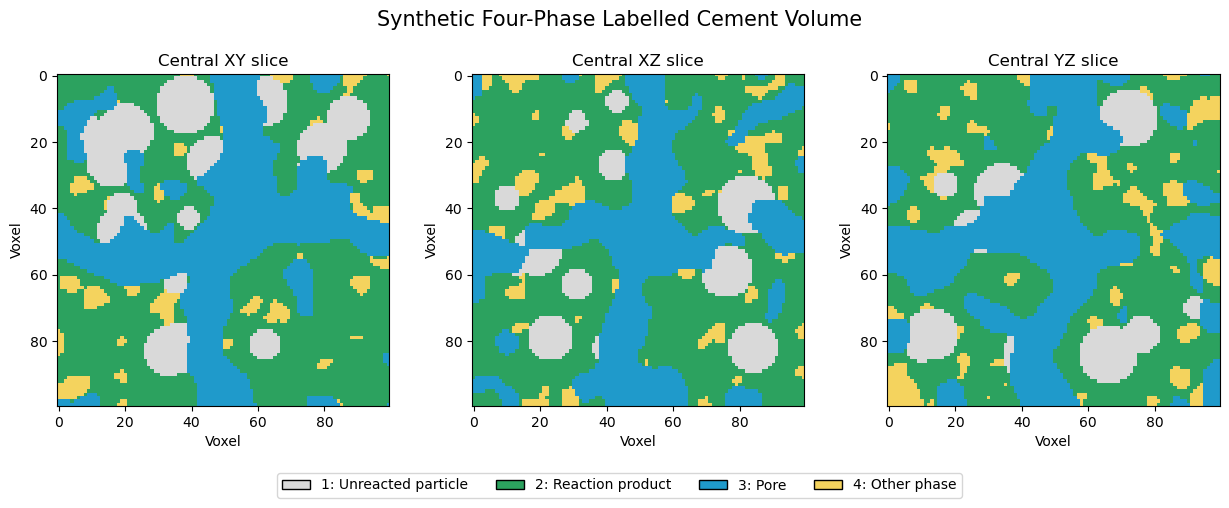


Synthetic Four-Phase Cement Volume
------------------------------------------------
Shape (Z, Y, X): (100, 100, 100)
Data type: uint8
Unique labels: [1, 2, 3, 4]
Total voxels: 1,000,000

Measured phase fractions:
  1 = Unreacted particle  :   120,000 voxels ( 12.000%)
  2 = Reaction product    :   650,000 voxels ( 65.000%)
  3 = Pore                :   150,000 voxels ( 15.000%)
  4 = Other phase         :    80,000 voxels (  8.000%)

Guaranteed pore connectivity using 6-connectivity:
  X-direction: 59.171% (1 percolating component(s))
  Y-direction: 59.171% (1 percolating component(s))
  Z-direction: 59.171% (1 percolating component(s))
  Total face-connected pore components: 110

TIFF saved to: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif
Preview saved to: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_preview.png


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from scipy import ndimage
from scipy.ndimage import gaussian_filter


# -----------------------------------------------------------------------------
# User-defined parameters
# -----------------------------------------------------------------------------

VOLUME_SHAPE = (100, 100, 100)  # Array order: Z, Y, X
RANDOM_SEED = 42

# Approximate target volume fractions. Reaction product occupies the remainder.
TARGET_UNREACTED_FRACTION = 0.12
TARGET_PORE_FRACTION = 0.15
TARGET_OTHER_FRACTION = 0.08

# Morphology controls
PORE_CORRELATION_LENGTH = 3.5
PORE_BACKBONE_RADIUS = 2
PORE_BACKBONE_INFLUENCE_LENGTH = 4.0
PORE_BACKBONE_INFLUENCE_STRENGTH = 1.5
OTHER_PHASE_CORRELATION_LENGTH = 2.0
UNREACTED_RADIUS_RANGE = (4, 9)  # Radius range in voxels

OUTPUT_TIFF = Path("synthetic_labelled_cement_4phase_100.tif")
OUTPUT_PREVIEW = Path("synthetic_labelled_cement_4phase_100_preview.png")


PHASE_NAMES = {
    1: "Unreacted particle",
    2: "Reaction product",
    3: "Pore",
    4: "Other phase",
}

PHASE_COLORS = {
    1: "#d9d9d9",
    2: "#2ca25f",
    3: "#1f9acb",
    4: "#f4d35e",
}


def validate_parameters() -> None:
    """Validate volume shape, phase fractions, and morphology parameters."""
    if tuple(VOLUME_SHAPE) != (100, 100, 100):
        raise ValueError("VOLUME_SHAPE must be exactly (100, 100, 100).")

    fractions = (
        TARGET_UNREACTED_FRACTION,
        TARGET_PORE_FRACTION,
        TARGET_OTHER_FRACTION,
    )
    if any(value < 0.0 or value >= 1.0 for value in fractions):
        raise ValueError("Each target fraction must be in the interval [0, 1).")
    if sum(fractions) >= 1.0:
        raise ValueError(
            "The unreacted, pore, and other-phase fractions must sum to less "
            "than 1. Reaction product occupies the remaining volume."
        )

    radius_min, radius_max = UNREACTED_RADIUS_RANGE
    if radius_min < 1 or radius_max < radius_min:
        raise ValueError("UNREACTED_RADIUS_RANGE is invalid.")

    if PORE_BACKBONE_RADIUS < 1:
        raise ValueError("PORE_BACKBONE_RADIUS must be at least 1 voxel.")


def add_sphere_to_mask(
    mask: np.ndarray,
    centre_zyx: tuple[int, int, int],
    radius: int,
) -> None:
    """Add a clipped solid sphere to a Boolean 3D mask in place."""
    centre_z, centre_y, centre_x = centre_zyx
    z0 = max(0, centre_z - radius)
    z1 = min(mask.shape[0], centre_z + radius + 1)
    y0 = max(0, centre_y - radius)
    y1 = min(mask.shape[1], centre_y + radius + 1)
    x0 = max(0, centre_x - radius)
    x1 = min(mask.shape[2], centre_x + radius + 1)

    zz, yy, xx = np.ogrid[z0:z1, y0:y1, x0:x1]
    local_sphere = (
        (zz - centre_z) ** 2
        + (yy - centre_y) ** 2
        + (xx - centre_x) ** 2
        <= radius**2
    )
    mask[z0:z1, y0:y1, x0:x1] |= local_sphere


def generate_through_connected_pore_backbone(
    shape: tuple[int, int, int],
    radius: int,
) -> np.ndarray:
    """
    Generate three intersecting tortuous tubes spanning X, Y, and Z.

    The tubes are constructed from overlapping spheres and share a central
    junction. Consequently, their voxels are face connected and one pore
    component touches all six opposing image faces.
    """
    backbone = np.zeros(shape, dtype=bool)
    centre_z = shape[0] // 2
    centre_y = shape[1] // 2
    centre_x = shape[2] // 2

    # X-spanning tube. Array axis 2 is the physical X direction.
    for x in range(shape[2]):
        position = x / max(shape[2] - 1, 1)
        y = centre_y + int(round(7.0 * np.sin(2.0 * np.pi * position)))
        z = centre_z + int(round(5.0 * np.sin(4.0 * np.pi * position)))
        add_sphere_to_mask(backbone, (z, y, x), radius)

    # Y-spanning tube. Array axis 1 is the physical Y direction.
    for y in range(shape[1]):
        position = y / max(shape[1] - 1, 1)
        x = centre_x + int(round(6.0 * np.sin(2.0 * np.pi * position)))
        z = centre_z + int(round(4.0 * np.sin(4.0 * np.pi * position)))
        add_sphere_to_mask(backbone, (z, y, x), radius)

    # Z-spanning tube. Array axis 0 is the physical Z direction.
    for z in range(shape[0]):
        position = z / max(shape[0] - 1, 1)
        x = centre_x + int(round(5.0 * np.sin(2.0 * np.pi * position)))
        y = centre_y + int(round(6.0 * np.sin(4.0 * np.pi * position)))
        add_sphere_to_mask(backbone, (z, y, x), radius)

    # Reinforce the shared central junction to guarantee that all tubes belong
    # to the same face-connected component after integer coordinate rounding.
    add_sphere_to_mask(
        backbone,
        (centre_z, centre_y, centre_x),
        radius + 2,
    )
    return backbone


def calculate_directional_pore_connectivity(
    pore_mask: np.ndarray,
) -> dict[str, dict[str, float | int]]:
    """Calculate X/Y/Z pore connectivity using strict 3D 6-connectivity."""
    structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
    component_labels, component_count = ndimage.label(
        pore_mask,
        structure=structure,
    )
    pore_voxel_count = int(np.count_nonzero(pore_mask))
    direction_to_axis = {"X": 2, "Y": 1, "Z": 0}
    results: dict[str, dict[str, float | int]] = {}

    for direction, axis in direction_to_axis.items():
        minimum_labels = np.unique(np.take(component_labels, 0, axis=axis))
        maximum_labels = np.unique(np.take(component_labels, -1, axis=axis))
        connected_labels = np.intersect1d(
            minimum_labels[minimum_labels != 0],
            maximum_labels[maximum_labels != 0],
        )
        connected_mask = np.isin(component_labels, connected_labels)
        connected_voxel_count = int(np.count_nonzero(connected_mask))
        results[direction] = {
            "component_count": int(connected_labels.size),
            "connected_voxel_count": connected_voxel_count,
            "connectivity_percent": 100.0
            * connected_voxel_count
            / pore_voxel_count,
        }

    results["Total"] = {
        "component_count": int(component_count),
        "connected_voxel_count": pore_voxel_count,
        "connectivity_percent": 100.0,
    }
    return results


def select_largest_available_values(
    field: np.ndarray,
    available_mask: np.ndarray,
    voxel_count: int,
) -> np.ndarray:
    """Select exactly voxel_count available voxels with the largest values."""
    selected = np.zeros(field.shape, dtype=bool)
    available_flat = np.flatnonzero(available_mask.ravel())

    if voxel_count <= 0:
        return selected
    if voxel_count > available_flat.size:
        raise ValueError("Requested phase volume exceeds the available volume.")

    available_values = field.ravel()[available_flat]
    local_indices = np.argpartition(available_values, -voxel_count)[-voxel_count:]
    selected.ravel()[available_flat[local_indices]] = True
    return selected


def generate_correlated_field(
    shape: tuple[int, int, int],
    sigma: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Generate a normalized spatially correlated Gaussian random field."""
    field = gaussian_filter(
        rng.standard_normal(shape),
        sigma=sigma,
        mode="reflect",
    )
    field -= field.min()
    peak_to_peak = np.ptp(field)
    if peak_to_peak > 0:
        field /= peak_to_peak
    return field


def generate_unreacted_particle_score(
    shape: tuple[int, int, int],
    available_mask: np.ndarray,
    target_voxel_count: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Generate a score field composed of randomly positioned spherical particles."""
    score = np.zeros(shape, dtype=np.float32)
    radius_min, radius_max = UNREACTED_RADIUS_RANGE
    maximum_attempts = 20_000
    attempts = 0

    # Add spheres until enough candidate particle voxels are available.
    while np.count_nonzero((score > 0) & available_mask) < target_voxel_count:
        attempts += 1
        if attempts > maximum_attempts:
            raise RuntimeError(
                "Unable to generate enough unreacted-particle voxels. "
                "Reduce TARGET_UNREACTED_FRACTION or particle radii."
            )

        radius = int(rng.integers(radius_min, radius_max + 1))
        center_z = int(rng.integers(radius, shape[0] - radius))
        center_y = int(rng.integers(radius, shape[1] - radius))
        center_x = int(rng.integers(radius, shape[2] - radius))

        z0, z1 = center_z - radius, center_z + radius + 1
        y0, y1 = center_y - radius, center_y + radius + 1
        x0, x1 = center_x - radius, center_x + radius + 1

        zz, yy, xx = np.ogrid[z0:z1, y0:y1, x0:x1]
        normalized_distance = np.sqrt(
            (zz - center_z) ** 2
            + (yy - center_y) ** 2
            + (xx - center_x) ** 2
        ) / radius
        sphere_score = np.clip(1.0 - normalized_distance, 0.0, 1.0)

        local_score = score[z0:z1, y0:y1, x0:x1]
        score[z0:z1, y0:y1, x0:x1] = np.maximum(
            local_score,
            sphere_score.astype(np.float32),
        )

    # A very small random term provides deterministic tie-breaking at surfaces.
    score += rng.random(shape, dtype=np.float32) * 1.0e-6
    return score


def generate_labelled_volume() -> np.ndarray:
    """Generate the complete labelled four-phase cement volume."""
    validate_parameters()
    rng = np.random.default_rng(RANDOM_SEED)
    shape = tuple(VOLUME_SHAPE)
    total_voxels = int(np.prod(shape))

    labelled_volume = np.full(shape, 2, dtype=np.uint8)
    available_mask = np.ones(shape, dtype=bool)

    # Phase 3: correlated pore network containing a guaranteed X/Y/Z-spanning
    # face-connected backbone.
    pore_count = round(TARGET_PORE_FRACTION * total_voxels)
    pore_backbone = generate_through_connected_pore_backbone(
        shape,
        PORE_BACKBONE_RADIUS,
    )
    backbone_voxel_count = int(np.count_nonzero(pore_backbone))
    if backbone_voxel_count > pore_count:
        raise ValueError(
            "The guaranteed pore backbone is larger than the target pore "
            "volume. Increase TARGET_PORE_FRACTION or reduce "
            "PORE_BACKBONE_RADIUS."
        )

    pore_field = generate_correlated_field(
        shape,
        PORE_CORRELATION_LENGTH,
        rng,
    )

    # Increase the selection score around the guaranteed backbone. This joins
    # a substantial fraction of the correlated pore regions to the percolating
    # tubes instead of creating only three isolated artificial channels.
    backbone_influence = gaussian_filter(
        pore_backbone.astype(np.float32),
        sigma=PORE_BACKBONE_INFLUENCE_LENGTH,
        mode="reflect",
    )
    if backbone_influence.max() > 0:
        backbone_influence /= backbone_influence.max()
    pore_field = (
        pore_field
        + PORE_BACKBONE_INFLUENCE_STRENGTH * backbone_influence
    )

    pore_mask = pore_backbone.copy()
    remaining_pore_count = pore_count - backbone_voxel_count
    additional_pore_mask = select_largest_available_values(
        pore_field,
        available_mask & ~pore_backbone,
        remaining_pore_count,
    )
    pore_mask |= additional_pore_mask

    if np.count_nonzero(pore_mask) != pore_count:
        raise RuntimeError("The generated pore fraction does not match its target.")

    connectivity = calculate_directional_pore_connectivity(pore_mask)
    for direction in ("X", "Y", "Z"):
        if connectivity[direction]["component_count"] < 1:
            raise RuntimeError(
                f"The generated pore network is not {direction}-through-connected."
            )

    labelled_volume[pore_mask] = 3
    available_mask[pore_mask] = False

    # Phase 1: approximately spherical unreacted particles.
    unreacted_count = round(TARGET_UNREACTED_FRACTION * total_voxels)
    unreacted_score = generate_unreacted_particle_score(
        shape,
        available_mask,
        unreacted_count,
        rng,
    )
    unreacted_mask = select_largest_available_values(
        unreacted_score,
        available_mask,
        unreacted_count,
    )
    labelled_volume[unreacted_mask] = 1
    available_mask[unreacted_mask] = False

    # Phase 4: spatially clustered secondary/other phase.
    other_count = round(TARGET_OTHER_FRACTION * total_voxels)
    other_field = generate_correlated_field(
        shape,
        OTHER_PHASE_CORRELATION_LENGTH,
        rng,
    )
    other_mask = select_largest_available_values(
        other_field,
        available_mask,
        other_count,
    )
    labelled_volume[other_mask] = 4
    available_mask[other_mask] = False

    # Phase 2 is the continuous reaction-product matrix and already occupies
    # every voxel not assigned to phases 1, 3, or 4.
    return labelled_volume


def calculate_phase_fractions(labelled_volume: np.ndarray) -> dict[int, float]:
    """Return the volume fraction of every phase."""
    return {
        label: float(np.count_nonzero(labelled_volume == label))
        / labelled_volume.size
        for label in PHASE_NAMES
    }


def save_labelled_tiff(labelled_volume: np.ndarray, output_path: Path) -> None:
    """Save the Z-Y-X volume as an 8-bit multi-page TIFF."""
    tifffile.imwrite(
        output_path,
        labelled_volume,
        dtype=np.uint8,
        photometric="minisblack",
        compression="zlib",
        metadata={
            "axes": "ZYX",
            "phase_labels": PHASE_NAMES,
        },
    )


def plot_central_slices(
    labelled_volume: np.ndarray,
    output_path: Path,
) -> None:
    """Plot and save the central XY, XZ, and YZ labelled slices."""
    z_mid = labelled_volume.shape[0] // 2
    y_mid = labelled_volume.shape[1] // 2
    x_mid = labelled_volume.shape[2] // 2

    slices = [
        (labelled_volume[z_mid, :, :], "Central XY slice"),
        (labelled_volume[:, y_mid, :], "Central XZ slice"),
        (labelled_volume[:, :, x_mid], "Central YZ slice"),
    ]

    cmap = ListedColormap([PHASE_COLORS[label] for label in PHASE_NAMES])
    norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)
    legend_handles = [
        Patch(
            facecolor=PHASE_COLORS[label],
            edgecolor="black",
            label=f"{label}: {PHASE_NAMES[label]}",
        )
        for label in PHASE_NAMES
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, (image, title) in zip(axes, slices):
        axis.imshow(image, cmap=cmap, norm=norm, interpolation="nearest")
        axis.set_title(title)
        axis.set_xlabel("Voxel")
        axis.set_ylabel("Voxel")

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.suptitle("Synthetic Four-Phase Labelled Cement Volume", fontsize=15)
    fig.subplots_adjust(bottom=0.18, top=0.86, wspace=0.25)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def print_results(
    labelled_volume: np.ndarray,
    phase_fractions: dict[int, float],
) -> None:
    """Print output information and measured phase fractions."""
    unique_labels = np.unique(labelled_volume)

    print("\nSynthetic Four-Phase Cement Volume")
    print("-" * 48)
    print(f"Shape (Z, Y, X): {labelled_volume.shape}")
    print(f"Data type: {labelled_volume.dtype}")
    print(f"Unique labels: {unique_labels.tolist()}")
    print(f"Total voxels: {labelled_volume.size:,}")
    print("\nMeasured phase fractions:")

    for label, name in PHASE_NAMES.items():
        voxel_count = int(np.count_nonzero(labelled_volume == label))
        fraction_percent = 100.0 * phase_fractions[label]
        print(
            f"  {label} = {name:<20s}: "
            f"{voxel_count:>9,} voxels ({fraction_percent:7.3f}%)"
        )

    pore_connectivity = calculate_directional_pore_connectivity(
        labelled_volume == 3
    )
    print("\nGuaranteed pore connectivity using 6-connectivity:")
    for direction in ("X", "Y", "Z"):
        direction_result = pore_connectivity[direction]
        print(
            f"  {direction}-direction: "
            f"{direction_result['connectivity_percent']:.3f}% "
            f"({direction_result['component_count']} percolating component(s))"
        )
    print(
        f"  Total face-connected pore components: "
        f"{pore_connectivity['Total']['component_count']}"
    )

    print(f"\nTIFF saved to: {OUTPUT_TIFF.resolve()}")
    print(f"Preview saved to: {OUTPUT_PREVIEW.resolve()}")


def main() -> None:
    """Generate, validate, save, and preview the labelled volume."""
    labelled_volume = generate_labelled_volume()

    if labelled_volume.dtype != np.uint8:
        raise TypeError("The generated volume is not uint8.")
    if not np.array_equal(np.unique(labelled_volume), np.array([1, 2, 3, 4])):
        raise ValueError("The generated volume does not contain labels 1, 2, 3, 4.")

    phase_fractions = calculate_phase_fractions(labelled_volume)
    save_labelled_tiff(labelled_volume, OUTPUT_TIFF)
    plot_central_slices(labelled_volume, OUTPUT_PREVIEW)
    print_results(labelled_volume, phase_fractions)


if __name__ == "__main__":
    main()

---

## 1. User-Defined Multi-Phase Fraction Analysis

This module quantifies user-defined material phases in a segmented, labelled 3D TIFF volume. It is applicable to cement paste, mortar, concrete, and other multi-phase cementitious materials.

The number of phases, label values, and phase names are defined by the user and are not restricted to a fixed segmentation convention.

Example phase definitions may include:

| Label | Phase |
|---:|---|
| 1 | Unreacted particle |
| 2 | Reaction product |
| 3 | Pore |
| 4 | Aggregate |
| 5 | Other phase |

The label values shown above are examples only. The actual label values and corresponding phase names are entered by the user during the analysis.

### Phase-fraction calculation

For a selected phase $i$, the volume fraction is calculated as:

$$
f_i = \frac{N_i}{N_{\mathrm{total}}}
$$

where:

- $N_i$ is the number of voxels assigned to phase $i$
- $N_{\mathrm{total}}$ is the total number of voxels belonging to all user-selected phases

Only user-selected labels are included in $N_{\mathrm{total}}$. Unselected labels, such as external air or image background, are excluded from the calculation.

### Physical phase volume

The physical volume of phase $i$ is calculated as:

$$
V_i = N_i \times \Delta x \times \Delta y \times \Delta z
$$

where:

- $V_i$ is the physical volume of phase $i$
- $N_i$ is the number of voxels assigned to phase $i$
- $\Delta x$ is the physical voxel dimension in the X direction
- $\Delta y$ is the physical voxel dimension in the Y direction
- $\Delta z$ is the physical voxel dimension in the Z direction

If the voxel dimensions are expressed in micrometres, the calculated phase volume is expressed in cubic micrometres:

$$
V_i \; [\mathrm{\mu m^3}]
$$

The conversion from cubic micrometres to cubic millimetres is:

$$
V_i \; [\mathrm{mm^3}]
=
V_i \; [\mathrm{\mu m^3}] \times 10^{-9}
$$
### Main outputs

- Voxel count of each user-selected phase
- Volume fraction of each phase
- Physical phase volume in µm³ and mm³
- Directional phase-fraction profiles along X, Y, and Z
- Excel workbook containing numerical results and metadata
- PNG figure containing the phase-fraction chart and central XY, XZ, and YZ slices

> **Important:** External air, mounting material, and image background must not be selected as material phases unless they are intentionally included in the analysis.


Loading the labelled TIFF volume...

Labels detected in the TIFF volume
---------------------------------------------
Label      1:      120,000 voxels ( 12.0000% of the complete image)
Label      2:      650,000 voxels ( 65.0000% of the complete image)
Label      3:      150,000 voxels ( 15.0000% of the complete image)
Label      4:       80,000 voxels (  8.0000% of the complete image)



Enter the number of phases to analyse:  4



Define every analysed phase.
Example: label = 1, phase name = Unreacted particle



Phase 1/4 - label value:  1
Phase 1/4 - phase name:  Unreacted particle

Phase 2/4 - label value:  2
Phase 2/4 - phase name:  Reaction products

Phase 3/4 - label value:  3
Phase 3/4 - phase name:  Pores

Phase 4/4 - label value:  4
Phase 4/4 - phase name:  Other phases



Selected phase definitions
---------------------------------------------
Label 1: Unreacted particle
Label 2: Reaction products
Label 3: Pores
Label 4: Other phases
Excluded/unselected labels: None
The phase-fraction denominator contains only the selected phase labels.

Enter the physical voxel dimensions in micrometres (um).


Voxel size X (um) [default: 1.0]:  0.7
Voxel size Y (um) [default: 0.7]:  0.7
Voxel size Z (um) [default: 0.7]:  0.7



Calculating global and directional phase fractions...


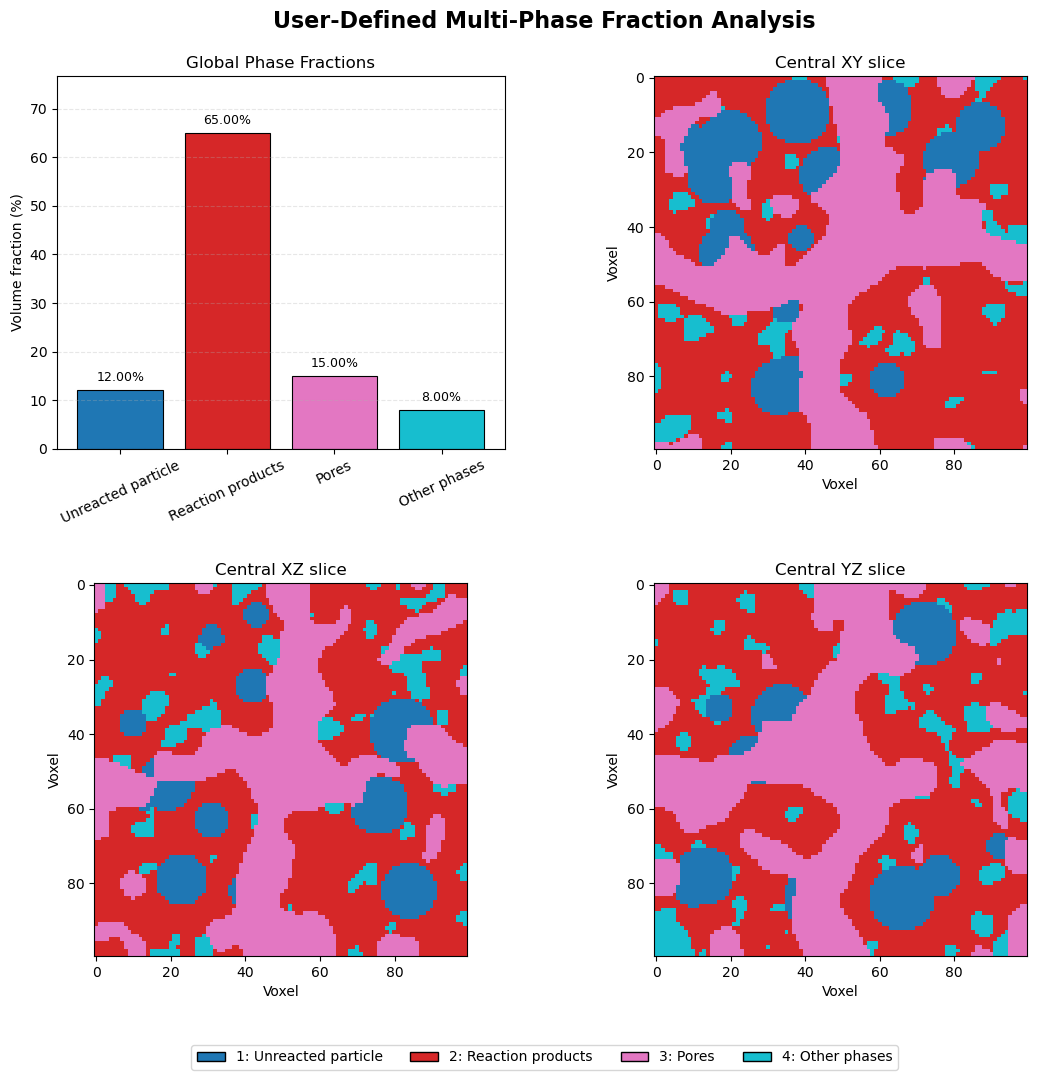


User-Defined Multi-Phase Analysis Results
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif
Volume shape (Z, Y, X): (100, 100, 100)
Input data type: uint8
--------------------------------------------------------------------
Label    1: Unreacted particle           12.000% |      41160.000 um^3
Label    2: Reaction products            65.000% |     222950.000 um^3
Label    3: Pores                        15.000% |      51450.000 um^3
Label    4: Other phases                  8.000% |      27440.000 um^3
--------------------------------------------------------------------
Sum of selected phase fractions: 100.000000%
Excel saved to: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_user_defined_phase_fraction_analysis.xlsx
Figure saved to: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_user_defined_phase_fraction_analysis.png


In [13]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from matplotlib.colors import to_hex
from matplotlib.patches import Patch


# =============================================================================
# Optional non-interactive settings
# =============================================================================

# Use None to open a file-selection window.
# Example: INPUT_TIFF = Path(r"C:\Users\your_name\labelled_mortar.tif")
INPUT_TIFF: Optional[Path] = None

# Use None to enter labels and phase names interactively after loading the TIFF.
# For automated batch analysis, define a label-to-name dictionary, for example:
# PREDEFINED_PHASES = {
#     1: "Unreacted particle",
#     2: "Reaction product",
#     3: "Pore",
#     4: "Aggregate",
# }
PREDEFINED_PHASES: Optional[dict[int, str]] = None


def select_tiff_file() -> Path:
    """Open a TIFF file-selection dialog, with a text-input fallback."""
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected = filedialog.askopenfilename(
            title="Select a labelled 3D TIFF file",
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )
        root.destroy()
        if selected:
            return Path(selected)
    except Exception:
        pass

    user_input = input("Enter the path of the labelled 3D TIFF file: ").strip()
    user_input = user_input.strip('"').strip("'")
    if not user_input:
        raise ValueError("No input TIFF file was selected.")
    return Path(user_input)


def get_positive_float(prompt: str, default: float = 1.0) -> float:
    """Request a positive floating-point number."""
    while True:
        user_input = input(f"{prompt} [default: {default}]: ").strip()
        if not user_input:
            return default
        try:
            value = float(user_input)
            if value <= 0:
                raise ValueError
            return value
        except ValueError:
            print("Please enter a positive numerical value.")


def get_positive_integer(prompt: str, maximum: int) -> int:
    """Request a positive integer not exceeding maximum."""
    while True:
        user_input = input(prompt).strip()
        try:
            value = int(user_input)
            if value < 1 or value > maximum:
                raise ValueError
            return value
        except ValueError:
            print(f"Please enter an integer from 1 to {maximum}.")


def get_voxel_size() -> tuple[float, float, float]:
    """Request the X, Y, and Z voxel dimensions in micrometres."""
    print("\nEnter the physical voxel dimensions in micrometres (um).")
    voxel_size_x_um = get_positive_float("Voxel size X (um)", 1.0)
    voxel_size_y_um = get_positive_float("Voxel size Y (um)", voxel_size_x_um)
    voxel_size_z_um = get_positive_float("Voxel size Z (um)", voxel_size_x_um)
    return voxel_size_x_um, voxel_size_y_um, voxel_size_z_um


def load_labelled_volume(file_path: Path) -> np.ndarray:
    """Load and validate a labelled 3D TIFF volume."""
    if not file_path.exists():
        raise FileNotFoundError(f"TIFF file not found: {file_path}")
    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError("The input file must have a .tif or .tiff extension.")

    volume = np.squeeze(np.asarray(tifffile.imread(file_path)))
    if volume.ndim != 3:
        raise ValueError(
            f"A 3D TIFF volume is required, but the loaded shape is {volume.shape}."
        )

    if not np.issubdtype(volume.dtype, np.integer):
        if np.all(np.isfinite(volume)) and np.all(volume == np.round(volume)):
            volume = np.round(volume).astype(np.int32)
        else:
            raise TypeError("The labelled TIFF must contain integer label values.")

    return volume


def display_observed_labels(volume: np.ndarray) -> np.ndarray:
    """Print all label values and their voxel counts."""
    labels, counts = np.unique(volume, return_counts=True)
    print("\nLabels detected in the TIFF volume")
    print("-" * 45)
    for label, count in zip(labels, counts):
        image_fraction = 100.0 * count / volume.size
        print(
            f"Label {int(label):>6}: {int(count):>12,} voxels "
            f"({image_fraction:8.4f}% of the complete image)"
        )
    return labels


def validate_predefined_phases(
    predefined_phases: dict[int, str],
    observed_labels: np.ndarray,
) -> dict[int, str]:
    """Validate phase definitions supplied in the settings section."""
    if not predefined_phases:
        raise ValueError("PREDEFINED_PHASES cannot be an empty dictionary.")

    observed_set = {int(label) for label in observed_labels}
    definitions: dict[int, str] = {}
    for raw_label, raw_name in predefined_phases.items():
        if not isinstance(raw_label, (int, np.integer)):
            raise TypeError("Every predefined label must be an integer.")
        label = int(raw_label)
        name = str(raw_name).strip()
        if not name:
            raise ValueError(f"The phase name for label {label} is empty.")
        if label not in observed_set:
            raise ValueError(
                f"Predefined label {label} is not present in the TIFF volume."
            )
        definitions[label] = name
    return definitions


def get_user_phase_definitions(
    observed_labels: np.ndarray,
) -> dict[int, str]:
    """Request an arbitrary number of label values and phase names."""
    observed_set = {int(label) for label in observed_labels}
    number_of_phases = get_positive_integer(
        "\nEnter the number of phases to analyse: ",
        maximum=len(observed_set),
    )

    definitions: dict[int, str] = {}
    print("\nDefine every analysed phase.")
    print("Example: label = 1, phase name = Unreacted particle")

    for phase_number in range(1, number_of_phases + 1):
        while True:
            label_input = input(
                f"\nPhase {phase_number}/{number_of_phases} - label value: "
            ).strip()
            try:
                label = int(label_input)
            except ValueError:
                print("The label value must be an integer.")
                continue

            if label not in observed_set:
                print(
                    f"Label {label} was not detected. Available labels: "
                    f"{sorted(observed_set)}"
                )
                continue
            if label in definitions:
                print(f"Label {label} has already been defined.")
                continue
            break

        while True:
            phase_name = input(
                f"Phase {phase_number}/{number_of_phases} - phase name: "
            ).strip()
            if phase_name:
                break
            print("The phase name cannot be empty.")

        definitions[label] = phase_name

    return definitions


def assign_phase_colors(
    phase_definitions: dict[int, str],
) -> dict[int, dict[str, str]]:
    """Assign a distinct plotting colour to every user-defined phase."""
    number_of_phases = len(phase_definitions)
    if number_of_phases <= 10:
        colormap = plt.get_cmap("tab10", number_of_phases)
    elif number_of_phases <= 20:
        colormap = plt.get_cmap("tab20", number_of_phases)
    else:
        colormap = plt.get_cmap("gist_ncar", number_of_phases)

    return {
        label: {
            "name": name,
            "color": to_hex(colormap(index), keep_alpha=False),
        }
        for index, (label, name) in enumerate(phase_definitions.items())
    }


def create_specimen_mask(
    volume: np.ndarray,
    phase_definitions: dict[int, dict[str, str]],
) -> np.ndarray:
    """Create a mask containing only the user-selected phase labels."""
    specimen_mask = np.isin(volume, list(phase_definitions))
    if not np.any(specimen_mask):
        raise ValueError("No voxels matching the selected phase labels were found.")
    return specimen_mask


def calculate_phase_summary(
    volume: np.ndarray,
    specimen_mask: np.ndarray,
    phase_definitions: dict[int, dict[str, str]],
    voxel_size_xyz_um: tuple[float, float, float],
) -> pd.DataFrame:
    """Calculate global counts, fractions, and physical volumes."""
    voxel_volume_um3 = float(np.prod(voxel_size_xyz_um))
    specimen_voxels = int(np.count_nonzero(specimen_mask))
    rows = []

    for label, phase in phase_definitions.items():
        voxel_count = int(np.count_nonzero(volume == label))
        volume_fraction = voxel_count / specimen_voxels
        physical_volume_um3 = voxel_count * voxel_volume_um3
        rows.append(
            {
                "Label": label,
                "Phase": phase["name"],
                "Voxel count": voxel_count,
                "Volume fraction (-)": volume_fraction,
                "Volume fraction (%)": 100.0 * volume_fraction,
                "Physical volume (um^3)": physical_volume_um3,
                "Physical volume (mm^3)": physical_volume_um3 / 1.0e9,
            }
        )
    return pd.DataFrame(rows)


def calculate_directional_profiles(
    volume: np.ndarray,
    specimen_mask: np.ndarray,
    phase_definitions: dict[int, dict[str, str]],
    voxel_size_xyz_um: tuple[float, float, float],
) -> pd.DataFrame:
    """Calculate phase fractions in every slice along X, Y, and Z."""
    voxel_size_x_um, voxel_size_y_um, voxel_size_z_um = voxel_size_xyz_um
    directions = {
        "X": (2, voxel_size_x_um),
        "Y": (1, voxel_size_y_um),
        "Z": (0, voxel_size_z_um),
    }
    rows = []

    for direction, (axis, spacing_um) in directions.items():
        for slice_index in range(volume.shape[axis]):
            slice_volume = np.take(volume, slice_index, axis=axis)
            slice_specimen = np.take(specimen_mask, slice_index, axis=axis)
            denominator = int(np.count_nonzero(slice_specimen))
            row = {
                "Direction": direction,
                "Slice index": slice_index,
                "Position (um)": (slice_index + 0.5) * spacing_um,
                "Analysed voxels": denominator,
            }

            for label, phase in phase_definitions.items():
                if denominator:
                    fraction_percent = (
                        100.0
                        * np.count_nonzero((slice_volume == label) & slice_specimen)
                        / denominator
                    )
                else:
                    fraction_percent = np.nan
                row[f"{phase['name']} [label {label}] (%)"] = fraction_percent
            rows.append(row)

    return pd.DataFrame(rows)


def create_metadata_table(
    file_path: Path,
    volume: np.ndarray,
    observed_labels: np.ndarray,
    specimen_mask: np.ndarray,
    phase_definitions: dict[int, dict[str, str]],
    voxel_size_xyz_um: tuple[float, float, float],
) -> pd.DataFrame:
    """Create an input and analysis metadata table."""
    selected_labels = list(phase_definitions)
    unselected_labels = sorted(
        set(map(int, observed_labels.tolist())) - set(selected_labels)
    )
    voxel_size_x_um, voxel_size_y_um, voxel_size_z_um = voxel_size_xyz_um
    records = [
        ("Input file", str(file_path.resolve())),
        ("Array order", "Z, Y, X"),
        ("Shape Z", volume.shape[0]),
        ("Shape Y", volume.shape[1]),
        ("Shape X", volume.shape[2]),
        ("Input data type", str(volume.dtype)),
        ("Observed labels", ", ".join(map(str, observed_labels.tolist()))),
        ("Selected phase labels", ", ".join(map(str, selected_labels))),
        ("Excluded/unselected labels", ", ".join(map(str, unselected_labels)) or "None"),
        ("Complete image voxels", volume.size),
        ("Analysed specimen voxels", int(np.count_nonzero(specimen_mask))),
        ("Excluded voxels", int(volume.size - np.count_nonzero(specimen_mask))),
        ("Voxel size X (um)", voxel_size_x_um),
        ("Voxel size Y (um)", voxel_size_y_um),
        ("Voxel size Z (um)", voxel_size_z_um),
        ("Voxel volume (um^3)", float(np.prod(voxel_size_xyz_um))),
    ]
    for label, phase in phase_definitions.items():
        records.append((f"Phase name for label {label}", phase["name"]))
    return pd.DataFrame(records, columns=["Parameter", "Value"])


def export_results_to_excel(
    phase_summary: pd.DataFrame,
    directional_profiles: pd.DataFrame,
    metadata: pd.DataFrame,
    output_path: Path,
) -> None:
    """Export the results to a formatted Excel workbook."""
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        phase_summary.to_excel(writer, sheet_name="Phase Fractions", index=False)
        directional_profiles.to_excel(
            writer, sheet_name="Directional Profiles", index=False
        )
        metadata.to_excel(writer, sheet_name="Metadata", index=False)

        for worksheet in writer.sheets.values():
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                maximum_length = max(
                    len(str(cell.value)) if cell.value is not None else 0
                    for cell in column_cells
                )
                worksheet.column_dimensions[column_cells[0].column_letter].width = min(
                    maximum_length + 2, 60
                )


def convert_slice_to_rgb(
    image: np.ndarray,
    phase_definitions: dict[int, dict[str, str]],
) -> np.ndarray:
    """Convert an arbitrary labelled slice to an RGB image."""
    rgb_image = np.full(image.shape + (3,), 0.12, dtype=float)
    for label, phase in phase_definitions.items():
        colour = phase["color"].lstrip("#")
        rgb = np.array(
            [int(colour[index : index + 2], 16) for index in (0, 2, 4)],
            dtype=float,
        ) / 255.0
        rgb_image[image == label] = rgb
    return rgb_image


def create_results_figure(
    volume: np.ndarray,
    phase_summary: pd.DataFrame,
    phase_definitions: dict[int, dict[str, str]],
    output_path: Path,
) -> None:
    """Create a phase-fraction bar chart and three labelled central slices."""
    labels = list(phase_definitions)
    colours = [phase_definitions[label]["color"] for label in labels]
    fractions = phase_summary["Volume fraction (%)"].to_numpy()
    phase_names = phase_summary["Phase"].tolist()

    z_mid, y_mid, x_mid = (dimension // 2 for dimension in volume.shape)
    central_slices = [
        (volume[z_mid, :, :], "Central XY slice"),
        (volume[:, y_mid, :], "Central XZ slice"),
        (volume[:, :, x_mid], "Central YZ slice"),
    ]

    figure_width = max(13.0, 0.6 * len(labels) + 10.0)
    fig, axes = plt.subplots(2, 2, figsize=(figure_width, 11))
    bar_axis = axes[0, 0]
    bars = bar_axis.bar(
        phase_names,
        fractions,
        color=colours,
        edgecolor="black",
        linewidth=0.8,
    )
    bar_axis.set_title("Global Phase Fractions")
    bar_axis.set_ylabel("Volume fraction (%)")
    bar_axis.set_ylim(0, max(5.0, float(fractions.max()) * 1.18))
    bar_axis.grid(axis="y", alpha=0.3, linestyle="--")
    bar_axis.tick_params(axis="x", rotation=25)

    label_offset = max(0.3, float(fractions.max()) * 0.02)
    for bar, value in zip(bars, fractions):
        bar_axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + label_offset,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    for axis, (image, title) in zip(axes.flat[1:], central_slices):
        axis.imshow(
            convert_slice_to_rgb(image, phase_definitions),
            interpolation="nearest",
        )
        axis.set_title(title)
        axis.set_xlabel("Voxel")
        axis.set_ylabel("Voxel")

    legend_handles = [
        Patch(
            facecolor=phase_definitions[label]["color"],
            edgecolor="black",
            label=f"{label}: {phase_definitions[label]['name']}",
        )
        for label in labels
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(5, len(labels)),
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )
    fig.suptitle("User-Defined Multi-Phase Fraction Analysis", fontsize=16, weight="bold")
    fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.36, wspace=0.25)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def print_selected_phases(
    phase_definitions: dict[int, dict[str, str]],
    observed_labels: np.ndarray,
) -> None:
    """Print selected and excluded labels before calculation."""
    selected_labels = set(phase_definitions)
    excluded_labels = sorted(set(map(int, observed_labels)) - selected_labels)
    print("\nSelected phase definitions")
    print("-" * 45)
    for label, phase in phase_definitions.items():
        print(f"Label {label}: {phase['name']}")
    print(f"Excluded/unselected labels: {excluded_labels or 'None'}")
    print(
        "The phase-fraction denominator contains only the selected phase labels."
    )


def print_results(
    file_path: Path,
    volume: np.ndarray,
    phase_summary: pd.DataFrame,
    excel_output_path: Path,
    figure_output_path: Path,
) -> None:
    """Print a compact results summary."""
    print("\nUser-Defined Multi-Phase Analysis Results")
    print("=" * 68)
    print(f"Input file: {file_path.resolve()}")
    print(f"Volume shape (Z, Y, X): {volume.shape}")
    print(f"Input data type: {volume.dtype}")
    print("-" * 68)

    for _, row in phase_summary.iterrows():
        print(
            f"Label {int(row['Label']):>4}: {row['Phase']:<25s} "
            f"{row['Volume fraction (%)']:9.3f}% | "
            f"{row['Physical volume (um^3)']:14.3f} um^3"
        )

    print("-" * 68)
    print(
        "Sum of selected phase fractions: "
        f"{phase_summary['Volume fraction (%)'].sum():.6f}%"
    )
    print(f"Excel saved to: {excel_output_path.resolve()}")
    print(f"Figure saved to: {figure_output_path.resolve()}")


def main() -> None:
    """Run the complete user-defined multi-phase analysis workflow."""
    file_path = Path(INPUT_TIFF) if INPUT_TIFF is not None else select_tiff_file()

    print("\nLoading the labelled TIFF volume...")
    volume = load_labelled_volume(file_path)
    observed_labels = display_observed_labels(volume)

    if PREDEFINED_PHASES is None:
        raw_phase_definitions = get_user_phase_definitions(observed_labels)
    else:
        raw_phase_definitions = validate_predefined_phases(
            PREDEFINED_PHASES, observed_labels
        )

    phase_definitions = assign_phase_colors(raw_phase_definitions)
    print_selected_phases(phase_definitions, observed_labels)
    voxel_size_xyz_um = get_voxel_size()
    specimen_mask = create_specimen_mask(volume, phase_definitions)

    print("\nCalculating global and directional phase fractions...")
    phase_summary = calculate_phase_summary(
        volume,
        specimen_mask,
        phase_definitions,
        voxel_size_xyz_um,
    )
    directional_profiles = calculate_directional_profiles(
        volume,
        specimen_mask,
        phase_definitions,
        voxel_size_xyz_um,
    )
    metadata = create_metadata_table(
        file_path,
        volume,
        observed_labels,
        specimen_mask,
        phase_definitions,
        voxel_size_xyz_um,
    )

    output_stem = file_path.with_suffix("")
    excel_output_path = output_stem.parent / (
        output_stem.name + "_user_defined_phase_fraction_analysis.xlsx"
    )
    figure_output_path = output_stem.parent / (
        output_stem.name + "_user_defined_phase_fraction_analysis.png"
    )

    export_results_to_excel(
        phase_summary,
        directional_profiles,
        metadata,
        excel_output_path,
    )
    create_results_figure(
        volume,
        phase_summary,
        phase_definitions,
        figure_output_path,
    )
    print_results(
        file_path,
        volume,
        phase_summary,
        excel_output_path,
        figure_output_path,
    )


if __name__ == "__main__":
    main()

---

## 2. Isolated and Boundary-Accessible Pore Analysis

Following the quantification of material phase fractions, this module examines the accessibility and directional connectivity of the segmented pore space.

Pore voxels are grouped into connected components using **6-connectivity**, meaning that only voxels sharing a face are considered connected. Edge and corner connections are excluded.

Each pore component is classified as:

- **Boundary-accessible pore:** touches at least one face of the analysed image volume
- **Closed/isolated pore:** touches none of the six image-volume faces
- **X-through-connected pore:** touches both X-min and X-max faces
- **Y-through-connected pore:** touches both Y-min and Y-max faces
- **Z-through-connected pore:** touches both Z-min and Z-max faces

The total pore space is divided into three mutually exclusive classes:

1. Any-direction through-connected pore
2. Boundary-accessible but non-through pore
3. Closed/isolated pore

These three classes sum to the total resolved pore volume.

### Main outputs

- Directional pore connectivity in X, Y, and Z
- Boundary-accessible pore fraction
- Closed/isolated pore fraction
- Through-connected pore fraction
- Individual binary TIFF masks for each pore class
- Component-level statistics
- Excel workbook and summary figure

> **Important:** Boundary accessibility is defined relative to the six faces of the analysed image volume. External air must be removed using an appropriate specimen region of interest before running this analysis.


Loading the segmented TIFF volume...

Labels detected in the TIFF volume
------------------------------------------------------
Label        1:        120,000 voxels (  12.0000% of image)
Label        2:        650,000 voxels (  65.0000% of image)
Label        3:        150,000 voxels (  15.0000% of image)
Label        4:         80,000 voxels (   8.0000% of image)



Enter the label value representing pores:  3



Enter the physical voxel dimensions in micrometres (um).


Voxel size X (um) [default: 1.0]:  0.7
Voxel size Y (um) [default: 0.7]:  0.7
Voxel size Z (um) [default: 0.7]:  0.7



Labelling face-connected pore components...
Detected 110 pore components.


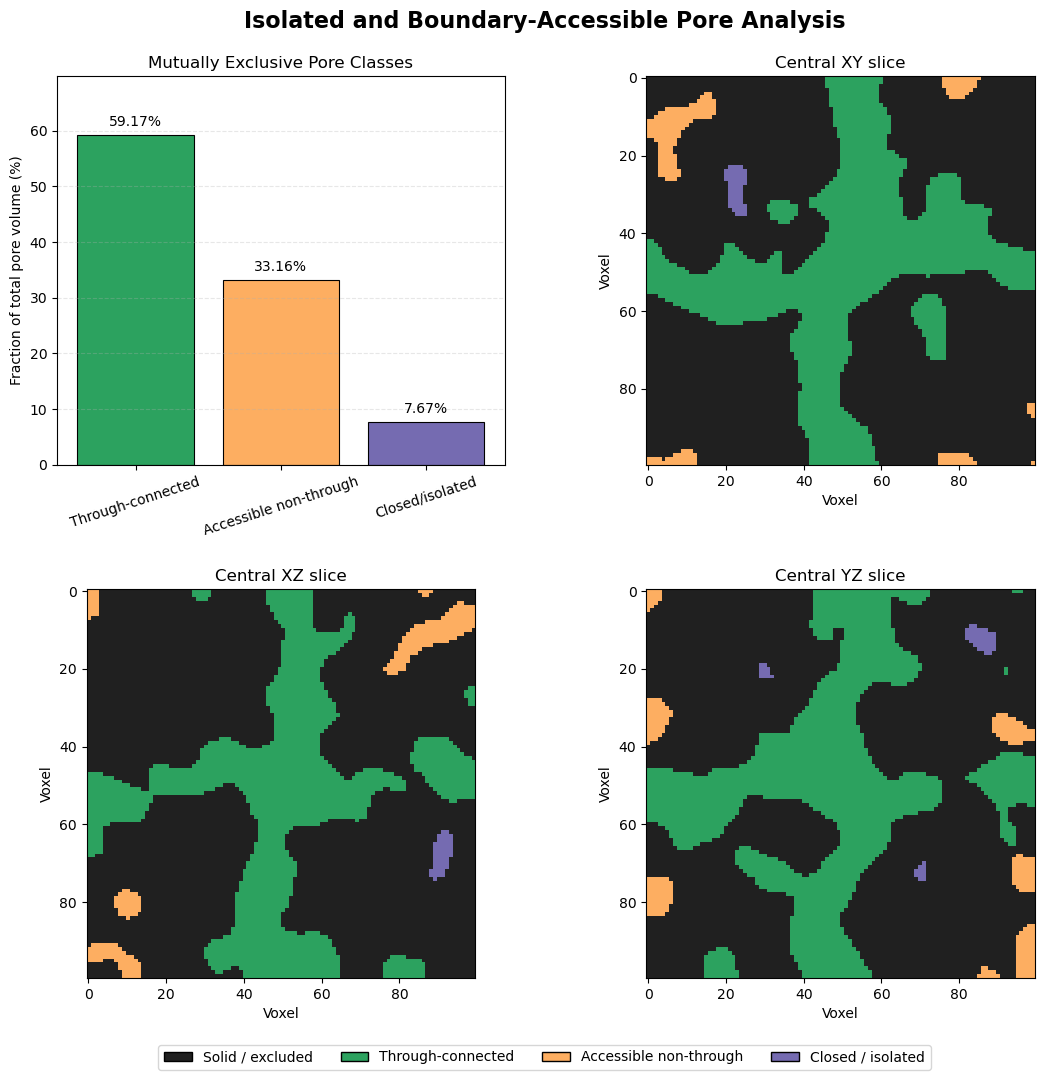


Isolated and Boundary-Accessible Pore Analysis Results
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif
Selected pore label: 3
Connectivity: 6-connectivity (face-connected voxels only)
Number of pore components: 110
----------------------------------------------------------------------------
Total pore                                 :  100.0000% of total pore
Boundary-accessible pore                   :   92.3320% of total pore
Closed/isolated pore                       :    7.6680% of total pore
X-through-connected pore                   :   59.1713% of total pore
Y-through-connected pore                   :   59.1713% of total pore
Z-through-connected pore                   :   59.1713% of total pore
Any-direction through-connected pore       :   59.1713% of total pore
Boundary-accessible non-through pore       :   33.1607% of total pore
----------------------------------------------------------------------------
Sum of mutually exclusive por

In [14]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from scipy import ndimage


# =============================================================================
# Optional non-interactive settings
# =============================================================================

# Use None to select the input TIFF interactively.
# Example: INPUT_TIFF = Path(r"C:\Users\your_name\segmented_volume.tif")
INPUT_TIFF: Optional[Path] = None

# Use None to enter the pore label interactively.
# Examples: 255 for a 0/255 binary image, 1 for a 0/1 image, or 3 for a
# multi-phase labelled image in which label 3 represents pores.
PREDEFINED_PORE_LABEL: Optional[int] = None

# Set to True to save every labelled pore component as an integer TIFF.
# This can create a large file, so it is disabled by default.
SAVE_COMPONENT_LABEL_TIFF = False


def select_tiff_file() -> Path:
    """Open a TIFF file-selection dialog, with a text-input fallback."""
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected = filedialog.askopenfilename(
            title="Select a segmented 3D TIFF file",
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )
        root.destroy()
        if selected:
            return Path(selected)
    except Exception:
        pass

    user_input = input("Enter the path of the segmented 3D TIFF file: ").strip()
    user_input = user_input.strip('"').strip("'")
    if not user_input:
        raise ValueError("No input TIFF file was selected.")
    return Path(user_input)


def get_positive_float(prompt: str, default: float = 1.0) -> float:
    """Request a positive floating-point value."""
    while True:
        user_input = input(f"{prompt} [default: {default}]: ").strip()
        if not user_input:
            return default
        try:
            value = float(user_input)
            if value <= 0:
                raise ValueError
            return value
        except ValueError:
            print("Please enter a positive numerical value.")


def get_voxel_size() -> tuple[float, float, float]:
    """Request X, Y, and Z voxel dimensions in micrometres."""
    print("\nEnter the physical voxel dimensions in micrometres (um).")
    voxel_size_x_um = get_positive_float("Voxel size X (um)", 1.0)
    voxel_size_y_um = get_positive_float("Voxel size Y (um)", voxel_size_x_um)
    voxel_size_z_um = get_positive_float("Voxel size Z (um)", voxel_size_x_um)
    return voxel_size_x_um, voxel_size_y_um, voxel_size_z_um


def load_segmented_volume(file_path: Path) -> np.ndarray:
    """Load and validate a segmented 3D TIFF volume."""
    if not file_path.exists():
        raise FileNotFoundError(f"TIFF file not found: {file_path}")
    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError("The input file must have a .tif or .tiff extension.")

    volume = np.squeeze(np.asarray(tifffile.imread(file_path)))
    if volume.ndim != 3:
        raise ValueError(
            f"A 3D TIFF volume is required, but the loaded shape is {volume.shape}."
        )
    if not np.issubdtype(volume.dtype, np.integer):
        if np.all(np.isfinite(volume)) and np.all(volume == np.round(volume)):
            volume = np.round(volume).astype(np.int32)
        else:
            raise TypeError("The segmented TIFF must contain integer labels.")
    return volume


def display_observed_labels(volume: np.ndarray) -> np.ndarray:
    """Print observed label values and voxel counts."""
    labels, counts = np.unique(volume, return_counts=True)
    print("\nLabels detected in the TIFF volume")
    print("-" * 54)
    for label, count in zip(labels, counts):
        fraction = 100.0 * count / volume.size
        print(
            f"Label {int(label):>8}: {int(count):>14,} voxels "
            f"({fraction:9.4f}% of image)"
        )
    return labels


def get_pore_label(observed_labels: np.ndarray) -> int:
    """Request and validate the integer label representing pore space."""
    observed_set = {int(label) for label in observed_labels}

    if PREDEFINED_PORE_LABEL is not None:
        pore_label = int(PREDEFINED_PORE_LABEL)
        if pore_label not in observed_set:
            raise ValueError(
                f"PREDEFINED_PORE_LABEL {pore_label} is absent from the TIFF."
            )
        return pore_label

    while True:
        user_input = input("\nEnter the label value representing pores: ").strip()
        try:
            pore_label = int(user_input)
        except ValueError:
            print("The pore label must be an integer.")
            continue

        if pore_label not in observed_set:
            print(
                f"Label {pore_label} was not detected. Available labels: "
                f"{sorted(observed_set)}"
            )
            continue
        return pore_label


def get_touching_component_labels(
    component_labels: np.ndarray,
) -> dict[str, np.ndarray]:
    """Return the component labels touching each of the six volume faces."""
    face_labels = {
        "Z_min": np.unique(component_labels[0, :, :]),
        "Z_max": np.unique(component_labels[-1, :, :]),
        "Y_min": np.unique(component_labels[:, 0, :]),
        "Y_max": np.unique(component_labels[:, -1, :]),
        "X_min": np.unique(component_labels[:, :, 0]),
        "X_max": np.unique(component_labels[:, :, -1]),
    }
    return {
        face: labels[labels != 0].astype(np.int64, copy=False)
        for face, labels in face_labels.items()
    }


def create_component_flags(
    number_of_components: int,
    touching_labels: dict[str, np.ndarray],
) -> dict[str, np.ndarray]:
    """Create Boolean face-touch and connectivity flags for every component."""
    flags: dict[str, np.ndarray] = {}
    for face, labels in touching_labels.items():
        face_flag = np.zeros(number_of_components + 1, dtype=bool)
        face_flag[labels] = True
        flags[face] = face_flag

    flags["Accessible"] = (
        flags["X_min"]
        | flags["X_max"]
        | flags["Y_min"]
        | flags["Y_max"]
        | flags["Z_min"]
        | flags["Z_max"]
    )
    flags["Closed_isolated"] = ~flags["Accessible"]
    flags["Closed_isolated"][0] = False
    flags["Through_X"] = flags["X_min"] & flags["X_max"]
    flags["Through_Y"] = flags["Y_min"] & flags["Y_max"]
    flags["Through_Z"] = flags["Z_min"] & flags["Z_max"]
    flags["Through_any"] = (
        flags["Through_X"] | flags["Through_Y"] | flags["Through_Z"]
    )
    flags["Accessible_non_through"] = flags["Accessible"] & ~flags["Through_any"]
    return flags


def create_pore_masks(
    component_labels: np.ndarray,
    flags: dict[str, np.ndarray],
) -> dict[str, np.ndarray]:
    """Create voxel masks from component-level connectivity flags."""
    pore_mask = component_labels > 0
    masks = {
        "Total_pore": pore_mask,
        "Boundary_accessible": flags["Accessible"][component_labels],
        "Closed_isolated": flags["Closed_isolated"][component_labels],
        "Through_X": flags["Through_X"][component_labels],
        "Through_Y": flags["Through_Y"][component_labels],
        "Through_Z": flags["Through_Z"][component_labels],
        "Through_any": flags["Through_any"][component_labels],
        "Accessible_non_through": flags["Accessible_non_through"][component_labels],
    }
    masks["Non_through"] = pore_mask & ~masks["Through_any"]

    mutually_exclusive_sum = (
        masks["Through_any"].astype(np.uint8)
        + masks["Accessible_non_through"].astype(np.uint8)
        + masks["Closed_isolated"].astype(np.uint8)
    )
    if not np.array_equal(mutually_exclusive_sum, pore_mask.astype(np.uint8)):
        raise RuntimeError("The mutually exclusive pore classification failed.")
    return masks


def calculate_component_statistics(
    component_labels: np.ndarray,
    number_of_components: int,
    flags: dict[str, np.ndarray],
    voxel_volume_um3: float,
) -> pd.DataFrame:
    """Create one statistics row for every 6-connected pore component."""
    voxel_counts = np.bincount(
        component_labels.ravel(), minlength=number_of_components + 1
    )
    rows = []
    for component_id in range(1, number_of_components + 1):
        voxel_count = int(voxel_counts[component_id])
        rows.append(
            {
                "Component ID": component_id,
                "Voxel count": voxel_count,
                "Physical volume (um^3)": voxel_count * voxel_volume_um3,
                "Physical volume (mm^3)": voxel_count * voxel_volume_um3 / 1.0e9,
                "Touches X-min": bool(flags["X_min"][component_id]),
                "Touches X-max": bool(flags["X_max"][component_id]),
                "Touches Y-min": bool(flags["Y_min"][component_id]),
                "Touches Y-max": bool(flags["Y_max"][component_id]),
                "Touches Z-min": bool(flags["Z_min"][component_id]),
                "Touches Z-max": bool(flags["Z_max"][component_id]),
                "Boundary accessible": bool(flags["Accessible"][component_id]),
                "Closed/isolated": bool(flags["Closed_isolated"][component_id]),
                "Through X": bool(flags["Through_X"][component_id]),
                "Through Y": bool(flags["Through_Y"][component_id]),
                "Through Z": bool(flags["Through_Z"][component_id]),
                "Through any direction": bool(flags["Through_any"][component_id]),
                "Accessible non-through": bool(
                    flags["Accessible_non_through"][component_id]
                ),
            }
        )
    return pd.DataFrame(rows)


def calculate_summary(
    masks: dict[str, np.ndarray],
    sample_voxel_count: int,
    voxel_volume_um3: float,
) -> pd.DataFrame:
    """Calculate voxel- and volume-based statistics for each pore class."""
    total_pore_voxels = int(np.count_nonzero(masks["Total_pore"]))
    if total_pore_voxels == 0:
        raise ValueError("The selected pore label contains no voxels.")

    categories = [
        ("Total pore", "Total_pore"),
        ("Boundary-accessible pore", "Boundary_accessible"),
        ("Closed/isolated pore", "Closed_isolated"),
        ("X-through-connected pore", "Through_X"),
        ("Y-through-connected pore", "Through_Y"),
        ("Z-through-connected pore", "Through_Z"),
        ("Any-direction through-connected pore", "Through_any"),
        ("Non-through-connected pore", "Non_through"),
        ("Boundary-accessible non-through pore", "Accessible_non_through"),
    ]
    rows = []
    for category, mask_name in categories:
        voxel_count = int(np.count_nonzero(masks[mask_name]))
        rows.append(
            {
                "Pore category": category,
                "Voxel count": voxel_count,
                "Fraction of total pore (-)": voxel_count / total_pore_voxels,
                "Fraction of total pore (%)": 100.0 * voxel_count / total_pore_voxels,
                "Fraction of complete image (%)": 100.0 * voxel_count / sample_voxel_count,
                "Physical volume (um^3)": voxel_count * voxel_volume_um3,
                "Physical volume (mm^3)": voxel_count * voxel_volume_um3 / 1.0e9,
            }
        )
    return pd.DataFrame(rows)


def create_metadata_table(
    file_path: Path,
    input_volume: np.ndarray,
    pore_label: int,
    number_of_components: int,
    voxel_size_xyz_um: tuple[float, float, float],
) -> pd.DataFrame:
    """Create analysis metadata for reproducibility."""
    voxel_size_x_um, voxel_size_y_um, voxel_size_z_um = voxel_size_xyz_um
    records = [
        ("Input file", str(file_path.resolve())),
        ("Analysis version", "1.0.0"),
        ("Array order", "Z, Y, X"),
        ("Shape Z", input_volume.shape[0]),
        ("Shape Y", input_volume.shape[1]),
        ("Shape X", input_volume.shape[2]),
        ("Input data type", str(input_volume.dtype)),
        ("Selected pore label", pore_label),
        ("Connectivity", "6-connectivity; face-connected voxels only"),
        ("Number of pore components", number_of_components),
        ("Voxel size X (um)", voxel_size_x_um),
        ("Voxel size Y (um)", voxel_size_y_um),
        ("Voxel size Z (um)", voxel_size_z_um),
        ("Voxel volume (um^3)", float(np.prod(voxel_size_xyz_um))),
        (
            "Accessible definition",
            "Pore component touches at least one image-volume face",
        ),
        (
            "Closed/isolated definition",
            "Pore component touches none of the six image-volume faces",
        ),
    ]
    return pd.DataFrame(records, columns=["Parameter", "Value"])


def save_binary_mask(mask: np.ndarray, output_path: Path) -> None:
    """Save a Boolean pore mask as a compressed 0/255 uint8 TIFF."""
    tifffile.imwrite(
        output_path,
        mask.astype(np.uint8) * 255,
        photometric="minisblack",
        compression="zlib",
        metadata={"axes": "ZYX", "binary_convention": "0=excluded, 255=included"},
    )


def save_output_volumes(
    output_stem: Path,
    masks: dict[str, np.ndarray],
    component_labels: np.ndarray,
) -> dict[str, Path]:
    """Save all requested pore masks and the exclusive classification volume."""
    mask_suffixes = {
        "Boundary_accessible": "_boundary_accessible_pores.tif",
        "Closed_isolated": "_closed_isolated_pores.tif",
        "Through_X": "_through_connected_X.tif",
        "Through_Y": "_through_connected_Y.tif",
        "Through_Z": "_through_connected_Z.tif",
        "Through_any": "_through_connected_any_direction.tif",
        "Non_through": "_non_through_connected_pores.tif",
        "Accessible_non_through": "_accessible_non_through_pores.tif",
    }
    output_paths: dict[str, Path] = {}
    for mask_name, suffix in mask_suffixes.items():
        output_path = output_stem.parent / f"{output_stem.name}{suffix}"
        save_binary_mask(masks[mask_name], output_path)
        output_paths[mask_name] = output_path

    # Exclusive classification convention:
    # 0 = solid/excluded, 1 = through, 2 = accessible non-through, 3 = isolated.
    classification = np.zeros(component_labels.shape, dtype=np.uint8)
    classification[masks["Through_any"]] = 1
    classification[masks["Accessible_non_through"]] = 2
    classification[masks["Closed_isolated"]] = 3
    classification_path = output_stem.parent / (
        output_stem.name + "_exclusive_pore_classification.tif"
    )
    tifffile.imwrite(
        classification_path,
        classification,
        photometric="minisblack",
        compression="zlib",
        metadata={
            "axes": "ZYX",
            "classes": {
                0: "solid or excluded",
                1: "any-direction through-connected pore",
                2: "boundary-accessible non-through pore",
                3: "closed/isolated pore",
            },
        },
    )
    output_paths["Exclusive_classification"] = classification_path

    if SAVE_COMPONENT_LABEL_TIFF:
        component_path = output_stem.parent / (
            output_stem.name + "_pore_component_labels.tif"
        )
        output_dtype = np.uint16 if component_labels.max() <= 65535 else np.uint32
        tifffile.imwrite(
            component_path,
            component_labels.astype(output_dtype),
            photometric="minisblack",
            compression="zlib",
            metadata={"axes": "ZYX", "background_label": 0},
        )
        output_paths["Component_labels"] = component_path

    return output_paths


def export_excel(
    summary: pd.DataFrame,
    component_statistics: pd.DataFrame,
    metadata: pd.DataFrame,
    output_path: Path,
) -> None:
    """Export summary, component statistics, and metadata to Excel."""
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Pore Summary", index=False)
        component_statistics.to_excel(
            writer, sheet_name="Pore Components", index=False
        )
        metadata.to_excel(writer, sheet_name="Metadata", index=False)

        for worksheet in writer.sheets.values():
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                maximum_length = max(
                    len(str(cell.value)) if cell.value is not None else 0
                    for cell in column_cells
                )
                worksheet.column_dimensions[column_cells[0].column_letter].width = min(
                    maximum_length + 2, 62
                )


def create_summary_figure(
    masks: dict[str, np.ndarray],
    summary: pd.DataFrame,
    output_path: Path,
) -> None:
    """Plot connectivity results and three central classification slices."""
    categories = [
        "Any-direction through-connected pore",
        "Boundary-accessible non-through pore",
        "Closed/isolated pore",
    ]
    colours = ["#2ca25f", "#fdae61", "#756bb1"]
    fractions = [
        float(
            summary.loc[
                summary["Pore category"] == category,
                "Fraction of total pore (%)",
            ].iloc[0]
        )
        for category in categories
    ]

    classification = np.zeros(masks["Total_pore"].shape, dtype=np.uint8)
    classification[masks["Through_any"]] = 1
    classification[masks["Accessible_non_through"]] = 2
    classification[masks["Closed_isolated"]] = 3

    z_mid, y_mid, x_mid = (dimension // 2 for dimension in classification.shape)
    slices = [
        (classification[z_mid, :, :], "Central XY slice"),
        (classification[:, y_mid, :], "Central XZ slice"),
        (classification[:, :, x_mid], "Central YZ slice"),
    ]
    cmap = ListedColormap(["#202020"] + colours)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    bar_axis = axes[0, 0]
    short_names = ["Through-connected", "Accessible non-through", "Closed/isolated"]
    bars = bar_axis.bar(
        short_names,
        fractions,
        color=colours,
        edgecolor="black",
        linewidth=0.8,
    )
    bar_axis.set_title("Mutually Exclusive Pore Classes")
    bar_axis.set_ylabel("Fraction of total pore volume (%)")
    bar_axis.set_ylim(0, max(5.0, max(fractions) * 1.18))
    bar_axis.tick_params(axis="x", rotation=18)
    bar_axis.grid(axis="y", linestyle="--", alpha=0.3)
    label_offset = max(0.3, max(fractions) * 0.02)
    for bar, value in zip(bars, fractions):
        bar_axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + label_offset,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
        )

    for axis, (image, title) in zip(axes.flat[1:], slices):
        axis.imshow(image, cmap=cmap, norm=norm, interpolation="nearest")
        axis.set_title(title)
        axis.set_xlabel("Voxel")
        axis.set_ylabel("Voxel")

    legend_handles = [
        Patch(facecolor="#202020", edgecolor="black", label="Solid / excluded"),
        Patch(facecolor=colours[0], edgecolor="black", label="Through-connected"),
        Patch(
            facecolor=colours[1], edgecolor="black", label="Accessible non-through"
        ),
        Patch(facecolor=colours[2], edgecolor="black", label="Closed / isolated"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )
    fig.suptitle(
        "Isolated and Boundary-Accessible Pore Analysis",
        fontsize=16,
        weight="bold",
    )
    fig.subplots_adjust(bottom=0.10, top=0.92, hspace=0.32, wspace=0.25)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def print_results(
    file_path: Path,
    pore_label: int,
    number_of_components: int,
    summary: pd.DataFrame,
    excel_path: Path,
    figure_path: Path,
    output_paths: dict[str, Path],
) -> None:
    """Print a compact numerical and file-output summary."""
    print("\nIsolated and Boundary-Accessible Pore Analysis Results")
    print("=" * 76)
    print(f"Input file: {file_path.resolve()}")
    print(f"Selected pore label: {pore_label}")
    print("Connectivity: 6-connectivity (face-connected voxels only)")
    print(f"Number of pore components: {number_of_components:,}")
    print("-" * 76)

    key_categories = [
        "Total pore",
        "Boundary-accessible pore",
        "Closed/isolated pore",
        "X-through-connected pore",
        "Y-through-connected pore",
        "Z-through-connected pore",
        "Any-direction through-connected pore",
        "Boundary-accessible non-through pore",
    ]
    for category in key_categories:
        row = summary.loc[summary["Pore category"] == category].iloc[0]
        print(
            f"{category:<43s}: "
            f"{row['Fraction of total pore (%)']:9.4f}% of total pore"
        )

    exclusive_total = summary.loc[
        summary["Pore category"].isin(
            [
                "Any-direction through-connected pore",
                "Boundary-accessible non-through pore",
                "Closed/isolated pore",
            ]
        ),
        "Fraction of total pore (%)",
    ].sum()
    print("-" * 76)
    print(f"Sum of mutually exclusive pore classes: {exclusive_total:.6f}%")
    print(f"Excel saved to: {excel_path.resolve()}")
    print(f"Figure saved to: {figure_path.resolve()}")
    print("\nSaved TIFF volumes:")
    for name, path in output_paths.items():
        print(f"  {name}: {path.resolve()}")


def main() -> None:
    """Run the complete isolated and accessible pore analysis workflow."""
    file_path = Path(INPUT_TIFF) if INPUT_TIFF is not None else select_tiff_file()

    print("\nLoading the segmented TIFF volume...")
    input_volume = load_segmented_volume(file_path)
    observed_labels = display_observed_labels(input_volume)
    pore_label = get_pore_label(observed_labels)
    voxel_size_xyz_um = get_voxel_size()
    voxel_volume_um3 = float(np.prod(voxel_size_xyz_um))
    pore_mask = input_volume == pore_label

    if not np.any(pore_mask):
        raise ValueError(f"No pore voxels with label {pore_label} were detected.")

    print("\nLabelling face-connected pore components...")
    six_connectivity_structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
    component_labels, number_of_components = ndimage.label(
        pore_mask,
        structure=six_connectivity_structure,
    )
    print(f"Detected {number_of_components:,} pore components.")

    touching_labels = get_touching_component_labels(component_labels)
    flags = create_component_flags(number_of_components, touching_labels)
    masks = create_pore_masks(component_labels, flags)

    component_statistics = calculate_component_statistics(
        component_labels,
        number_of_components,
        flags,
        voxel_volume_um3,
    )
    summary = calculate_summary(
        masks,
        input_volume.size,
        voxel_volume_um3,
    )
    metadata = create_metadata_table(
        file_path,
        input_volume,
        pore_label,
        number_of_components,
        voxel_size_xyz_um,
    )

    output_stem = file_path.with_suffix("")
    output_paths = save_output_volumes(output_stem, masks, component_labels)
    excel_path = output_stem.parent / (
        output_stem.name + "_isolated_accessible_pore_analysis.xlsx"
    )
    figure_path = output_stem.parent / (
        output_stem.name + "_isolated_accessible_pore_analysis.png"
    )
    export_excel(summary, component_statistics, metadata, excel_path)
    create_summary_figure(masks, summary, figure_path)
    print_results(
        file_path,
        pore_label,
        number_of_components,
        summary,
        excel_path,
        figure_path,
        output_paths,
    )


if __name__ == "__main__":
    main()

In [4]:
"""
%pip install porespy tifffile matplotlib numpy
Kernel → Restart Kernel
"""

'\n%pip install porespy tifffile matplotlib numpy\nKernel → Restart Kernel\n'

In [17]:
"""
%pip install pandas openpyxl
"""

'\n%pip install pandas openpyxl\n'

---

## 3. User-Selected Label Pore-Size Analysis

Following the classification of connected, accessible, and isolated pore regions, this module characterises the local size distribution of a user-selected phase in a labelled 3D TIFF volume.

The module displays all labels detected in the input volume and allows the user to select one label for analysis. The selected label will normally represent the resolved pore phase.

Although the method can also be applied to another segmented phase, the resulting values would represent the local thickness of that phase rather than a pore-size distribution.

### Input requirements

The user must provide:

- A segmented, integer-labelled 3D TIFF volume
- The label value representing the phase to be analysed
- A descriptive name for the selected phase
- The isotropic physical voxel size in micrometres

The selected-phase volume fraction is calculated relative to the complete input image volume:

$$
\phi_{\mathrm{selected}}
=
\frac{N_{\mathrm{selected}}}{N_{\mathrm{total}}}
$$

where:

- $N_{\mathrm{selected}}$ is the number of voxels assigned to the selected label
- $N_{\mathrm{total}}$ is the total number of voxels in the complete input volume

### Local-thickness method

The local size of the selected phase is calculated using the PoreSpy `local_thickness` method.

For every voxel belonging to the selected phase, the method identifies the radius of the largest sphere that:

- Contains the voxel
- Fits entirely within the selected phase
- Does not extend into any other labelled phase

PoreSpy returns the local radius in voxel units. The local physical diameter is calculated as:

$$
D_{\mathrm{local}}
=
2 R_{\mathrm{local}} \Delta
$$

where:

- $D_{\mathrm{local}}$ is the local diameter in micrometres
- $R_{\mathrm{local}}$ is the local radius in voxels
- $\Delta$ is the isotropic voxel size in micrometres

The factor of two converts the local radius to a local diameter.

### Distribution weighting

Every selected-phase voxel contributes one local-diameter value. The resulting distribution is therefore a **volume-weighted local-diameter distribution**.

This means that larger pore regions contribute more strongly to the distribution because they contain more voxels.

The result is not a number-weighted distribution of individually separated pore bodies. Individual pore-body and pore-throat distributions require a separate pore-network extraction method, such as SNOW2.

### Pore-size classes

The selected pore phase is divided into the following local-diameter classes:

| Local diameter | Pore-size class |
|---:|---|
| $D < 1$ µm | Small capillary pores |
| $1 \leq D \leq 10$ µm | Large capillary pores |
| $D > 10$ µm | Macropores |

For each class, the module reports:

- Voxel count
- Contribution to the complete specimen volume
- Fraction of the selected pore phase

The pore-size thresholds can be modified in the code when a different classification system is required.

### Differential pore-size distribution

The differential distribution is calculated using logarithmically spaced diameter bins and is reported as:

$$
\frac{\mathrm{d}\phi}{\mathrm{d}\log_{10}D}
$$

where $\phi$ is the selected-phase contribution to the complete image volume and $D$ is the local diameter.

The logarithmic diameter axis enables pore sizes covering multiple length scales to be displayed consistently.

### Cumulative pore volume

The cumulative pore volume at diameter threshold $D$ represents the volume contribution from selected-phase voxels with local diameters greater than or equal to $D$:

$$
\phi_{\mathrm{cumulative}}(D)
=
\phi \left(D_{\mathrm{local}} \geq D\right)
$$

The cumulative curve therefore decreases as the diameter threshold increases.

### Main outputs

The module calculates:

- Selected-label voxel count
- Selected-phase volume fraction
- Minimum local diameter
- Mean local diameter
- Median local diameter
- Maximum local diameter
- Volume contribution from each pore-size class
- Differential local-diameter distribution
- Cumulative selected-phase volume

The module exports:

1. A binary TIFF mask of the selected label using `0/255`
2. A float32 TIFF containing the local-diameter map in micrometres
3. A PNG figure containing the pore-size class, differential distribution, and cumulative-volume plots
4. An Excel workbook containing summary, size-class, distribution, cumulative-volume, and metadata tables

The Excel workbook contains:

```text
Summary
Size Classes
Size Distribution
Cumulative Volume


Loading the labelled TIFF volume...

Labels detected in the TIFF volume
--------------------------------------------------------
Label        1:        120,000 voxels (  12.0000% of complete image)
Label        2:        650,000 voxels (  65.0000% of complete image)
Label        3:        150,000 voxels (  15.0000% of complete image)
Label        4:         80,000 voxels (   8.0000% of complete image)



Enter the label value to analyse:  3
Enter the phase name for label 3 [default: Pores]:  Pores



Local-thickness analysis requires an isotropic voxel size.


Enter the isotropic voxel size (um) [default: 1.0]:  0.7



Calculating the local diameter of the selected phase...
This step may take several minutes for a large volume.


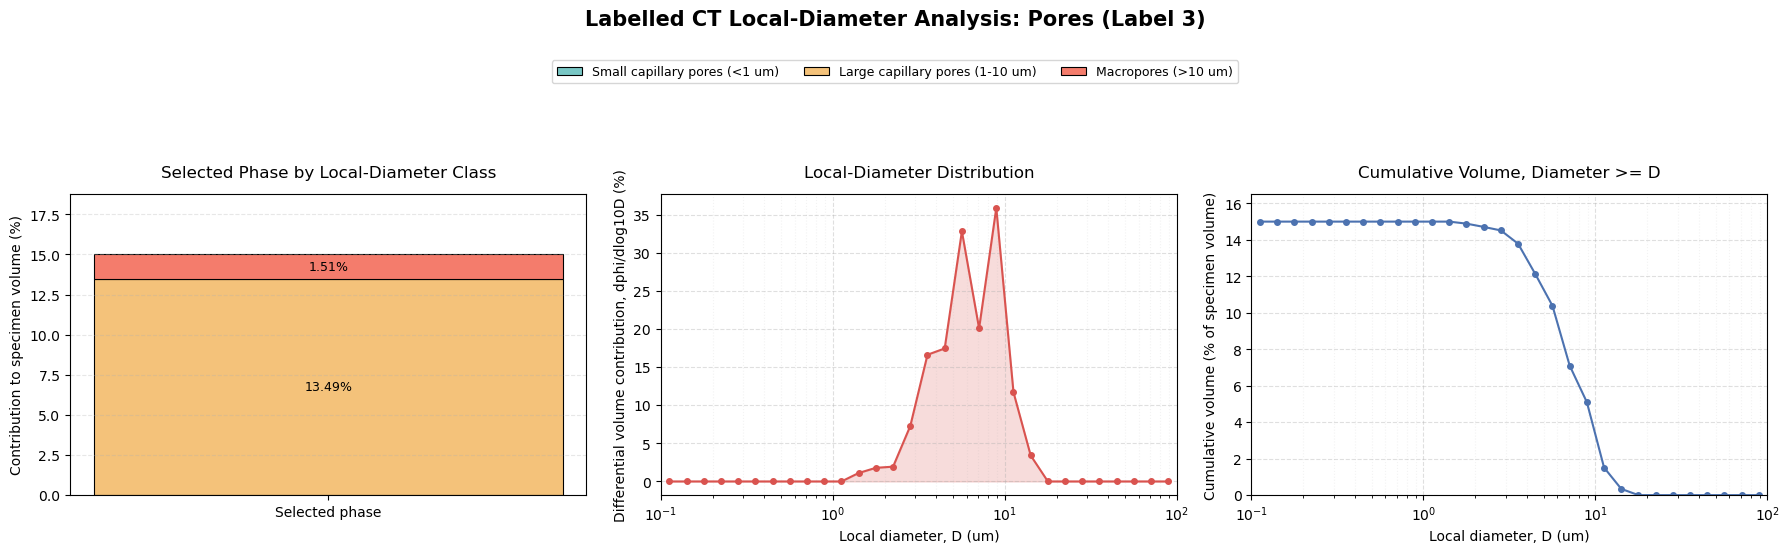


User-Selected Label Local-Diameter Analysis Results
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif
Volume shape (Z, Y, X): (100, 100, 100)
Selected label: 3
Selected phase name: Pores
Volume-fraction denominator: complete input image volume
Isotropic voxel size: 0.700000 um
Specimen denominator voxel count: 1,000,000
Selected-phase voxel count: 150,000
Selected-phase volume fraction: 15.0000%
------------------------------------------------------------------------
Minimum local diameter: 1.4000 um
Mean local diameter: 6.6722 um
Median local diameter: 6.2271 um
Maximum local diameter: 13.1332 um

Volume contribution by local-diameter class
Small capillary pores (<1 um): 0.0000% of specimen; 0.0000% of selected phase
Large capillary pores (1-10 um): 13.4900% of specimen; 89.9333% of selected phase
Macropores (>10 um): 1.5100% of specimen; 10.0667% of selected phase
------------------------------------------------------------------------
Sum of c

In [4]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter
import numpy as np
import pandas as pd
import porespy as ps
import tifffile


# =============================================================================
# Optional non-interactive settings
# =============================================================================

# Use None to select a labelled TIFF interactively.
# Example: INPUT_TIFF = Path(r"C:\Users\your_name\labelled_volume.tif")
INPUT_TIFF: Optional[Path] = None

# Use None to select the analysis label interactively.
# Example: PREDEFINED_ANALYSIS_LABEL = 3
PREDEFINED_ANALYSIS_LABEL: Optional[int] = None

# Use None to enter the selected phase name interactively.
# Example: PREDEFINED_PHASE_NAME = "Pores"
PREDEFINED_PHASE_NAME: Optional[str] = None

# =============================================================================
# Pore-size analysis settings
# =============================================================================

SMALL_PORE_LIMIT_UM = 1.0
LARGE_PORE_LIMIT_UM = 10.0

PLOT_X_MIN_UM = 1.0e-1
PLOT_X_MAX_UM = 1.0e2
NUMBER_OF_BINS = 30


def select_tiff_file() -> Path:
    """Open a labelled TIFF file-selection dialog, with a text fallback."""
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected = filedialog.askopenfilename(
            title="Select a labelled 3D TIFF file",
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )
        root.destroy()
        if selected:
            return Path(selected)
    except Exception:
        pass

    user_input = input("Enter the path of the labelled 3D TIFF file: ").strip()
    user_input = user_input.strip('"').strip("'")
    if not user_input:
        raise ValueError("No input TIFF file was selected.")
    return resolve_tiff_path(user_input)


def resolve_tiff_path(user_input: str) -> Path:
    """Resolve an input path and validate its TIFF extension."""
    file_path = Path(user_input.strip().strip('"').strip("'"))
    if not file_path.suffix:
        tif_candidate = file_path.with_suffix(".tif")
        tiff_candidate = file_path.with_suffix(".tiff")
        if tif_candidate.exists():
            file_path = tif_candidate
        elif tiff_candidate.exists():
            file_path = tiff_candidate

    if not file_path.exists():
        raise FileNotFoundError(f"TIFF file not found: {file_path.resolve()}")
    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError("The selected file must have a .tif or .tiff extension.")
    return file_path


def load_labelled_volume(file_path: Path) -> np.ndarray:
    """Load and validate an integer-labelled 3D TIFF volume."""
    volume = np.squeeze(np.asarray(tifffile.imread(file_path)))
    if volume.size == 0:
        raise ValueError("The TIFF file contains no image data.")
    if volume.ndim != 3:
        raise ValueError(
            f"The input must be a 3D TIFF volume. Detected shape: {volume.shape}"
        )
    if not np.issubdtype(volume.dtype, np.integer):
        if np.all(np.isfinite(volume)) and np.all(volume == np.round(volume)):
            volume = np.round(volume).astype(np.int32)
        else:
            raise TypeError("The labelled TIFF must contain integer label values.")
    return volume


def display_observed_labels(volume: np.ndarray) -> np.ndarray:
    """Print all detected labels and their voxel counts."""
    labels, counts = np.unique(volume, return_counts=True)
    print("\nLabels detected in the TIFF volume")
    print("-" * 56)
    for label, count in zip(labels, counts):
        percentage = 100.0 * count / volume.size
        print(
            f"Label {int(label):>8}: {int(count):>14,} voxels "
            f"({percentage:9.4f}% of complete image)"
        )
    return labels


def get_analysis_label(observed_labels: np.ndarray) -> int:
    """Request and validate the label selected for size analysis."""
    observed_set = {int(label) for label in observed_labels}
    if PREDEFINED_ANALYSIS_LABEL is not None:
        selected_label = int(PREDEFINED_ANALYSIS_LABEL)
        if selected_label not in observed_set:
            raise ValueError(
                f"PREDEFINED_ANALYSIS_LABEL {selected_label} is absent from the TIFF."
            )
        return selected_label

    while True:
        user_input = input("\nEnter the label value to analyse: ").strip()
        try:
            selected_label = int(user_input)
        except ValueError:
            print("The analysis label must be an integer.")
            continue
        if selected_label not in observed_set:
            print(
                f"Label {selected_label} was not detected. Available labels: "
                f"{sorted(observed_set)}"
            )
            continue
        return selected_label


def get_phase_name(selected_label: int) -> str:
    """Request a descriptive name for the selected label."""
    if PREDEFINED_PHASE_NAME is not None:
        name = str(PREDEFINED_PHASE_NAME).strip()
        if not name:
            raise ValueError("PREDEFINED_PHASE_NAME cannot be empty.")
        return name

    user_input = input(
        f"Enter the phase name for label {selected_label} [default: Pores]: "
    ).strip()
    return user_input if user_input else "Pores"


def get_positive_float(prompt: str, default: float = 1.0) -> float:
    """Request a positive floating-point value."""
    while True:
        user_input = input(f"{prompt} [default: {default}]: ").strip()
        if not user_input:
            return default
        try:
            value = float(user_input)
            if value <= 0:
                raise ValueError
            return value
        except ValueError:
            print("Please enter a positive numerical value.")


def get_isotropic_voxel_size() -> float:
    """Request the isotropic physical voxel size in micrometres."""
    print("\nLocal-thickness analysis requires an isotropic voxel size.")
    return get_positive_float("Enter the isotropic voxel size (um)", 1.0)


def create_analysis_masks(
    volume: np.ndarray,
    selected_label: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Create the selected-phase mask and complete-volume denominator mask."""
    selected_mask = volume == selected_label
    specimen_mask = np.ones(volume.shape, dtype=bool)
    if not np.any(selected_mask):
        raise ValueError("No voxels belonging to the selected label were found.")
    return selected_mask, specimen_mask


def calculate_local_diameter(
    selected_mask: np.ndarray,
    voxel_size_um: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate the local-thickness diameter map in micrometres."""
    print("\nCalculating the local diameter of the selected phase...")
    print("This step may take several minutes for a large volume.")
    local_radius_voxels = ps.filters.local_thickness(
        selected_mask,
        method="dt",
    )
    local_diameter_um = 2.0 * local_radius_voxels * voxel_size_um
    selected_diameters_um = local_diameter_um[selected_mask]
    valid = np.isfinite(selected_diameters_um) & (selected_diameters_um > 0)
    selected_diameters_um = selected_diameters_um[valid]
    if selected_diameters_um.size == 0:
        raise ValueError("No positive local diameters were calculated.")
    return local_diameter_um.astype(np.float32), selected_diameters_um


def calculate_size_classes(
    selected_diameters_um: np.ndarray,
    specimen_voxel_count: int,
    selected_voxel_count: int,
) -> pd.DataFrame:
    """Calculate selected-phase contributions for three diameter classes."""
    class_definitions = [
        (
            f"Small capillary pores (<{SMALL_PORE_LIMIT_UM:g} um)",
            f"D < {SMALL_PORE_LIMIT_UM:g} um",
            selected_diameters_um < SMALL_PORE_LIMIT_UM,
            "#79C7C5",
        ),
        (
            f"Large capillary pores ({SMALL_PORE_LIMIT_UM:g}-{LARGE_PORE_LIMIT_UM:g} um)",
            f"{SMALL_PORE_LIMIT_UM:g} um <= D <= {LARGE_PORE_LIMIT_UM:g} um",
            (selected_diameters_um >= SMALL_PORE_LIMIT_UM)
            & (selected_diameters_um <= LARGE_PORE_LIMIT_UM),
            "#F4C27A",
        ),
        (
            f"Macropores (>{LARGE_PORE_LIMIT_UM:g} um)",
            f"D > {LARGE_PORE_LIMIT_UM:g} um",
            selected_diameters_um > LARGE_PORE_LIMIT_UM,
            "#F47C6C",
        ),
    ]
    rows = []
    for class_name, diameter_range, class_mask, colour in class_definitions:
        voxel_count = int(np.count_nonzero(class_mask))
        rows.append(
            {
                "Pore-size class": class_name,
                "Diameter range": diameter_range,
                "Voxel count": voxel_count,
                "Contribution to specimen volume (%)": (
                    100.0 * voxel_count / specimen_voxel_count
                ),
                "Fraction of selected phase (%)": (
                    100.0 * voxel_count / selected_voxel_count
                ),
                "Plot colour": colour,
            }
        )
    return pd.DataFrame(rows)


def calculate_size_distribution(
    selected_diameters_um: np.ndarray,
    specimen_voxel_count: int,
    selected_voxel_count: int,
    number_of_bins: int = NUMBER_OF_BINS,
) -> pd.DataFrame:
    """Calculate differential and cumulative volume-weighted distributions."""
    measured_min = float(selected_diameters_um.min())
    measured_max = float(selected_diameters_um.max())
    analysis_min = min(PLOT_X_MIN_UM, measured_min * (1.0 - 1.0e-9))
    analysis_max = max(PLOT_X_MAX_UM, measured_max * (1.0 + 1.0e-9))
    bin_edges = np.logspace(
        np.log10(analysis_min),
        np.log10(analysis_max),
        number_of_bins + 1,
    )
    voxel_counts, bin_edges = np.histogram(selected_diameters_um, bins=bin_edges)
    bin_centres = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    log_bin_widths = np.diff(np.log10(bin_edges))
    incremental_specimen_percent = 100.0 * voxel_counts / specimen_voxel_count
    incremental_selected_percent = 100.0 * voxel_counts / selected_voxel_count
    differential_specimen_percent = incremental_specimen_percent / log_bin_widths
    differential_selected_percent = incremental_selected_percent / log_bin_widths
    cumulative_specimen_percent = np.cumsum(
        incremental_specimen_percent[::-1]
    )[::-1]
    cumulative_selected_percent = np.cumsum(
        incremental_selected_percent[::-1]
    )[::-1]

    return pd.DataFrame(
        {
            "Lower diameter boundary (um)": bin_edges[:-1],
            "Upper diameter boundary (um)": bin_edges[1:],
            "Bin-centre diameter (um)": bin_centres,
            "Selected-phase voxel count": voxel_counts,
            "Incremental specimen-volume contribution (%)": (
                incremental_specimen_percent
            ),
            "Incremental selected-phase fraction (%)": incremental_selected_percent,
            "Differential specimen contribution, dphi/dlog10D (%)": (
                differential_specimen_percent
            ),
            "Differential selected-phase fraction, dV/dlog10D (%)": (
                differential_selected_percent
            ),
            "Cumulative specimen contribution, diameter >= D (%)": (
                cumulative_specimen_percent
            ),
            "Cumulative selected-phase fraction, diameter >= D (%)": (
                cumulative_selected_percent
            ),
        }
    )


def format_log_diameter_axis(axis: plt.Axes) -> None:
    """Format the displayed diameter range from 10^-1 to 10^2 um."""
    axis.set_xscale("log")
    axis.set_xlim(PLOT_X_MIN_UM, PLOT_X_MAX_UM)
    axis.set_xticks([1.0e-1, 1.0e0, 1.0e1, 1.0e2])
    axis.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
    axis.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
    )
    axis.xaxis.set_minor_formatter(NullFormatter())


def plot_results(
    size_classes: pd.DataFrame,
    distribution: pd.DataFrame,
    selected_phase_fraction_percent: float,
    selected_label: int,
    phase_name: str,
    output_path: Path,
) -> None:
    """Create the size-class, differential, and cumulative plots."""
    figure, axes = plt.subplots(1, 3, figsize=(18, 5.6))
    bottom_value = 0.0
    for _, row in size_classes.iterrows():
        value = float(row["Contribution to specimen volume (%)"])
        axes[0].bar(
            "Selected phase",
            value,
            bottom=bottom_value,
            width=0.55,
            color=row["Plot colour"],
            edgecolor="black",
            linewidth=0.8,
            label=row["Pore-size class"],
        )
        if value >= 0.1:
            axes[0].text(
                0,
                bottom_value + value / 2.0,
                f"{value:.2f}%",
                ha="center",
                va="center",
                fontsize=9,
            )
        bottom_value += value

    axes[0].set_ylabel("Contribution to specimen volume (%)")
    axes[0].set_title("Selected Phase by Local-Diameter Class", pad=12)
    axes[0].set_ylim(0, max(selected_phase_fraction_percent * 1.25, 1.0))
    axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    diameter = distribution["Bin-centre diameter (um)"].to_numpy()
    differential = distribution[
        "Differential specimen contribution, dphi/dlog10D (%)"
    ].to_numpy()
    axes[1].plot(
        diameter,
        differential,
        color="#D9534F",
        marker="o",
        markersize=4,
        linewidth=1.5,
    )
    axes[1].fill_between(diameter, differential, color="#D9534F", alpha=0.20)
    format_log_diameter_axis(axes[1])
    axes[1].set_xlabel("Local diameter, D (um)")
    axes[1].set_ylabel("Differential volume contribution, dphi/dlog10D (%)")
    axes[1].set_title("Local-Diameter Distribution", pad=12)
    axes[1].grid(which="major", linestyle="--", alpha=0.4)
    axes[1].grid(which="minor", linestyle=":", alpha=0.15)

    cumulative = distribution[
        "Cumulative specimen contribution, diameter >= D (%)"
    ].to_numpy()
    axes[2].plot(
        diameter,
        cumulative,
        color="#4C72B0",
        marker="o",
        markersize=4,
        linewidth=1.5,
    )
    format_log_diameter_axis(axes[2])
    axes[2].set_xlabel("Local diameter, D (um)")
    axes[2].set_ylabel("Cumulative volume (% of specimen volume)")
    axes[2].set_title("Cumulative Volume, Diameter >= D", pad=12)
    axes[2].set_ylim(0, max(selected_phase_fraction_percent * 1.1, 1.0))
    axes[2].grid(which="major", linestyle="--", alpha=0.4)
    axes[2].grid(which="minor", linestyle=":", alpha=0.15)

    handles, labels = axes[0].get_legend_handles_labels()
    figure.suptitle(
        f"Labelled CT Local-Diameter Analysis: {phase_name} (Label {selected_label})",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=min(3, len(labels)),
        fontsize=9,
        frameon=True,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.79])
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    # Display the figure reliably inside Jupyter Notebook.  This avoids the
    # "FigureCanvasAgg is non-interactive" warning produced by plt.show()
    # when Matplotlib is using the non-interactive Agg backend.  The fallback
    # keeps the script usable outside IPython/Jupyter.
    try:
        from IPython.display import display

        display(figure)
    except ImportError:
        plt.show()
    finally:
        plt.close(figure)


def save_analysis_volumes(
    selected_mask: np.ndarray,
    local_diameter_map_um: np.ndarray,
    mask_output_path: Path,
    diameter_output_path: Path,
) -> None:
    """Save the selected-label mask and local-diameter map."""
    tifffile.imwrite(
        mask_output_path,
        selected_mask.astype(np.uint8) * 255,
        photometric="minisblack",
        compression="zlib",
        metadata={"axes": "ZYX", "binary_convention": "0=excluded, 255=selected"},
    )
    tifffile.imwrite(
        diameter_output_path,
        local_diameter_map_um.astype(np.float32),
        photometric="minisblack",
        compression="zlib",
        metadata={"axes": "ZYX", "quantity": "local diameter", "unit": "um"},
    )


def create_summary_table(
    file_path: Path,
    volume: np.ndarray,
    observed_labels: np.ndarray,
    selected_label: int,
    phase_name: str,
    voxel_size_um: float,
    specimen_voxel_count: int,
    selected_voxel_count: int,
    selected_diameters_um: np.ndarray,
) -> pd.DataFrame:
    """Create the analysis summary table."""
    selected_fraction = 100.0 * selected_voxel_count / specimen_voxel_count
    records = [
        ("Input file", str(file_path.resolve()), ""),
        ("Volume shape (Z, Y, X)", str(volume.shape), "voxels"),
        ("Input data type", str(volume.dtype), ""),
        ("Observed labels", str(observed_labels.tolist()), ""),
        ("Selected analysis label", selected_label, ""),
        ("Selected phase name", phase_name, ""),
        ("Volume-fraction denominator", "Complete input image volume", ""),
        ("Isotropic voxel size", voxel_size_um, "um"),
        ("Complete image voxel count", volume.size, "voxels"),
        ("Specimen denominator voxel count", specimen_voxel_count, "voxels"),
        ("Selected-phase voxel count", selected_voxel_count, "voxels"),
        ("Selected-phase volume fraction", selected_fraction, "%"),
        ("Minimum local diameter", selected_diameters_um.min(), "um"),
        ("Mean local diameter", selected_diameters_um.mean(), "um"),
        ("Median local diameter", np.median(selected_diameters_um), "um"),
        ("Maximum local diameter", selected_diameters_um.max(), "um"),
        ("Local-diameter definition", "2 x PoreSpy local radius x voxel size", ""),
        ("Distribution weighting", "Selected-phase voxel-volume weighted", ""),
    ]
    return pd.DataFrame(records, columns=["Parameter", "Value", "Unit"])


def export_excel(
    summary: pd.DataFrame,
    size_classes: pd.DataFrame,
    distribution: pd.DataFrame,
    output_path: Path,
) -> None:
    """Export the analysis results to a formatted Excel workbook."""
    cumulative_columns = [
        "Bin-centre diameter (um)",
        "Cumulative specimen contribution, diameter >= D (%)",
        "Cumulative selected-phase fraction, diameter >= D (%)",
    ]
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        size_classes.drop(columns="Plot colour").to_excel(
            writer, sheet_name="Size Classes", index=False
        )
        distribution.to_excel(writer, sheet_name="Size Distribution", index=False)
        distribution[cumulative_columns].to_excel(
            writer, sheet_name="Cumulative Volume", index=False
        )

        for worksheet in writer.sheets.values():
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions
            for column_cells in worksheet.columns:
                maximum_length = max(
                    len(str(cell.value)) if cell.value is not None else 0
                    for cell in column_cells
                )
                worksheet.column_dimensions[column_cells[0].column_letter].width = min(
                    maximum_length + 2, 62
                )


def print_results(
    file_path: Path,
    volume: np.ndarray,
    selected_label: int,
    phase_name: str,
    voxel_size_um: float,
    specimen_voxel_count: int,
    selected_voxel_count: int,
    selected_diameters_um: np.ndarray,
    size_classes: pd.DataFrame,
    output_paths: dict[str, Path],
) -> None:
    """Print a compact summary of the analysis."""
    selected_fraction = 100.0 * selected_voxel_count / specimen_voxel_count
    print("\nUser-Selected Label Local-Diameter Analysis Results")
    print("=" * 72)
    print(f"Input file: {file_path.resolve()}")
    print(f"Volume shape (Z, Y, X): {volume.shape}")
    print(f"Selected label: {selected_label}")
    print(f"Selected phase name: {phase_name}")
    print("Volume-fraction denominator: complete input image volume")
    print(f"Isotropic voxel size: {voxel_size_um:.6f} um")
    print(f"Specimen denominator voxel count: {specimen_voxel_count:,}")
    print(f"Selected-phase voxel count: {selected_voxel_count:,}")
    print(f"Selected-phase volume fraction: {selected_fraction:.4f}%")
    print("-" * 72)
    print(f"Minimum local diameter: {selected_diameters_um.min():.4f} um")
    print(f"Mean local diameter: {selected_diameters_um.mean():.4f} um")
    print(f"Median local diameter: {np.median(selected_diameters_um):.4f} um")
    print(f"Maximum local diameter: {selected_diameters_um.max():.4f} um")
    print("\nVolume contribution by local-diameter class")
    for _, row in size_classes.iterrows():
        print(
            f"{row['Pore-size class']}: "
            f"{row['Contribution to specimen volume (%)']:.4f}% of specimen; "
            f"{row['Fraction of selected phase (%)']:.4f}% of selected phase"
        )
    print("-" * 72)
    print(
        "Sum of class contributions: "
        f"{size_classes['Contribution to specimen volume (%)'].sum():.6f}%"
    )
    print("\nSaved outputs:")
    for name, path in output_paths.items():
        print(f"  {name}: {path.resolve()}")


def main() -> None:
    """Run the complete labelled-volume local-diameter analysis."""
    if INPUT_TIFF is None:
        file_path = select_tiff_file()
    else:
        file_path = resolve_tiff_path(str(INPUT_TIFF))

    print("\nLoading the labelled TIFF volume...")
    volume = load_labelled_volume(file_path)
    observed_labels = display_observed_labels(volume)
    selected_label = get_analysis_label(observed_labels)
    phase_name = get_phase_name(selected_label)
    voxel_size_um = get_isotropic_voxel_size()

    selected_mask, specimen_mask = create_analysis_masks(
        volume,
        selected_label,
    )
    specimen_voxel_count = int(np.count_nonzero(specimen_mask))
    selected_voxel_count = int(np.count_nonzero(selected_mask))
    selected_phase_fraction_percent = (
        100.0 * selected_voxel_count / specimen_voxel_count
    )

    local_diameter_map_um, selected_diameters_um = calculate_local_diameter(
        selected_mask,
        voxel_size_um,
    )
    size_classes = calculate_size_classes(
        selected_diameters_um,
        specimen_voxel_count,
        selected_voxel_count,
    )
    distribution = calculate_size_distribution(
        selected_diameters_um,
        specimen_voxel_count,
        selected_voxel_count,
        NUMBER_OF_BINS,
    )
    summary = create_summary_table(
        file_path,
        volume,
        observed_labels,
        selected_label,
        phase_name,
        voxel_size_um,
        specimen_voxel_count,
        selected_voxel_count,
        selected_diameters_um,
    )

    base = file_path.with_suffix("")
    safe_phase_name = "".join(
        character if character.isalnum() else "_" for character in phase_name
    ).strip("_") or "selected_phase"
    output_prefix = base.parent / (
        f"{base.name}_label_{selected_label}_{safe_phase_name}"
    )
    output_paths = {
        "Selected-label mask": output_prefix.with_name(
            output_prefix.name + "_binary_mask.tif"
        ),
        "Local-diameter map": output_prefix.with_name(
            output_prefix.name + "_local_diameter_um.tif"
        ),
        "Analysis figure": output_prefix.with_name(
            output_prefix.name + "_pore_size_analysis.png"
        ),
        "Excel workbook": output_prefix.with_name(
            output_prefix.name + "_pore_size_analysis.xlsx"
        ),
    }

    save_analysis_volumes(
        selected_mask,
        local_diameter_map_um,
        output_paths["Selected-label mask"],
        output_paths["Local-diameter map"],
    )
    plot_results(
        size_classes,
        distribution,
        selected_phase_fraction_percent,
        selected_label,
        phase_name,
        output_paths["Analysis figure"],
    )
    export_excel(
        summary,
        size_classes,
        distribution,
        output_paths["Excel workbook"],
    )
    print_results(
        file_path,
        volume,
        selected_label,
        phase_name,
        voxel_size_um,
        specimen_voxel_count,
        selected_voxel_count,
        selected_diameters_um,
        size_classes,
        output_paths,
    )


if __name__ == "__main__":
    main()

In [27]:
"""
%pip install openpnm pyamg
"""

'\n%pip install openpnm pyamg\n'

## 4. Directional Diffusion Tortuosity Analysis

### Purpose

This module calculates direction-dependent diffusion tortuosity, formation
factor, and relative effective diffusivity from previously extracted
through-connected pore masks.

Only pore regions that form a continuous pathway between two opposing boundary
faces can contribute to steady-state transport in the corresponding direction.
The analysis therefore uses the directional through-connected pore masks
generated by the preceding connectivity-analysis module rather than the
complete pore-space volume.

The calculations are performed independently along the X, Y, and Z directions
to evaluate transport anisotropy within the segmented three-dimensional
microstructure.

---

### Position within the workflow

This module is applied after directional through-connectivity analysis.

The required processing sequence is:

```text
Labelled 3D CT volume
        ↓
User-selected pore label
        ↓
6-connected component analysis
        ↓
X-, Y-, and Z-through-connected pore masks
        ↓
Finite-difference diffusion simulation
        ↓
Directional tortuosity, formation factor, and effective diffusivity
```

Pores that do not form a through-connected pathway in the analysed direction
are excluded from the corresponding diffusion simulation.

---

### Required input files

The user first selects the original labelled 3D TIFF volume associated with the
directional connectivity analysis.

For an input file named:

```text
sample.tif
```

the module automatically searches the same directory for:

```text
sample_through_connected_X.tif
sample_through_connected_Y.tif
sample_through_connected_Z.tif
```

For example:

```text
synthetic_labelled_cement_4phase_100.tif

synthetic_labelled_cement_4phase_100_through_connected_X.tif
synthetic_labelled_cement_4phase_100_through_connected_Y.tif
synthetic_labelled_cement_4phase_100_through_connected_Z.tif
```

All three directional masks must:

- Be three-dimensional TIFF volumes
- Have identical dimensions
- Correspond to the same original CT dataset
- Use the same spatial orientation
- Contain unsigned 8-bit binary values
- Have been generated using strict 3D 6-connectivity

The physical isotropic voxel size must be entered by the user in micrometres.

---

### Connected-mask convention

The directional masks use the following binary convention:

| Value | Meaning |
|---:|---|
| 0 | Solid or pore space that is not through-connected in the analysed direction |
| 255 | Directionally through-connected pore space |

Internally, the code converts these values into a Boolean mask:

```text
False = background
True  = directionally through-connected pore
```

The use of 0 and 255 rather than 0 and 1 does not affect the calculation,
because the TIFF values are converted to Boolean values before analysis.

---

### Connectivity definition

The input masks must be generated using strict face-based connectivity.

Only pore voxels sharing a complete voxel face are treated as connected:

```text
Face connection   = included
Edge connection   = excluded
Corner connection = excluded
```

This definition corresponds to 6-connectivity in three dimensions.

A pore component is considered through-connected in a given direction when it
touches both opposing boundary faces:

| Direction | Through-connectivity condition |
|---|---|
| X | Component touches both X-min and X-max |
| Y | Component touches both Y-min and Y-max |
| Z | Component touches both Z-min and Z-max |

This requirement ensures that the analysed pore region can support transport
across the complete image volume in the selected direction.

---

### Coordinate convention

The TIFF volume is loaded into NumPy using the following array order:

```text
Array shape = (Z, Y, X)
```

The directional correspondence is therefore:

| Physical direction | NumPy axis |
|---|---:|
| X | 2 |
| Y | 1 |
| Z | 0 |

The direction convention must remain consistent between the connectivity and
diffusion-tortuosity modules.

---

### Connected porosity

For direction $j$, the connected porosity of the directional input mask is
calculated as:

$$
\phi_{\mathrm{connected},j}
=
\frac{N_{\mathrm{connected},j}}{N_{\mathrm{total}}}
$$

where:

- $N_{\mathrm{connected},j}$ is the number of through-connected pore voxels in direction $j$
- $N_{\mathrm{total}}$ is the total number of voxels in the analysed 3D volume
- $j$ represents the X, Y, or Z direction

Connected porosity is dimensionless and may also be reported as a percentage:

$$
\phi_{\mathrm{connected},j}(\%)
=
100\phi_{\mathrm{connected},j}
$$

Because different pore components may percolate in different directions, the
connected porosity can differ between X, Y, and Z.

---

### Finite-difference diffusion model

The steady-state diffusion equation is solved within each directional
through-connected pore mask:

$$
\nabla \cdot \left(D_0 \nabla C\right) = 0
$$

where:

- $C$ is the dimensionless concentration
- $D_0$ is the intrinsic diffusivity of the diffusing species in unobstructed pore space

A concentration difference is applied between the two opposing boundary faces
of the analysed direction.

Conceptually, the boundary conditions are:

```text
Inlet concentration  = 1
Outlet concentration = 0
Solid phase          = impermeable
Lateral boundaries   = no-flux
```

The resulting steady-state concentration field is used to calculate the
effective transport response of the connected pore structure.

The calculation is performed using the PoreSpy finite-difference tortuosity
solver together with OpenPNM's PyAMG Ruge-Stuben linear solver.

The numerical solver settings are:

| Parameter | Value |
|---|---:|
| Solver | PyAMG Ruge-Stuben solver |
| Solver tolerance | $1 \times 10^{-10}$ |
| Maximum iterations | 5000 |

---

### Relative effective diffusivity

The effective diffusivity describes the diffusion rate through the resolved
pore structure relative to diffusion through unobstructed pore space.

The relative effective diffusivity is:

$$
D_{\mathrm{rel},j}
=
\frac{D_{\mathrm{eff},j}}{D_0}
$$

where:

- $D_{\mathrm{eff},j}$ is the effective diffusivity in direction $j$
- $D_0$ is the intrinsic diffusivity in unobstructed pore space

The result is dimensionless.

A larger value indicates more efficient transport through the connected pore
network. A value approaching zero indicates strongly restricted transport or
the absence of a through-connected transport pathway.

If the physical intrinsic diffusivity $D_0$ of a particular species is known,
the dimensional effective diffusivity can be calculated as:

$$
D_{\mathrm{eff},j}
=
D_{\mathrm{rel},j}D_0
$$

The units of $D_{\mathrm{eff},j}$ are therefore the same as those of $D_0$, such
as $\mathrm{m^2\,s^{-1}}$.

---

### Formation factor

The directional formation factor is calculated as:

$$
F_j
=
\frac{D_0}{D_{\mathrm{eff},j}}
$$

Equivalently:

$$
F_j
=
\frac{1}{D_{\mathrm{rel},j}}
$$

The formation factor is dimensionless.

A larger formation factor indicates greater resistance to diffusion through the
resolved pore structure.

---

### Diffusion tortuosity

The directional diffusion tortuosity factor is calculated as:

$$
\tau_j
=
\phi_{\mathrm{eff},j}F_j
$$

where:

- $\tau_j$ is the diffusion tortuosity factor in direction $j$
- $\phi_{\mathrm{eff},j}$ is the effective porosity reported by the solver
- $F_j$ is the directional formation factor

Using the relative effective diffusivity, the same relationship can be written
as:

$$
\tau_j
=
\frac{\phi_{\mathrm{eff},j}}
{D_{\mathrm{eff},j}/D_0}
$$

Therefore:

$$
\frac{D_{\mathrm{eff},j}}{D_0}
=
\frac{\phi_{\mathrm{eff},j}}{\tau_j}
$$

The reported tortuosity is a dimensionless diffusion tortuosity factor derived
from the simulated transport response. It should not be interpreted directly
as the geometric ratio between an individual pore-path length and the straight
sample length.

A larger tortuosity value indicates a more restrictive, indirect, or
constricted diffusion pathway.

---

### Treatment of non-percolating directions

Before solving the diffusion equation, the module verifies that the input mask
contains a component spanning the complete analysed direction.

If no through-connected pathway exists:

```text
Status                          = Not percolating
Relative effective diffusivity = 0
Formation factor                = undefined
Diffusion tortuosity            = undefined
```

Undefined values are recorded as `NaN` in the numerical results.

The solver is not applied to an empty or non-percolating directional mask.

---

### Analysis outputs

For each of the X, Y, and Z directions, the module reports:

- Analysis status
- NumPy axis
- Connected-mask filename
- Number of percolating components
- Through-connected pore voxel count
- Input connected porosity
- Solver original porosity
- Solver effective porosity
- Formation factor
- Relative effective diffusivity
- Diffusion tortuosity
- Concentration-field output path

---

### Concentration-field TIFF volumes

The simulated steady-state concentration fields are exported as floating-point
3D TIFF volumes:

```text
sample_diffusion_concentration_X.tif
sample_diffusion_concentration_Y.tif
sample_diffusion_concentration_Z.tif
```

The concentration maps are stored as `float32` values.

Concentration is dimensionless and nominally varies from:

```text
0 = outlet concentration
1 = inlet concentration
```

Values outside the connected pore space are stored as background values.

These volumes can be opened in software such as Fiji, ImageJ, Avizo, or
Dragonfly to visualise the spatial concentration gradient through the pore
network.

---

### Excel output

The numerical results are exported to:

```text
sample_diffusion_tortuosity_analysis.xlsx
```

The workbook contains:

1. Directional diffusion-tortuosity results
2. Formation factors
3. Relative effective diffusivities
4. Connected and effective porosities
5. Solver settings
6. Input-file information
7. Volume dimensions and voxel-size metadata
8. Output concentration-field paths

---

### Figure output

A summary figure is exported to:

```text
sample_diffusion_tortuosity_analysis.png
```

The figure contains three directional bar charts:

1. Diffusion tortuosity
2. Formation factor
3. Relative effective diffusivity

The X-, Y-, and Z-directional results are displayed together to facilitate
comparison of transport anisotropy.

The figure is also displayed directly within Jupyter Notebook.

---

### Scientific interpretation

Directional differences in tortuosity, formation factor, and relative effective
diffusivity indicate anisotropy in the resolved pore network.

For example:

- Similar X, Y, and Z results suggest approximately isotropic transport
- A lower tortuosity in one direction indicates a less restrictive transport pathway
- A higher relative effective diffusivity indicates more efficient diffusion
- A higher formation factor indicates greater resistance to diffusion
- A non-percolating direction indicates no resolved continuous transport pathway across the analysed volume

The results describe transport through the XRµCT-resolved pore structure and
do not automatically include pores smaller than the image resolution.

---

### Methodological limitations

The calculated transport properties depend on:

- Image resolution
- Segmentation quality
- Analysed volume size
- Representative elementary volume
- Boundary truncation of the pore network
- Connectivity definition
- Accuracy of the directional pore masks
- Assumption of uniform intrinsic diffusivity within the pore phase
- Assumption of impermeable solid phases
- Absence of additional interfacial or chemical transport resistance

Sub-resolution gel pores and other unresolved pore structures are not
represented unless they are incorporated through a separate multiscale
transport model.

Consequently, the calculated values should be described as transport properties
of the resolved three-dimensional pore network rather than complete bulk
material transport properties.

OpenPNM version: 3.6.2
PoreSpy version: 3.0.4
Selected input TIFF: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif


Enter the isotropic voxel size (µm) [default: 1.0]:  0.7



Calculating X-direction diffusion tortuosity...

Calculating Y-direction diffusion tortuosity...

Calculating Z-direction diffusion tortuosity...


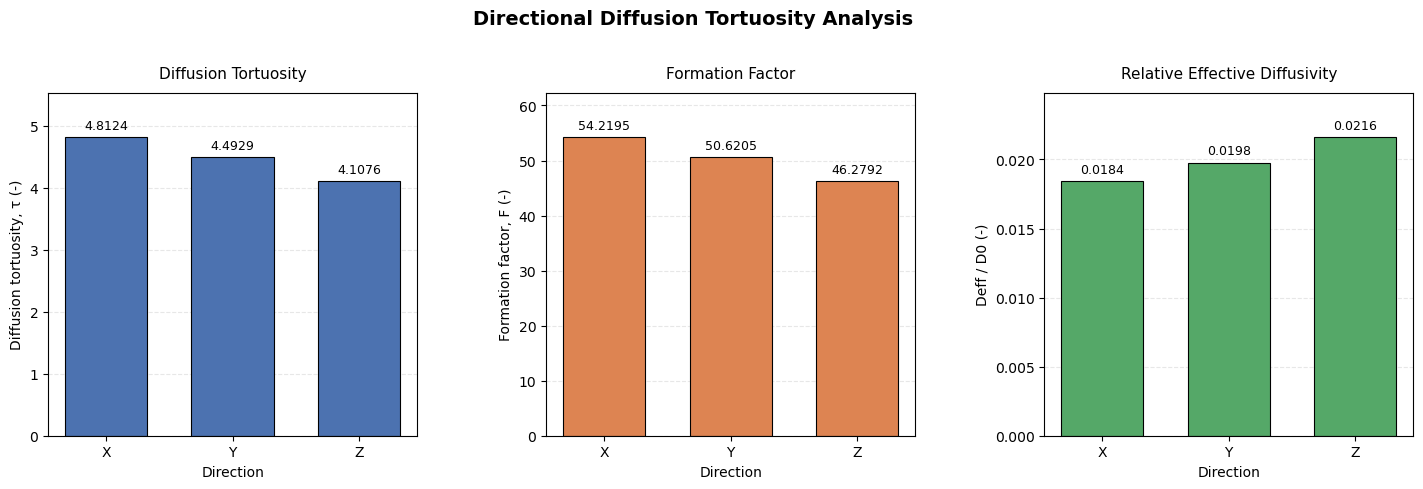


Directional Diffusion Tortuosity Results
--------------------------------------------------
Solver: OpenPNM PyamgRugeStubenSolver
Solver tolerance: 1.0e-10
Maximum iterations: 5000

X-direction
Status: Completed
Input connected porosity: 8.8757%
Effective porosity: 8.8757%
Formation factor, D0/Deff: 54.219520
Relative effective diffusivity, Deff/D0: 0.018444
Diffusion tortuosity: 4.812362
Solver time: 3.003 s

Y-direction
Status: Completed
Input connected porosity: 8.8757%
Effective porosity: 8.8757%
Formation factor, D0/Deff: 50.620480
Relative effective diffusivity, Deff/D0: 0.019755
Diffusion tortuosity: 4.492922
Solver time: 1.566 s

Z-direction
Status: Completed
Input connected porosity: 8.8757%
Effective porosity: 8.8757%
Formation factor, D0/Deff: 46.279170
Relative effective diffusivity, Deff/D0: 0.021608
Diffusion tortuosity: 4.107600
Solver time: 1.571 s

Excel results: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_diffusion_tortuosity_analysis.xls

In [32]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import openpnm as op
import pandas as pd
import porespy as ps
from scipy import ndimage
import tifffile


DIRECTION_TO_AXIS = {
    "X": 2,
    "Y": 1,
    "Z": 0,
}

SOLVER_TOLERANCE = 1e-10
SOLVER_MAXIMUM_ITERATIONS = 5000

# Use None to select the original TIFF interactively.
# To bypass the file-selection window, provide a complete path, for example:
# INPUT_TIFF = Path(r"C:\Users\your_name\sample.tif")
INPUT_TIFF: Optional[Path] = None


def resolve_original_tiff_path(user_input):
    """
    Resolve the original binary TIFF path.

    The original file name is used to locate the directionally
    connected pore masks.
    """

    file_path = Path(
        user_input.strip().strip("\"'")
    )

    if not file_path.suffix:
        tif_candidate = file_path.with_suffix(".tif")
        tiff_candidate = file_path.with_suffix(".tiff")

        if tif_candidate.exists():
            file_path = tif_candidate
        elif tiff_candidate.exists():
            file_path = tiff_candidate

    if not file_path.exists():
        raise FileNotFoundError(
            f"Original TIFF file not found: {file_path.resolve()}"
        )

    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError(
            "The selected file must have a .tif or .tiff extension."
        )

    return file_path


def select_original_tiff_file():
    """
    Let the user select the original 3D TIFF using a file dialog.

    The selected original TIFF establishes the dataset name and directory.
    The corresponding X-, Y-, and Z-through-connected masks are then located
    in the same directory. If the graphical dialog is unavailable or
    cancelled, the function falls back to manual path entry.
    """

    if INPUT_TIFF is not None:
        selected_path = resolve_original_tiff_path(str(INPUT_TIFF))
        print(f"Using predefined input TIFF: {selected_path.resolve()}")
        return selected_path

    selected_file = ""

    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)

        selected_file = filedialog.askopenfilename(
            title=(
                "Select the original TIFF associated with the "
                "X-, Y-, and Z-through-connected pore masks"
            ),
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )

        root.destroy()

    except Exception as error:
        print(f"File-selection dialog unavailable: {error}")

    if selected_file:
        selected_path = resolve_original_tiff_path(selected_file)
        print(f"Selected input TIFF: {selected_path.resolve()}")
        return selected_path

    manual_path = input(
        "Enter the path of the original TIFF file: "
    ).strip()

    if not manual_path:
        raise ValueError("No input TIFF file was selected.")

    selected_path = resolve_original_tiff_path(manual_path)
    print(f"Selected input TIFF: {selected_path.resolve()}")
    return selected_path


def find_connected_mask_paths(original_file_path):
    """
    Locate the X-, Y-, and Z-through-connected pore masks.
    """

    mask_paths = {}

    for direction in ["X", "Y", "Z"]:
        mask_path = original_file_path.with_name(
            f"{original_file_path.stem}"
            f"_through_connected_{direction}.tif"
        )

        mask_paths[direction] = mask_path

    missing_files = [
        str(path.resolve())
        for path in mask_paths.values()
        if not path.exists()
    ]

    if missing_files:
        missing_file_text = "\n".join(missing_files)

        raise FileNotFoundError(
            "The following connected pore masks could not be found:\n"
            f"{missing_file_text}\n\n"
            "Run the directional connectivity analysis first."
        )

    return mask_paths


def load_connected_pore_mask(mask_path):
    """
    Load a directionally connected pore mask.

    An all-zero mask is permitted because it represents a direction
    with no through-connected pore pathway.

    Returns
    -------
    connected_mask : np.ndarray
        Boolean connected pore mask.
    unique_values : np.ndarray
        Grayscale values detected in the TIFF volume.
    """

    mask_volume = tifffile.imread(mask_path)

    if mask_volume.ndim != 3:
        raise ValueError(
            "The connected pore mask must be a 3D TIFF volume. "
            f"Detected shape for {mask_path.name}: "
            f"{mask_volume.shape}"
        )

    unique_values = np.unique(mask_volume)
    valid_values = np.array([0, 255])

    if not np.all(np.isin(unique_values, valid_values)):
        raise ValueError(
            f"Unexpected values in {mask_path.name}: {unique_values}. "
            "Expected values are 0 and 255."
        )

    connected_mask = mask_volume == 255

    return connected_mask, unique_values


def create_six_connectivity_structure():
    """
    Create an explicit 3D 6-connectivity structure.

    Only face-sharing neighbours are included.
    """

    structure = np.zeros(
        (3, 3, 3),
        dtype=np.uint8,
    )

    # Central voxel
    structure[1, 1, 1] = 1

    # Z-direction face neighbours
    structure[0, 1, 1] = 1
    structure[2, 1, 1] = 1

    # Y-direction face neighbours
    structure[1, 0, 1] = 1
    structure[1, 2, 1] = 1

    # X-direction face neighbours
    structure[1, 1, 0] = 1
    structure[1, 1, 2] = 1

    return structure


def verify_directional_percolation(
    connected_mask,
    axis,
):
    """
    Verify that at least one 6-connected component touches both opposing boundary faces in the selected direction.

    Returns
    -------
    is_percolating : bool
        True if a through-connected component is present.
    percolating_labels : np.ndarray
        Labels of components touching both opposing faces.
    """

    if not np.any(connected_mask):
        return False, np.array([], dtype=int)

    labelled_volume, _ = ndimage.label(
        connected_mask,
        structure=create_six_connectivity_structure(),
    )

    minimum_face = np.take(
        labelled_volume,
        indices=0,
        axis=axis,
    )

    maximum_face = np.take(
        labelled_volume,
        indices=-1,
        axis=axis,
    )

    minimum_labels = np.unique(minimum_face)
    maximum_labels = np.unique(maximum_face)

    minimum_labels = minimum_labels[
        minimum_labels != 0
    ]

    maximum_labels = maximum_labels[
        maximum_labels != 0
    ]

    percolating_labels = np.intersect1d(
        minimum_labels,
        maximum_labels,
    )

    return (
        percolating_labels.size > 0,
        percolating_labels,
    )


def create_diffusion_solver():
    """
    Create the OpenPNM PyAMG Ruge-Stuben solver.

    A strict convergence tolerance is used to improve flux balance.
    """

    return op.solvers.PyamgRugeStubenSolver(
        tol=SOLVER_TOLERANCE,
        maxiter=SOLVER_MAXIMUM_ITERATIONS,
    )


def save_concentration_field(
    concentration_field,
    output_path,
    voxel_size_um,
    direction,
):
    """
    Save the simulated concentration field as a float32 TIFF volume.

    Concentration is dimensionless and nominally ranges from 0 to 1.
    """

    concentration_output = np.asarray(
        concentration_field,
        dtype=np.float32,
    )

    tifffile.imwrite(
        output_path,
        concentration_output,
        photometric="minisblack",
        metadata={
            "axes": "ZYX",
            "voxel_size_um": voxel_size_um,
            "transport_direction": direction,
            "field_definition": (
                "Dimensionless steady-state concentration field"
            ),
            "solver": "OpenPNM PyamgRugeStubenSolver",
            "solver_tolerance": SOLVER_TOLERANCE,
            "solver_maximum_iterations": (
                SOLVER_MAXIMUM_ITERATIONS
            ),
        },
    )


def create_not_percolating_result(
    direction,
    axis,
    mask_path,
    connected_voxel_count,
    connected_porosity,
):
    """
    Create a result row for a non-percolating direction.

    Tortuosity is undefined rather than zero when no directional
    pore pathway is present.
    """

    return {
        "Direction": direction,
        "NumPy axis": axis,
        "Status": "Not percolating",
        "Connected mask file": str(mask_path.resolve()),
        "Percolating component count": 0,
        "Connected pore voxel count": connected_voxel_count,
        "Input connected porosity (-)": connected_porosity,
        "Input connected porosity (%)": (
            connected_porosity * 100.0
        ),
        "Solver original porosity (-)": np.nan,
        "Solver effective porosity (-)": np.nan,
        "Solver effective porosity (%)": np.nan,
        "Formation factor, D0/Deff (-)": np.nan,
        "Relative effective diffusivity, Deff/D0 (-)": 0.0,
        "Diffusion tortuosity (-)": np.nan,
        "Solver time (s)": np.nan,
        "Solver name": "OpenPNM PyamgRugeStubenSolver",
        "Solver tolerance": SOLVER_TOLERANCE,
        "Solver maximum iterations": (
            SOLVER_MAXIMUM_ITERATIONS
        ),
        "Concentration field file": "",
    }


def calculate_directional_tortuosity(
    direction,
    axis,
    connected_mask,
    mask_path,
    original_file_path,
    voxel_size_um,
):
    """
    Calculate diffusion tortuosity in one principal direction.

    Parameters
    ----------
    direction : str
        X, Y, or Z.
    axis : int
        NumPy axis used for diffusion boundary conditions.
    connected_mask : np.ndarray
        Directionally through-connected pore mask.
    mask_path : Path
        Path to the connected pore mask.
    original_file_path : Path
        Original binary TIFF path.
    voxel_size_um : float
        Isotropic voxel size in micrometres.

    Returns
    -------
    result_row : dict
        Numerical diffusion results.
    concentration_output_path : Path or None
        Saved concentration-field path.
    """

    connected_voxel_count = np.count_nonzero(
        connected_mask
    )

    connected_porosity = (
        connected_voxel_count
        / connected_mask.size
    )

    (
        is_percolating,
        percolating_labels,
    ) = verify_directional_percolation(
        connected_mask=connected_mask,
        axis=axis,
    )

    if not is_percolating:
        result_row = create_not_percolating_result(
            direction=direction,
            axis=axis,
            mask_path=mask_path,
            connected_voxel_count=connected_voxel_count,
            connected_porosity=connected_porosity,
        )

        return result_row, None

    print(
        f"\nCalculating {direction}-direction "
        "diffusion tortuosity..."
    )

    diffusion_solver = create_diffusion_solver()

    simulation_result = ps.simulations.tortuosity_fd(
        im=connected_mask,
        axis=axis,
        solver=diffusion_solver,
    )

    formation_factor = float(
        simulation_result.formation_factor
    )

    effective_porosity = float(
        simulation_result.effective_porosity
    )

    original_porosity = float(
        simulation_result.original_porosity
    )

    diffusion_tortuosity = float(
        simulation_result.tortuosity
    )

    if (
        np.isfinite(formation_factor)
        and formation_factor > 0
    ):
        relative_effective_diffusivity = (
            1.0 / formation_factor
        )
    else:
        relative_effective_diffusivity = np.nan

    solver_time = float(
        getattr(
            simulation_result,
            "time",
            np.nan,
        )
    )

    concentration_output_path = (
        original_file_path.with_name(
            f"{original_file_path.stem}"
            f"_diffusion_concentration_{direction}.tif"
        )
    )

    save_concentration_field(
        concentration_field=simulation_result.im_conc,
        output_path=concentration_output_path,
        voxel_size_um=voxel_size_um,
        direction=direction,
    )

    result_row = {
        "Direction": direction,
        "NumPy axis": axis,
        "Status": "Completed",
        "Connected mask file": str(mask_path.resolve()),
        "Percolating component count": (
            percolating_labels.size
        ),
        "Connected pore voxel count": (
            connected_voxel_count
        ),
        "Input connected porosity (-)": (
            connected_porosity
        ),
        "Input connected porosity (%)": (
            connected_porosity * 100.0
        ),
        "Solver original porosity (-)": (
            original_porosity
        ),
        "Solver effective porosity (-)": (
            effective_porosity
        ),
        "Solver effective porosity (%)": (
            effective_porosity * 100.0
        ),
        "Formation factor, D0/Deff (-)": (
            formation_factor
        ),
        "Relative effective diffusivity, Deff/D0 (-)": (
            relative_effective_diffusivity
        ),
        "Diffusion tortuosity (-)": (
            diffusion_tortuosity
        ),
        "Solver time (s)": solver_time,
        "Solver name": "OpenPNM PyamgRugeStubenSolver",
        "Solver tolerance": SOLVER_TOLERANCE,
        "Solver maximum iterations": (
            SOLVER_MAXIMUM_ITERATIONS
        ),
        "Concentration field file": str(
            concentration_output_path.resolve()
        ),
    }

    return result_row, concentration_output_path


def export_results_to_excel(
    results_dataframe,
    original_file_path,
    voxel_size_um,
    volume_shape,
    excel_output_path,
):
    """
    Export diffusion tortuosity results to an Excel workbook.
    """

    summary_dataframe = pd.DataFrame({
        "Parameter": [
            "Original binary TIFF",
            "Volume shape (Z, Y, X)",
            "Voxel size",
            "Input mask type",
            "Connectivity definition",
            "Diffusion solver",
            "Solver tolerance",
            "Solver maximum iterations",
            "Tortuosity definition",
            "Formation-factor definition",
            "Relative diffusivity definition",
        ],
        "Value": [
            str(original_file_path.resolve()),
            str(volume_shape),
            voxel_size_um,
            (
                "Directionally through-connected "
                "pore masks"
            ),
            (
                "6-connectivity; "
                "face-sharing voxels only"
            ),
            "OpenPNM PyamgRugeStubenSolver",
            SOLVER_TOLERANCE,
            SOLVER_MAXIMUM_ITERATIONS,
            (
                "tau = effective porosity "
                "× D0 / Deff"
            ),
            "F = D0 / Deff",
            "Deff / D0 = 1 / F",
        ],
        "Unit": [
            "",
            "voxels",
            "µm",
            "",
            "",
            "",
            "",
            "iterations",
            "-",
            "-",
            "-",
        ],
    })

    with pd.ExcelWriter(
        excel_output_path,
        engine="openpyxl",
    ) as writer:

        summary_dataframe.to_excel(
            writer,
            sheet_name="Summary",
            index=False,
        )

        results_dataframe.to_excel(
            writer,
            sheet_name="Diffusion Tortuosity",
            index=False,
        )

        for worksheet in writer.book.worksheets:
            worksheet.freeze_panes = "A2"

            for column_cells in worksheet.columns:
                maximum_length = max(
                    len(str(cell.value))
                    if cell.value is not None
                    else 0
                    for cell in column_cells
                )

                column_letter = (
                    column_cells[0].column_letter
                )

                worksheet.column_dimensions[
                    column_letter
                ].width = min(
                    maximum_length + 2,
                    60,
                )


def add_bar_value_labels(
    axis,
    bars,
    original_values,
    upper_limit,
):
    """Add numerical labels above valid bars."""

    text_offset = upper_limit * 0.015

    for bar, original_value in zip(
        bars,
        original_values,
    ):

        if np.isfinite(original_value):
            axis.text(
                bar.get_x()
                + bar.get_width() / 2.0,
                bar.get_height()
                + text_offset,
                f"{original_value:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        else:
            axis.text(
                bar.get_x()
                + bar.get_width() / 2.0,
                text_offset,
                "N/A",
                ha="center",
                va="bottom",
                fontsize=9,
                color="red",
            )


def plot_directional_results(
    results_dataframe,
    figure_output_path,
):
    """
    Plot tortuosity, formation factor, and relative diffusivity.

    Manual subplot spacing is used to avoid constrained-layout
    and tight-layout warnings in Jupyter Notebook.
    """

    directions = results_dataframe[
        "Direction"
    ].tolist()

    tortuosity_values = pd.to_numeric(
        results_dataframe[
            "Diffusion tortuosity (-)"
        ],
        errors="coerce",
    ).to_numpy()

    formation_factor_values = pd.to_numeric(
        results_dataframe[
            "Formation factor, D0/Deff (-)"
        ],
        errors="coerce",
    ).to_numpy()

    relative_diffusivity_values = pd.to_numeric(
        results_dataframe[
            "Relative effective diffusivity, Deff/D0 (-)"
        ],
        errors="coerce",
    ).to_numpy()

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5.2),
    )

    plot_data = [
        (
            tortuosity_values,
            "Diffusion Tortuosity",
            "Diffusion tortuosity, τ (-)",
            "#4C72B0",
        ),
        (
            formation_factor_values,
            "Formation Factor",
            "Formation factor, F (-)",
            "#DD8452",
        ),
        (
            relative_diffusivity_values,
            "Relative Effective Diffusivity",
            "Deff / D0 (-)",
            "#55A868",
        ),
    ]

    for axis, (
        original_values,
        title,
        ylabel,
        colour,
    ) in zip(
        axes,
        plot_data,
    ):

        plotting_values = np.nan_to_num(
            original_values,
            nan=0.0,
        )

        bars = axis.bar(
            directions,
            plotting_values,
            color=colour,
            edgecolor="black",
            linewidth=0.8,
            width=0.65,
        )

        finite_values = original_values[
            np.isfinite(original_values)
        ]

        if finite_values.size > 0:
            maximum_value = np.max(
                finite_values
            )

            upper_limit = max(
                maximum_value * 1.15,
                0.01,
            )
        else:
            upper_limit = 1.0

        axis.set_title(
            title,
            fontsize=11,
            pad=10,
        )

        axis.set_xlabel(
            "Direction",
            fontsize=10,
        )

        axis.set_ylabel(
            ylabel,
            fontsize=10,
        )

        axis.set_ylim(
            0,
            upper_limit,
        )

        axis.grid(
            axis="y",
            linestyle="--",
            alpha=0.3,
        )

        axis.set_axisbelow(
            True
        )

        add_bar_value_labels(
            axis=axis,
            bars=bars,
            original_values=original_values,
            upper_limit=upper_limit,
        )

    figure.suptitle(
        "Directional Diffusion Tortuosity Analysis",
        fontsize=14,
        fontweight="bold",
        y=0.96,
    )

    figure.subplots_adjust(
        left=0.07,
        right=0.98,
        bottom=0.14,
        top=0.80,
        wspace=0.35,
    )

    figure.savefig(
        figure_output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    # Display reliably in Jupyter even when the Agg backend is active.
    try:
        from IPython.display import display

        display(figure)
    except ImportError:
        plt.show()
    finally:
        plt.close(figure)


def print_results(
    results_dataframe,
    excel_output_path,
    figure_output_path,
):
    """Print the directional diffusion results."""

    print(
        "\nDirectional Diffusion Tortuosity Results"
    )

    print(
        "--------------------------------------------------"
    )

    print(
        "Solver: OpenPNM PyamgRugeStubenSolver"
    )

    print(
        f"Solver tolerance: {SOLVER_TOLERANCE:.1e}"
    )

    print(
        "Maximum iterations: "
        f"{SOLVER_MAXIMUM_ITERATIONS}"
    )

    for _, row in results_dataframe.iterrows():

        direction = row["Direction"]
        status = row["Status"]

        print(f"\n{direction}-direction")
        print(f"Status: {status}")

        print(
            "Input connected porosity: "
            f"{row['Input connected porosity (%)']:.4f}%"
        )

        if status == "Completed":

            print(
                "Effective porosity: "
                f"{row['Solver effective porosity (%)']:.4f}%"
            )

            print(
                "Formation factor, D0/Deff: "
                f"{row['Formation factor, D0/Deff (-)']:.6f}"
            )

            print(
                "Relative effective diffusivity, Deff/D0: "
                f"{row['Relative effective diffusivity, Deff/D0 (-)']:.6f}"
            )

            print(
                "Diffusion tortuosity: "
                f"{row['Diffusion tortuosity (-)']:.6f}"
            )

            print(
                "Solver time: "
                f"{row['Solver time (s)']:.3f} s"
            )

        else:

            print(
                "No through-connected pore pathway was found."
            )

            print(
                "Diffusion tortuosity is not defined "
                "for this direction."
            )

    print(
        f"\nExcel results: "
        f"{excel_output_path.resolve()}"
    )

    print(
        f"Summary figure: "
        f"{figure_output_path.resolve()}"
    )


def main():
    """
    Run the complete directional diffusion-tortuosity analysis.
    """

    print(
        f"OpenPNM version: {op.__version__}"
    )

    print(
        f"PoreSpy version: {ps.__version__}"
    )

    original_file_path = select_original_tiff_file()

    voxel_size_text = input(
        "Enter the isotropic voxel size (µm) "
        "[default: 1.0]: "
    ).strip()

    if voxel_size_text:
        voxel_size_um = float(
            voxel_size_text
        )
    else:
        voxel_size_um = 1.0

    if voxel_size_um <= 0:
        raise ValueError(
            "Voxel size must be greater than zero."
        )

    mask_paths = find_connected_mask_paths(
        original_file_path
    )

    result_rows = []
    reference_shape = None

    for direction in ["X", "Y", "Z"]:

        axis = DIRECTION_TO_AXIS[
            direction
        ]

        (
            connected_mask,
            unique_values,
        ) = load_connected_pore_mask(
            mask_paths[direction]
        )

        if reference_shape is None:
            reference_shape = (
                connected_mask.shape
            )

        elif connected_mask.shape != reference_shape:
            raise ValueError(
                "The X-, Y-, and Z-through-connected masks "
                "do not have identical dimensions."
            )

        (
            result_row,
            concentration_output_path,
        ) = calculate_directional_tortuosity(
            direction=direction,
            axis=axis,
            connected_mask=connected_mask,
            mask_path=mask_paths[direction],
            original_file_path=original_file_path,
            voxel_size_um=voxel_size_um,
        )

        result_rows.append(
            result_row
        )

    results_dataframe = pd.DataFrame(
        result_rows
    )

    excel_output_path = original_file_path.with_name(
        f"{original_file_path.stem}"
        "_diffusion_tortuosity_analysis.xlsx"
    )

    figure_output_path = original_file_path.with_name(
        f"{original_file_path.stem}"
        "_diffusion_tortuosity_analysis.png"
    )

    export_results_to_excel(
        results_dataframe=results_dataframe,
        original_file_path=original_file_path,
        voxel_size_um=voxel_size_um,
        volume_shape=reference_shape,
        excel_output_path=excel_output_path,
    )

    plot_directional_results(
        results_dataframe=results_dataframe,
        figure_output_path=figure_output_path,
    )

    print_results(
        results_dataframe=results_dataframe,
        excel_output_path=excel_output_path,
        figure_output_path=figure_output_path,
    )


if __name__ == "__main__":
    main()

In [33]:
"""
%pip install pytrax pyevtk
"""

'\n%pip install pytrax pyevtk\n'

## 5. PyTrax Random-Walk Diffusion Tortuosity Analysis

### Purpose

This module performs a stochastic random-walk analysis of diffusion through a
directionally through-connected pore network.

Random walkers are released within the selected connected pore space and are
allowed to move between face-connected pore voxels. Their mean square
displacement and directional axial square displacement are recorded as a
function of the number of random-walk steps.

The long-time displacement response is used to estimate directional
random-walk diffusion tortuosity. The analysis provides a particle-based
transport estimate that can be compared with the finite-difference diffusion
tortuosity calculated in Section 4.

This module is intended as a complementary transport analysis rather than a
replacement for the finite-difference calculation.

---

### Position within the workflow

The random-walk module is applied after the directional through-connectivity
analysis.

The required processing sequence is:

```text
Labelled 3D CT volume
        ↓
User-selected pore label
        ↓
6-connected component analysis
        ↓
Directional through-connected pore mask
        ↓
PyTrax random-walk simulation
        ↓
MSD and directional ASD calculation
        ↓
Linear fitting and directional tortuosity estimation
```

Only pore voxels belonging to the selected directional through-connected mask
are available to the random walkers.

---

### Required input file

The user selects one directionally through-connected binary TIFF mask using a
graphical file-selection window.

Valid examples are:

```text
sample_through_connected_X.tif
sample_through_connected_Y.tif
sample_through_connected_Z.tif
```

For the synthetic demonstration dataset, the corresponding files are:

```text
synthetic_labelled_cement_4phase_100_through_connected_X.tif
synthetic_labelled_cement_4phase_100_through_connected_Y.tif
synthetic_labelled_cement_4phase_100_through_connected_Z.tif
```

The code detects the analysis direction from the selected filename. If the
direction cannot be identified automatically, the user is asked to enter X, Y,
or Z manually.

The input must:

- Be a three-dimensional TIFF volume
- Represent a single directional through-connected pore mask
- Use the same orientation as the original labelled CT volume
- Contain at least one positive-valued pore voxel
- Have been generated using strict 3D face connectivity

The X-, Y-, and Z-directional masks are analysed in separate runs.

---

### Input-image convention

The directional connected-pore TIFF is normally stored using the following
8-bit convention:

| TIFF value | Meaning |
|---:|---|
| 0 | Solid or pore space that is not through-connected in the selected direction |
| 255 | Directionally through-connected pore space |

Before the random-walk simulation, the code converts the selected image to the
PyTrax binary convention:

| Internal value | Meaning |
|---:|---|
| 0 | Solid or inaccessible space |
| 1 | Pore space accessible to random walkers |

The internal conversion is performed using:

```python
pore_image = (original_volume > 0).astype(np.uint8)
```

Consequently, both 0/255 and 0/1 binary TIFF masks can be analysed. Every
positive input value is interpreted as accessible pore space.

---

### Connectivity and walker-movement definition

Random walkers are allowed to move only between pore voxels that share a
complete voxel face.

```text
Face connection   = included
Edge connection   = excluded
Corner connection = excluded
```

This corresponds to six possible nearest-neighbour movements in three
dimensions and is consistent with the 6-connectivity definition used to
extract the directional pore masks.

The walkers cannot enter solid voxels or pore voxels excluded from the selected
through-connected mask.

---

### Coordinate convention

The TIFF data are interpreted as a NumPy array in the following order:

```text
Array shape = (Z, Y, X)
```

The PyTrax axes therefore correspond to the physical directions as follows:

| Physical direction | PyTrax/NumPy axis |
|---|---:|
| Z | 0 |
| Y | 1 |
| X | 2 |

For example, the result from PyTrax axis 2 corresponds to the physical
X direction.

---

### Directional reporting rule

PyTrax calculates axial displacement information for all three array axes.
However, only the tortuosity corresponding to the direction of the selected
through-connected mask should be reported.

| Selected input mask | Result to report |
|---|---|
| `sample_through_connected_X.tif` | X-direction tortuosity, PyTrax axis 2 |
| `sample_through_connected_Y.tif` | Y-direction tortuosity, PyTrax axis 1 |
| `sample_through_connected_Z.tif` | Z-direction tortuosity, PyTrax axis 0 |

The other axial results are retained in the Excel workbook for diagnostic
purposes but should not be interpreted as independently validated directional
transport properties of that input mask.

---

### Connected pore fraction

The connected pore fraction of the selected mask is calculated as:

$$
\phi_{\mathrm{connected}}
=
\frac{N_{\mathrm{connected}}}{N_{\mathrm{total}}}
$$

where:

- $N_{\mathrm{connected}}$ is the number of positive-valued voxels in the selected directional mask
- $N_{\mathrm{total}}$ is the total number of voxels in the 3D image volume

The corresponding connected porosity percentage is:

$$
\phi_{\mathrm{connected}}(\%)
=
100\phi_{\mathrm{connected}}
$$

This value describes the fraction of the image volume available to the random
walkers in the selected run.

---

### Random-walk simulation

The random-walk simulation is performed using `pytrax.RandomWalk`.

The current simulation settings are:

| Parameter | Code variable | Default value |
|---|---|---:|
| Number of random walkers | `NUMBER_OF_WALKERS` | 5000 |
| Number of steps per walker | `NUMBER_OF_STEPS` | 10000 |
| Saved-output interval | `STRIDE` | 10 |
| Number of processors | `NUMBER_OF_PROCESSORS` | 1 |
| Common starting position | `same_start` | `False` |

The number of steps must be exactly divisible by the stride. With the default
settings, the displacement arrays contain 1000 saved sampling points.

One processor is used by default because multiprocessing can be unreliable in
Jupyter Notebook on Windows. The processor number may be increased when the
code is executed in a stable standalone Python environment.

---

### Mean square displacement

For a walker position vector $\mathbf{r}(n)$ after $n$ random-walk steps, the
mean square displacement is conceptually defined as:

$$
\mathrm{MSD}(n)
=
\left\langle
\left|\mathbf{r}(n)-\mathbf{r}(0)\right|^2
\right\rangle
$$

where the angle brackets denote an average over all random walkers.

The MSD combines displacement contributions from all three spatial directions
and characterises the overall spreading of the walkers through the accessible
pore network.

---

### Axial square displacement

The axial square displacement in direction $j$ is conceptually defined as:

$$
\mathrm{ASD}_j(n)
=
\left\langle
\left[r_j(n)-r_j(0)\right]^2
\right\rangle
$$

where $j$ represents the X, Y, or Z direction.

The directional ASD curves are used to quantify anisotropic restrictions on
walker displacement. The code exports the PyTrax directional displacement data
using the physical X, Y, and Z coordinate convention.

---

### Random-walk diffusion tortuosity

At sufficiently long random-walk times, the normalized axial displacement is
expected to approach an approximately linear regime.

PyTrax fits the directional displacement response and determines a normalized
directional slope $m_j$. The random-walk diffusion tortuosity is obtained from
the reciprocal of this slope:

$$
\tau_{\mathrm{RW},j}
=
\frac{1}{m_j}
$$

where:

- $\tau_{\mathrm{RW},j}$ is the directional random-walk diffusion tortuosity
- $m_j$ is the fitted normalized axial-displacement slope in direction $j$

The resulting tortuosity is dimensionless.

Conceptually:

```text
Tortuosity = 1  → unobstructed diffusion
Tortuosity > 1  → diffusion impeded by pore geometry
Larger tortuosity → more strongly hindered diffusion
```

The calculated value is a transport-derived tortuosity factor. It is not a
direct measurement of the geometric length of an individual pore pathway.

---

### Linear-fitting quality

PyTrax reports the coefficient of determination for each directional fit:

$$
R^2
=
1-
\frac{\sum_i\left(y_i-\hat{y}_i\right)^2}
{\sum_i\left(y_i-\bar{y}\right)^2}
$$

where:

- $y_i$ is an observed normalized displacement value
- $\hat{y}_i$ is the value predicted by the linear fit
- $\bar{y}$ is the mean of the observed values

An $R^2$ value closer to 1 indicates a more linear fitted displacement regime.

The code issues a warning when the selected directional $R^2$ is below 0.95.
In that situation, the number of walkers and number of steps should be
increased, and the displacement curve should be inspected before reporting the
tortuosity result.

---

### Comparison with the finite-difference method

The random-walk result should be compared with the directional diffusion
tortuosity calculated using the finite-difference solver in Section 4.

The two approaches represent complementary numerical descriptions:

| Method | Transport representation |
|---|---|
| Finite-difference solver | Steady-state concentration field |
| PyTrax random walk | Statistical displacement of individual walkers |

Agreement between the methods provides additional confidence that the resolved
pore geometry and directional transport response are being represented
consistently.

Differences may arise from:

- Finite random-walk duration
- Number of walkers
- Statistical sampling noise
- Fitted displacement range
- Boundary effects
- Numerical implementation
- Pore-network complexity

Random-walk tortuosity should be compared with finite-difference diffusion
tortuosity, not directly with the formation factor.

---

### Analysis outputs

For each random-walk run, the module reports:

- Selected input connected-pore TIFF
- Detected analysis direction
- Corresponding PyTrax axis
- Image dimensions
- Connected pore voxel count
- Connected pore fraction and percentage
- Number of walkers
- Number of steps
- Output stride
- Number of processors
- Mean square displacement
- X-, Y-, and Z-directional axial square displacement
- Directional random-walk tortuosity
- Directional fitting $R^2$
- Selected tortuosity corresponding to the input mask

---

### MSD and ASD figure

The displacement plot is exported using the selected input-mask filename:

```text
sample_through_connected_X_pytrax_random_walk_msd.png
```

The figure contains:

- Mean MSD
- Z-direction ASD
- Y-direction ASD
- X-direction ASD
- Random-walk steps on the horizontal axis
- Normalized square displacement on the vertical axis

The figure should be inspected to confirm that the displacement response has
reached an appropriate long-time fitting regime.

---

### Excel output

The numerical results are exported as:

```text
sample_through_connected_X_pytrax_random_walk_analysis.xlsx
```

The workbook contains the following worksheets:

1. `Summary`
2. `Directional Tortuosity`
3. `MSD and ASD`
4. `Notes`

The `Summary` worksheet contains the selected result and simulation settings.
The `Directional Tortuosity` worksheet contains the axial PyTrax results. The
`MSD and ASD` worksheet contains the complete saved displacement curves for
further plotting and convergence assessment.

---

### Recommended directional analysis procedure

To obtain X-, Y-, and Z-directional random-walk tortuosity:

1. Run the module using `sample_through_connected_X.tif`
2. Retain the X-direction result
3. Run the module using `sample_through_connected_Y.tif`
4. Retain the Y-direction result
5. Run the module using `sample_through_connected_Z.tif`
6. Retain the Z-direction result
7. Compare the three results with the finite-difference results from Section 4

Because the calculation is stochastic, repeated simulations may be used to
quantify numerical variability when publication-quality uncertainty estimates
are required.

---

### Scientific interpretation

Directional differences in random-walk tortuosity indicate anisotropy in the
resolved through-connected pore structure.

- Lower tortuosity indicates less restricted walker displacement
- Higher tortuosity indicates stronger obstruction or more indirect pathways
- Similar X, Y, and Z values suggest approximately isotropic diffusion
- Large directional differences suggest anisotropic pore-network transport
- A high $R^2$ supports the linearity of the fitted long-time displacement regime

The result describes diffusion through the XRµCT-resolved connected pore space.
It does not automatically include transport through pores smaller than the
spatial resolution of the input image.

---

### Methodological limitations

The calculated random-walk tortuosity depends on:

- Image resolution
- Segmentation quality
- Connected-mask accuracy
- Analysed volume size
- Representative elementary volume
- Number of walkers
- Number of random-walk steps
- Output stride
- Statistical sampling variability
- Boundary truncation of the pore network
- Selection of the fitted displacement regime
- Assumption of equal transition probability between accessible face neighbours

The default values of 5000 walkers and 10000 steps are suitable for workflow
demonstration but should not automatically be assumed to provide converged
publication-quality results for every dataset.

Convergence should be evaluated by increasing the number of walkers and steps
and confirming that the reported directional tortuosity becomes stable.

Sub-resolution gel pores, spatial variations in pore-fluid diffusivity,
surface interactions, chemical binding, and other physicochemical transport
mechanisms are not represented explicitly.

Consequently, the result should be described as random-walk diffusion
tortuosity of the resolved directional through-connected pore network.


Selected random-walk input
------------------------------------------------------------
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X.tif
Analysis direction: X
Corresponding pytrax axis: 2

Original TIFF information
------------------------------------------------------------
Image shape (Z, Y, X): (100, 100, 100)
Data type: uint8
Unique values: [  0 255]

Converted pytrax image
------------------------------------------------------------
Unique values: [0 1]
Connected pore voxels: 88,757
Connected pore fraction: 0.088757
Connected porosity: 8.8757%

Starting pytrax random-walk simulation
------------------------------------------------------------
Number of walkers: 5,000
Number of steps per walker: 10,000
Output stride: 10
Number of processors: 1

This calculation may take several minutes, depending on the computer.

Random-walk simulation completed.
##############################
Square Displacement:
Tau: 3.624, R^2: 0.987


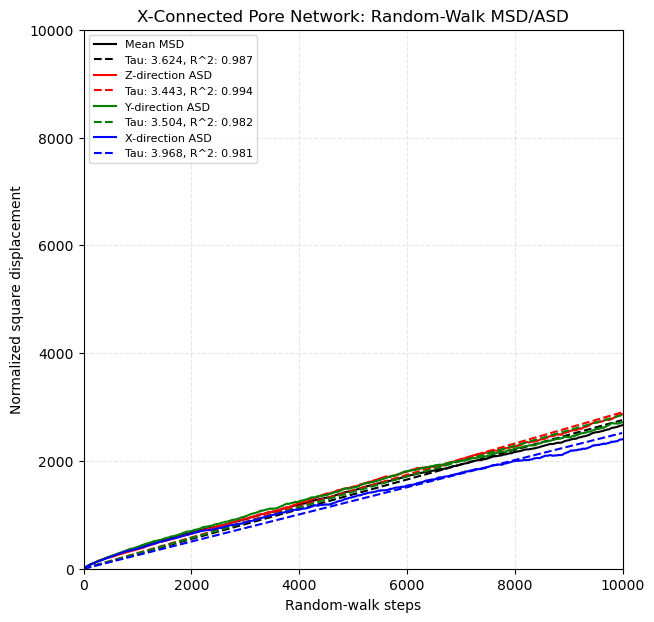



PYTRAX RANDOM-WALK TORTUOSITY RESULTS
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X.tif
Connected direction: X

All calculated axial results
--------------------------------------------------------------------
Z-direction: tau = 3.442701, R² = 0.994260
Y-direction: tau = 3.504070, R² = 0.982163
X-direction: tau = 3.967983, R² = 0.980686  <-- Report this result

Selected result
--------------------------------------------------------------------
X-direction random-walk tortuosity: 3.967983
X-direction fitting R²: 0.980686

Output files
--------------------------------------------------------------------
MSD/ASD figure: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X_pytrax_random_walk_msd.png
Excel results: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X_pytrax_random_walk_analysis.xlsx


In [36]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytrax as pt
import tifffile


# ============================================================
# Random-walk settings
# ============================================================

NUMBER_OF_WALKERS = 5000
NUMBER_OF_STEPS = 10000
STRIDE = 10

# Use one processor first because multiprocessing can be
# unreliable inside Jupyter Notebook on Windows.
NUMBER_OF_PROCESSORS = 1

DIRECTION_TO_AXIS = {
    "X": 2,
    "Y": 1,
    "Z": 0,
}

AXIS_TO_DIRECTION = {
    0: "Z",
    1: "Y",
    2: "X",
}


# ============================================================
# Select the input TIFF file
# ============================================================

def select_tiff_file():
    """
    Open a graphical file-selection window.

    If the graphical window is unavailable, ask the user to enter
    the file path manually in the Jupyter input box.
    """

    selected_file = ""
    root = None

    try:
        from tkinter import Tk, filedialog

        root = Tk()
        root.withdraw()
        root.attributes("-topmost", True)

        selected_file = filedialog.askopenfilename(
            parent=root,
            title="Select a Directionally Connected-Pore TIFF File",
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )

    except Exception as error:
        print(
            "The graphical file-selection window is unavailable."
        )
        print(f"Reason: {error}")

    finally:
        if root is not None:
            try:
                root.destroy()
            except Exception:
                pass

    # Use text input if the graphical window is unavailable
    # or if no file was selected.
    if not selected_file:
        selected_file = input(
            "Enter the path of the connected-pore TIFF file: "
        ).strip().strip('"').strip("'")

    if not selected_file:
        raise ValueError("No input TIFF file was selected.")

    file_path = Path(selected_file).expanduser().resolve()

    if not file_path.exists():
        raise FileNotFoundError(
            f"The selected TIFF file does not exist:\n{file_path}"
        )

    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError(
            "The selected input file must have a "
            ".tif or .tiff extension."
        )

    return file_path


# ============================================================
# Detect the connected direction
# ============================================================

def detect_connected_direction(file_path):
    """
    Detect X, Y, or Z from the connected-pore mask filename.

    Recognized examples:

        sample_connected_X.tif
        sample_connected_Y.tif
        sample_connected_Z.tif
    """

    filename = file_path.stem.upper()

    patterns = [
        r"CONNECTED[_-]?([XYZ])(?:_|-|$)",
        r"DIRECTION[_-]?([XYZ])(?:_|-|$)",
        r"[_-]([XYZ])[_-]?CONNECTED(?:_|-|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, filename)

        if match:
            return match.group(1)

    print(
        "\nThe connected direction could not be detected "
        "from the filename."
    )

    while True:
        direction = input(
            "Enter the connected-pore direction (X, Y, or Z): "
        ).strip().upper()

        if direction in {"X", "Y", "Z"}:
            return direction

        print("Invalid direction. Please enter X, Y, or Z.")


# ============================================================
# Read and convert the binary TIFF
# ============================================================

def read_connected_pore_mask(file_path):
    """
    Read a binary connected-pore TIFF and convert it to the
    pytrax binary convention.

    Original TIFF:

        0   = solid or non-connected space
        255 = connected pore space

    Converted pytrax image:

        0 = solid or inaccessible space
        1 = connected pore space
    """

    original_volume = tifffile.imread(file_path)

    if original_volume.ndim != 3:
        raise ValueError(
            "The input must be a 3D TIFF volume.\n"
            f"Current shape: {original_volume.shape}"
        )

    original_values = np.unique(original_volume)

    print("\nOriginal TIFF information")
    print("-" * 60)
    print(f"Image shape (Z, Y, X): {original_volume.shape}")
    print(f"Data type: {original_volume.dtype}")
    print(f"Unique values: {original_values}")

    # All positive values are treated as connected pore voxels.
    pore_image = (original_volume > 0).astype(np.uint8)

    converted_values = np.unique(pore_image)

    if not np.any(pore_image):
        raise ValueError(
            "The selected connected-pore mask contains no pore voxels."
        )

    total_voxels = pore_image.size
    connected_pore_voxels = np.count_nonzero(pore_image)

    connected_porosity = (
        connected_pore_voxels / total_voxels
    )

    print("\nConverted pytrax image")
    print("-" * 60)
    print(f"Unique values: {converted_values}")
    print(
        f"Connected pore voxels: "
        f"{connected_pore_voxels:,}"
    )
    print(
        f"Connected pore fraction: "
        f"{connected_porosity:.6f}"
    )
    print(
        f"Connected porosity: "
        f"{connected_porosity * 100:.4f}%"
    )

    return (
        original_volume,
        pore_image,
        connected_pore_voxels,
        connected_porosity,
    )


# ============================================================
# Validate simulation settings
# ============================================================

def validate_simulation_settings():
    """Validate the user-defined random-walk parameters."""

    if NUMBER_OF_WALKERS <= 0:
        raise ValueError(
            "NUMBER_OF_WALKERS must be greater than zero."
        )

    if NUMBER_OF_STEPS <= 1:
        raise ValueError(
            "NUMBER_OF_STEPS must be greater than one."
        )

    if STRIDE <= 0:
        raise ValueError(
            "STRIDE must be greater than zero."
        )

    # pytrax allocates an output array using NUMBER_OF_STEPS/STRIDE.
    # Requiring exact divisibility avoids an array-size mismatch.
    if NUMBER_OF_STEPS % STRIDE != 0:
        raise ValueError(
            "NUMBER_OF_STEPS must be exactly divisible by STRIDE.\n"
            f"Current values: {NUMBER_OF_STEPS} / {STRIDE}"
        )

    if NUMBER_OF_PROCESSORS <= 0:
        raise ValueError(
            "NUMBER_OF_PROCESSORS must be greater than zero."
        )


# ============================================================
# Run the pytrax random-walk simulation
# ============================================================

def run_random_walk(pore_image):
    """
    Run the pytrax random-walk simulation and calculate MSD/ASD.
    """

    print("\nStarting pytrax random-walk simulation")
    print("-" * 60)
    print(f"Number of walkers: {NUMBER_OF_WALKERS:,}")
    print(f"Number of steps per walker: {NUMBER_OF_STEPS:,}")
    print(f"Output stride: {STRIDE}")
    print(f"Number of processors: {NUMBER_OF_PROCESSORS}")
    print(
        "\nThis calculation may take several minutes, "
        "depending on the computer."
    )

    random_walk = pt.RandomWalk(
        image=pore_image,
        seed=False,
    )

    random_walk.run(
        nt=NUMBER_OF_STEPS,
        nw=NUMBER_OF_WALKERS,
        same_start=False,
        stride=STRIDE,
        num_proc=NUMBER_OF_PROCESSORS,
    )

    print("\nRandom-walk simulation completed.")

    return random_walk


# ============================================================
# Extract pytrax results
# ============================================================

def extract_results(random_walk, analysis_direction):
    """
    Calculate MSD/ASD and extract directional tortuosity and R².

    Calling plot_msd() calculates the linear regression and stores
    the results in random_walk.data.
    """

    random_walk.plot_msd()

    result_rows = []

    for axis in range(3):
        direction = AXIS_TO_DIRECTION[axis]

        tau = float(
            np.asarray(
                random_walk.data[f"axis_{axis}_tau"]
            ).squeeze()
        )

        r_squared = float(
            np.asarray(
                random_walk.data[f"axis_{axis}_rsq"]
            ).squeeze()
        )

        result_rows.append(
            {
                "Direction": direction,
                "Pytrax axis": axis,
                "Random-walk tortuosity": tau,
                "Fitting R_squared": r_squared,
                "Corresponds to input mask":
                    direction == analysis_direction,
            }
        )

    results_dataframe = pd.DataFrame(result_rows)

    selected_row = results_dataframe.loc[
        results_dataframe["Direction"] == analysis_direction
    ].iloc[0]

    selected_tau = float(
        selected_row["Random-walk tortuosity"]
    )

    selected_r_squared = float(
        selected_row["Fitting R_squared"]
    )

    return (
        results_dataframe,
        selected_tau,
        selected_r_squared,
    )


# ============================================================
# Save the MSD/ASD figure
# ============================================================

def save_msd_figure(
    random_walk,
    input_file_path,
    analysis_direction,
):
    """Format and save the pytrax MSD/ASD figure."""

    figure = plt.gcf()
    axis = plt.gca()

    axis.set_title(
        f"{analysis_direction}-Connected Pore Network: "
        "Random-Walk MSD/ASD"
    )

    axis.set_xlabel("Random-walk steps")
    axis.set_ylabel("Normalized square displacement")
    axis.grid(
        True,
        linestyle="--",
        alpha=0.30,
    )

    # Replace pytrax axis labels with physical directions.
    handles, labels = axis.get_legend_handles_labels()

    new_labels = []

    for label in labels:
        label = label.replace("msd", "Mean MSD")
        label = label.replace("asd 0", "Z-direction ASD")
        label = label.replace("asd 1", "Y-direction ASD")
        label = label.replace("asd 2", "X-direction ASD")
        new_labels.append(label)

    axis.legend(
        handles,
        new_labels,
        loc="upper left",
        fontsize=8,
        frameon=True,
    )

    figure.set_size_inches(8.5, 7.0)

    figure_path = input_file_path.with_name(
        input_file_path.stem
        + "_pytrax_random_walk_msd.png"
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    # Display reliably inside Jupyter Notebook even when Matplotlib is using
    # the non-interactive FigureCanvasAgg backend. The fallback keeps the
    # script usable in a standard Python environment outside IPython.
    try:
        from IPython.display import display

        display(figure)
    except ImportError:
        plt.show()
    finally:
        plt.close(figure)

    return figure_path


# ============================================================
# Create the displacement dataframe
# ============================================================

def create_displacement_dataframe(random_walk):
    """
    Create a dataframe containing the mean and directional
    square-displacement data.
    """

    # The first saved position is treated as step zero by pytrax.
    saved_steps = np.arange(
        0,
        NUMBER_OF_STEPS,
        STRIDE,
    )

    displacement_dataframe = pd.DataFrame(
        {
            "Random-walk step": saved_steps,
            "Mean MSD": random_walk.msd,
            "Z-direction ASD":
                random_walk.axial_msd[:, 0] * 3,
            "Y-direction ASD":
                random_walk.axial_msd[:, 1] * 3,
            "X-direction ASD":
                random_walk.axial_msd[:, 2] * 3,
        }
    )

    return displacement_dataframe


# ============================================================
# Export results to Excel
# ============================================================

def export_results_to_excel(
    input_file_path,
    analysis_direction,
    pore_image,
    connected_pore_voxels,
    connected_porosity,
    results_dataframe,
    displacement_dataframe,
    selected_tau,
    selected_r_squared,
):
    """Export the random-walk settings and results to Excel."""

    excel_path = input_file_path.with_name(
        input_file_path.stem
        + "_pytrax_random_walk_analysis.xlsx"
    )

    summary_dataframe = pd.DataFrame(
        {
            "Parameter": [
                "Input connected-pore TIFF",
                "Image shape Z",
                "Image shape Y",
                "Image shape X",
                "Analysis direction",
                "Relevant pytrax axis",
                "Connected pore voxels",
                "Connected pore fraction",
                "Connected porosity (%)",
                "Number of walkers",
                "Number of steps",
                "Output stride",
                "Number of processors",
                "Selected directional tortuosity",
                "Selected fitting R_squared",
            ],
            "Value": [
                str(input_file_path),
                pore_image.shape[0],
                pore_image.shape[1],
                pore_image.shape[2],
                analysis_direction,
                DIRECTION_TO_AXIS[analysis_direction],
                connected_pore_voxels,
                connected_porosity,
                connected_porosity * 100,
                NUMBER_OF_WALKERS,
                NUMBER_OF_STEPS,
                STRIDE,
                NUMBER_OF_PROCESSORS,
                selected_tau,
                selected_r_squared,
            ],
        }
    )

    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
    ) as writer:

        summary_dataframe.to_excel(
            writer,
            sheet_name="Summary",
            index=False,
        )

        results_dataframe.to_excel(
            writer,
            sheet_name="Directional Tortuosity",
            index=False,
        )

        displacement_dataframe.to_excel(
            writer,
            sheet_name="MSD and ASD",
            index=False,
        )

        notes_dataframe = pd.DataFrame(
            {
                "Notes": [
                    "Input TIFF convention: 0 = solid, "
                    "255 = connected pore.",
                    "Pytrax convention after conversion: "
                    "0 = solid, 1 = accessible pore.",
                    "Only face-connected voxel movement is used.",
                    "Edge and corner movements are excluded.",
                    "TIFF axis order is Z, Y, X.",
                    "Pytrax axis 0 = Z, axis 1 = Y, axis 2 = X.",
                    "Only the result corresponding to the input "
                    "connected-pore direction should be reported.",
                    "Random-walk tortuosity should be compared with "
                    "finite-difference diffusion tortuosity.",
                    "Random-walk tortuosity should not be compared "
                    "directly with the formation factor.",
                ]
            }
        )

        notes_dataframe.to_excel(
            writer,
            sheet_name="Notes",
            index=False,
        )

    return excel_path


# ============================================================
# Print the final results
# ============================================================

def print_results(
    input_file_path,
    analysis_direction,
    results_dataframe,
    selected_tau,
    selected_r_squared,
    figure_path,
    excel_path,
):
    """Print the random-walk analysis results."""

    print("\n")
    print("=" * 68)
    print("PYTRAX RANDOM-WALK TORTUOSITY RESULTS")
    print("=" * 68)

    print(f"Input file: {input_file_path}")
    print(f"Connected direction: {analysis_direction}")

    print("\nAll calculated axial results")
    print("-" * 68)

    for _, row in results_dataframe.iterrows():
        marker = ""

        if row["Direction"] == analysis_direction:
            marker = "  <-- Report this result"

        print(
            f"{row['Direction']}-direction: "
            f"tau = {row['Random-walk tortuosity']:.6f}, "
            f"R² = {row['Fitting R_squared']:.6f}"
            f"{marker}"
        )

    print("\nSelected result")
    print("-" * 68)
    print(
        f"{analysis_direction}-direction random-walk tortuosity: "
        f"{selected_tau:.6f}"
    )
    print(
        f"{analysis_direction}-direction fitting R²: "
        f"{selected_r_squared:.6f}"
    )

    if selected_r_squared < 0.95:
        print(
            "\nWarning: The selected fitting R² is below 0.95."
        )
        print(
            "Consider increasing NUMBER_OF_WALKERS and "
            "NUMBER_OF_STEPS."
        )

    print("\nOutput files")
    print("-" * 68)
    print(f"MSD/ASD figure: {figure_path}")
    print(f"Excel results: {excel_path}")
    print("=" * 68)


# ============================================================
# Main analysis
# ============================================================

def main():
    """Run the complete pytrax random-walk analysis."""

    validate_simulation_settings()

    # Select the directionally connected-pore TIFF.
    input_file_path = select_tiff_file()

    # Detect the relevant connected direction.
    analysis_direction = detect_connected_direction(
        input_file_path
    )

    print("\nSelected random-walk input")
    print("-" * 60)
    print(f"Input file: {input_file_path}")
    print(f"Analysis direction: {analysis_direction}")
    print(
        f"Corresponding pytrax axis: "
        f"{DIRECTION_TO_AXIS[analysis_direction]}"
    )

    (
        original_volume,
        pore_image,
        connected_pore_voxels,
        connected_porosity,
    ) = read_connected_pore_mask(input_file_path)

    del original_volume

    # Run the pytrax simulation.
    random_walk = run_random_walk(pore_image)

    # Extract tortuosity and fitting results.
    (
        results_dataframe,
        selected_tau,
        selected_r_squared,
    ) = extract_results(
        random_walk=random_walk,
        analysis_direction=analysis_direction,
    )

    # Save the MSD/ASD figure.
    figure_path = save_msd_figure(
        random_walk=random_walk,
        input_file_path=input_file_path,
        analysis_direction=analysis_direction,
    )

    # Create the complete displacement dataset.
    displacement_dataframe = (
        create_displacement_dataframe(random_walk)
    )

    # Export the analysis to Excel.
    excel_path = export_results_to_excel(
        input_file_path=input_file_path,
        analysis_direction=analysis_direction,
        pore_image=pore_image,
        connected_pore_voxels=connected_pore_voxels,
        connected_porosity=connected_porosity,
        results_dataframe=results_dataframe,
        displacement_dataframe=displacement_dataframe,
        selected_tau=selected_tau,
        selected_r_squared=selected_r_squared,
    )

    # Print the final results.
    print_results(
        input_file_path=input_file_path,
        analysis_direction=analysis_direction,
        results_dataframe=results_dataframe,
        selected_tau=selected_tau,
        selected_r_squared=selected_r_squared,
        figure_path=figure_path,
        excel_path=excel_path,
    )


if __name__ == "__main__":
    main()

In [37]:
"""
%pip install porespy openpnm tifffile numpy scipy pandas openpyxl matplotlib
"""

'\n%pip install porespy openpnm tifffile numpy scipy pandas openpyxl matplotlib\n'

## 6. Pore-Network Extraction and Directional Intrinsic Permeability Analysis

### Purpose

This module estimates the direction-dependent intrinsic permeability of an
XRµCT-resolved pore structure using image-derived pore-network modelling.

A pore-and-throat network is first extracted from a selected directional
through-connected binary pore mask using the PoreSpy SNOW2 algorithm. The
extracted network is then imported into OpenPNM, where a steady-state,
single-phase Stokes-flow simulation is performed between two opposing boundary
faces.

The calculated volumetric flow rate is converted into directional intrinsic
permeability using Darcy's law.

The analysis is performed independently for the X, Y, and Z directions to
evaluate permeability anisotropy in the resolved pore structure.

---

### Position within the workflow

This module is applied after directional through-connectivity analysis.

The required processing sequence is:

```text
Labelled 3D CT volume
        ↓
User-selected pore label
        ↓
6-connected component analysis
        ↓
Directional through-connected pore mask
        ↓
PoreSpy SNOW2 pore-network extraction
        ↓
Removal of non-spanning network components
        ↓
OpenPNM steady-state Stokes-flow simulation
        ↓
Darcy-law intrinsic permeability calculation
```

Only network components that form a continuous connection between the inlet
and outlet boundaries are retained in the hydraulic simulation.

---

### Required input file

The user selects one directionally through-connected binary TIFF mask using a
graphical file-selection window.

Valid examples are:

```text
sample_through_connected_X.tif
sample_through_connected_Y.tif
sample_through_connected_Z.tif
```

For the synthetic demonstration dataset, the corresponding inputs are:

```text
synthetic_labelled_cement_4phase_100_through_connected_X.tif
synthetic_labelled_cement_4phase_100_through_connected_Y.tif
synthetic_labelled_cement_4phase_100_through_connected_Z.tif
```

The code attempts to detect the permeability direction from the selected
filename. If the direction cannot be detected automatically, the user is asked
to enter X, Y, or Z manually.

The input file must:

- Be a three-dimensional TIFF volume
- Represent a single directional through-connected pore mask
- Contain at least one positive-valued pore voxel
- Touch both opposing image faces in the selected flow direction
- Use the same spatial orientation as the original labelled CT volume
- Have been generated using strict 3D face connectivity

The physical isotropic voxel size must be entered by the user in micrometres.

The X-, Y-, and Z-directional masks are analysed in separate runs.

---

### Input-image convention

The directional connected-pore mask is normally stored using the following
8-bit TIFF convention:

| TIFF value | Meaning |
|---:|---|
| 0 | Solid or pore space that is not through-connected in the selected direction |
| 255 | Directionally through-connected pore space |

Before pore-network extraction, the code converts the image to a 0/1 binary
volume:

```python
pore_volume = (original_volume > 0).astype(np.uint8)
```

The internal convention is:

| Internal value | Meaning |
|---:|---|
| 0 | Solid or inaccessible space |
| 1 | Accessible through-connected pore space |

Consequently, both 0/255 and 0/1 binary input masks can be analysed. Every
positive voxel value is interpreted as pore space.

---

### Coordinate convention

The TIFF volume is loaded into NumPy using the following array order:

```text
Array shape = (Z, Y, X)
```

The relationship between physical directions, NumPy array axes, and OpenPNM
boundary labels is:

| Physical direction | NumPy array axis | OpenPNM coordinate axis | Boundary labels |
|---|---:|---|---|
| X | 2 | z | `zmin`, `zmax` |
| Y | 1 | y | `ymin`, `ymax` |
| Z | 0 | x | `xmin`, `xmax` |

The apparent reversal between physical X/Z and OpenPNM x/z arises because the
input NumPy array is stored in Z, Y, X order. The code applies this mapping
consistently when assigning inlet and outlet boundary conditions.

---

### Directional boundary verification

Before network extraction, the code verifies that the selected pore mask
contains pore voxels on both opposing image faces in the detected flow
direction.

For direction $j$, the mask must satisfy:

$$
N_{j,\mathrm{inlet}} > 0
$$

and:

$$
N_{j,\mathrm{outlet}} > 0
$$

where:

- $N_{j,\mathrm{inlet}}$ is the number of pore voxels on the inlet boundary
- $N_{j,\mathrm{outlet}}$ is the number of pore voxels on the outlet boundary

This check confirms boundary contact but does not by itself prove that the
network remains spanning after pore-network extraction. Network-level
connectivity is checked separately after SNOW2 extraction.

---

### Pore-volume fraction

The pore-volume fraction of the selected directional mask is calculated as:

$$
\phi_{\mathrm{pore}}
=
\frac{N_{\mathrm{pore}}}{N_{\mathrm{total}}}
$$

where:

- $N_{\mathrm{pore}}$ is the number of positive-valued voxels in the selected mask
- $N_{\mathrm{total}}$ is the total number of voxels in the 3D volume

The corresponding percentage is:

$$
\phi_{\mathrm{pore}}(\%)
=
100\phi_{\mathrm{pore}}
$$

For this module, $\phi_{\mathrm{pore}}$ represents the directional
through-connected pore fraction supplied to the pore-network extraction rather
than the total porosity of the original material.

---

### SNOW2 pore-network extraction

The pore network is extracted using:

```python
ps.networks.snow2(
    phases=pore_volume,
    voxel_size=voxel_size_m,
    boundary_width=boundary_width,
    accuracy="standard",
    parallel_kw=None,
)
```

SNOW2 partitions the voxel pore space into individual pore regions and
identifies the throats connecting neighbouring pores.

The extracted network contains geometrical and topological properties including:

- Pore coordinates
- Pore equivalent diameters
- Throat connections
- Throat inscribed diameters
- Throat total lengths
- Boundary-pore labels

The physical voxel size is converted from micrometres to metres before network
extraction:

$$
\Delta x_{\mathrm{m}}
=
\Delta x_{\mathrm{µm}} \times 10^{-6}
$$

This conversion ensures that the extracted pore and throat dimensions are
stored in SI units.

---

### Artificial boundary regions

SNOW2 boundary regions are added only along the selected flow direction.

The default boundary width is:

```text
BOUNDARY_WIDTH = 3 voxels
```

The directional boundary-width settings are:

| Flow direction | SNOW2 boundary width in array order (Z, Y, X) |
|---|---|
| X | `[0, 0, 3]` |
| Y | `[0, 3, 0]` |
| Z | `[3, 0, 0]` |

The boundary regions provide identifiable inlet and outlet network pores for
the OpenPNM boundary conditions.

The effective flow length used in Darcy's law includes these boundary regions:

$$
L_j
=
\left(N_j+2N_{\mathrm{boundary}}\right)\Delta x
$$

where:

- $N_j$ is the original image dimension in flow direction $j$
- $N_{\mathrm{boundary}}$ is the boundary width in voxels
- $\Delta x$ is the physical isotropic voxel size

---

### Retention of spanning network components

The SNOW2 network may contain disconnected components or components connected
to only one external boundary.

The code identifies connected components in the extracted pore-and-throat graph
and retains only components that contain both inlet and outlet network pores.

Conceptually, a retained component $c$ must satisfy:

$$
c \cap P_{\mathrm{inlet}} \neq \varnothing
$$

and:

$$
c \cap P_{\mathrm{outlet}} \neq \varnothing
$$

where $P_{\mathrm{inlet}}$ and $P_{\mathrm{outlet}}$ are the inlet and outlet
pore sets.

Multiple independent spanning components are retained because they represent
parallel hydraulic flow pathways.

Components that do not connect the inlet and outlet are removed before the
Stokes-flow simulation.

---

### Pore and throat geometry

The hydraulic model uses the following SNOW2-derived properties:

```text
pore.diameter    = pore.equivalent_diameter
throat.diameter  = throat.inscribed_diameter
throat.spacing   = throat.total_length
```

Hydraulic size factors are calculated using the OpenPNM
`pyramids_and_cuboids` geometry model.

The code verifies that:

- Pore diameters are positive
- Throat diameters are positive
- Throat spacing values are positive
- Hydraulic size factors contain no `NaN` or infinite values

The median pore diameter and median throat diameter are printed in
micrometres as network-quality diagnostics.

---

### Hydraulic-conductance model

A generic OpenPNM hydraulic-conductance model is assigned to every retained
network throat:

```python
op.models.physics.hydraulic_conductance.generic_hydraulic
```

Hydraulic conductance represents the relationship between the pressure
difference across a throat and its volumetric flow rate.

Only the hydraulic-conductance model required for single-phase Stokes flow is
used. The calculation does not require:

- Surface tension
- Contact angle
- Capillary entry pressure
- Molecular diffusivity
- Diffusive conductance

These properties are relevant to other transport processes but are not required
for the present intrinsic single-phase permeability calculation.

---

### Fluid properties and pressure boundary conditions

The simulation uses the following values:

| Parameter | Symbol | Value |
|---|---|---:|
| Inlet pressure | $P_{\mathrm{in}}$ | 1 Pa |
| Outlet pressure | $P_{\mathrm{out}}$ | 0 Pa |
| Pressure difference | $\Delta P$ | 1 Pa |
| Dynamic viscosity | $\mu$ | 1 Pa·s |

The pressure difference is:

$$
\Delta P
=
P_{\mathrm{in}}-P_{\mathrm{out}}
$$

The use of $\mu=1\ \mathrm{Pa\,s}$ is a convenient normalized choice.
Intrinsic permeability is independent of the chosen viscosity when hydraulic
conductance and Darcy's law are applied consistently.

---

### Steady-state Stokes-flow simulation

The pore-pressure field is obtained by solving the steady-state network flow
equations with OpenPNM `StokesFlow`.

The linear system is solved using the PyAMG Ruge-Stuben solver with:

| Solver parameter | Value |
|---|---:|
| Tolerance | $1 \times 10^{-10}$ |
| Maximum iterations | 5000 |

The solver returns the pressure at every retained network pore and the total
flow rates through the inlet and outlet pore sets.

---

### Flow rate and mass-balance check

The inlet and outlet flow-rate magnitudes are calculated independently.

The flow rate used for Darcy's law is their average:

$$
Q
=
\frac{|Q_{\mathrm{in}}|+|Q_{\mathrm{out}}|}{2}
$$

The relative mass-balance error is calculated as:

$$
E_{\mathrm{balance}}
=
\frac{
\left||Q_{\mathrm{in}}|-|Q_{\mathrm{out}}|\right|
}
{
\max\left(|Q_{\mathrm{in}}|,|Q_{\mathrm{out}}|\right)
}
$$

The code reports a warning when:

$$
E_{\mathrm{balance}} > 1 \times 10^{-3}
$$

which corresponds to a relative inlet/outlet mismatch greater than 0.1%.

A small mass-balance error supports numerical conservation of flow through the
network.

---

### Cross-sectional area

For flow in direction $j$, the macroscopic cross-sectional area is calculated
from the two perpendicular image dimensions:

$$
A_j
=
N_aN_b\Delta x^2
$$

where:

- $N_a$ and $N_b$ are the voxel dimensions perpendicular to the flow direction
- $\Delta x$ is the isotropic voxel size in metres

The area represents the complete macroscopic image cross-section, including
both pore and solid voxels.

---

### Intrinsic permeability calculation

Directional intrinsic permeability is calculated using Darcy's law:

$$
k_j
=
\frac{Q_j\mu L_j}{A_j\Delta P}
$$

where:

- $k_j$ is the intrinsic permeability in direction $j$ in $\mathrm{m^2}$
- $Q_j$ is the simulated volumetric flow rate in $\mathrm{m^3\,s^{-1}}$
- $\mu$ is the dynamic viscosity in $\mathrm{Pa\,s}$
- $L_j$ is the flow length in metres
- $A_j$ is the macroscopic cross-sectional area in $\mathrm{m^2}$
- $\Delta P$ is the applied pressure difference in pascals

Intrinsic permeability characterises the hydraulic transport capacity of the
resolved pore structure independently of the identity of a particular
Newtonian fluid.

---

### Permeability unit conversion

Permeability is reported in square metres, Darcy, and millidarcy.

The conversion used by the code is:

$$
1\ \mathrm{Darcy}
=
9.869233 \times 10^{-13}\ \mathrm{m^2}
$$

Therefore:

$$
k_{\mathrm{Darcy}}
=
\frac{k_{\mathrm{m^2}}}
{9.869233 \times 10^{-13}}
$$

and:

$$
k_{\mathrm{mD}}
=
1000k_{\mathrm{Darcy}}
$$

For dense cementitious materials, the values in $\mathrm{m^2}$ may be extremely
small. Scientific notation should therefore be retained when reporting the
results.

---

### Directional reporting procedure

Each directional mask is analysed in a separate run:

| Selected input mask | Reported permeability |
|---|---|
| `sample_through_connected_X.tif` | $k_X$ |
| `sample_through_connected_Y.tif` | $k_Y$ |
| `sample_through_connected_Z.tif` | $k_Z$ |

The three results may be compared to assess hydraulic anisotropy in the
XRµCT-resolved pore network.

---

### Pressure-distribution figure

The pore-network pressure distribution is exported as:

```text
sample_through_connected_X_permeability_pressure_distribution.png
```

The figure plots:

- Network-pore position along the selected flow direction
- Simulated pore pressure in pascals
- Pressure represented by both vertical position and colour

The pressure distribution provides a diagnostic view of the simulated pressure
gradient and may reveal large pressure drops associated with restrictive pore
throats.

---

### Excel output

The numerical results are exported as:

```text
sample_through_connected_X_permeability_analysis.xlsx
```

The workbook contains the following worksheets:

1. `Summary`
2. `Pore Pressure`
3. `Network Throats`
4. `Notes`

The workbook includes:

- Input filename
- Permeability direction
- Voxel size and image dimensions
- Directional pore-volume fraction
- Number of network pores and throats
- Number of initial and retained spanning components
- Inlet and outlet pressures
- Inlet and outlet flow rates
- Relative mass-balance error
- Flow length
- Cross-sectional area
- Dynamic viscosity
- Intrinsic permeability in $\mathrm{m^2}$, Darcy, and mD
- Network-pore coordinates and pressures
- Throat connections, diameters, and spacing

---

### Analysis outputs

For each directional run, the module reports:

- Directional intrinsic permeability in $\mathrm{m^2}$
- Directional intrinsic permeability in Darcy
- Directional intrinsic permeability in mD
- Volumetric flow rate in $\mathrm{m^3\,s^{-1}}$
- Inlet and outlet flow rates
- Relative mass-balance error
- Directional pore-volume fraction
- Number of extracted network pores
- Number of extracted network throats
- Number of inlet-to-outlet spanning components
- Median pore diameter
- Median throat diameter
- Network-pore pressure distribution
- Excel workbook containing the numerical results
- PNG pressure-distribution figure

---

### Scientific interpretation

Directional permeability describes the ease with which a pressure-driven fluid
can pass through the resolved connected pore network.

- Higher permeability indicates more hydraulically conductive pathways
- Lower permeability indicates stronger restriction by pore and throat geometry
- Similar $k_X$, $k_Y$, and $k_Z$ values suggest approximately isotropic flow
- Large directional differences indicate permeability anisotropy
- Narrow throats may strongly reduce permeability even when connected porosity is relatively high
- Multiple spanning components contribute as parallel flow pathways

Permeability is controlled not only by total or connected porosity but also by
pore-throat dimensions, constrictions, coordination, connectivity, and pathway
topology.

---

### Difference from direct voxel-based CFD

This module performs image-derived pore-network modelling rather than direct
voxel-based computational fluid dynamics.

| Pore-network modelling | Direct voxel-based CFD |
|---|---|
| Replaces pore space with pores and throats | Solves flow directly on the voxel geometry |
| Lower computational cost | Higher computational cost |
| Depends on network extraction and shape-factor assumptions | Retains more direct geometrical detail |
| Suitable for workflow development and larger volumes | Often limited by memory and computational requirements |

The calculated permeability should therefore be reported as an SNOW2/OpenPNM
pore-network estimate and not as an exact replacement for direct CFD results
from software such as Avizo XLab.

---

### Methodological limitations

The calculated permeability depends on:

- CT spatial resolution
- Image reconstruction quality
- Segmentation accuracy
- Selected pore label
- Directional connectivity extraction
- Physical voxel-size accuracy
- Analysed volume and representative elementary volume
- Boundary truncation of the pore network
- SNOW2 pore partitioning
- Artificial boundary width
- Pore and throat diameter definitions
- Throat-length definition
- Hydraulic shape-factor model
- Hydraulic-conductance model
- Treatment of disconnected network components

Sub-resolution gel pores and throats are not represented explicitly. This can
substantially affect permeability estimates for cementitious materials because
the narrowest unresolved constrictions may dominate hydraulic resistance.

The analysis assumes:

- Steady-state flow
- Single-phase flow
- An incompressible Newtonian fluid
- No-slip behaviour represented through the conductance model
- No chemical interaction between the fluid and solid
- No pore deformation
- No capillary or multiphase effects

Consequently, the results should be described as directional intrinsic
permeability estimates of the XRµCT-resolved through-connected pore network
obtained using SNOW2 and OpenPNM.

Enter the isotropic voxel size in micrometres (um):  0.7



Permeability analysis input
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X.tif
Flow direction: X
Voxel size: 0.700000 µm
TIFF array axis: 2
OpenPNM axis label: z

Input binary volume
--------------------------------------------------------------------
Shape (Z, Y, X): (100, 100, 100)
Original data type: uint8
Original values: [  0 255]
Converted values: [0 1]
Total voxels: 1,000,000
Pore voxels: 88,757
Pore volume fraction: 0.08875700
Pore volume percentage: 8.875700%

Directional boundary contact
--------------------------------------------------------------------
Direction: X
Inlet boundary pore voxels: 290
Outlet boundary pore voxels: 992

Pore-network extraction
--------------------------------------------------------------------
Extracting the pore network using PoreSpy SNOW2...
Boundary width: [0, 0, 3]
This step may take several minutes.

Extracted network
-----------------------------------------------------------------

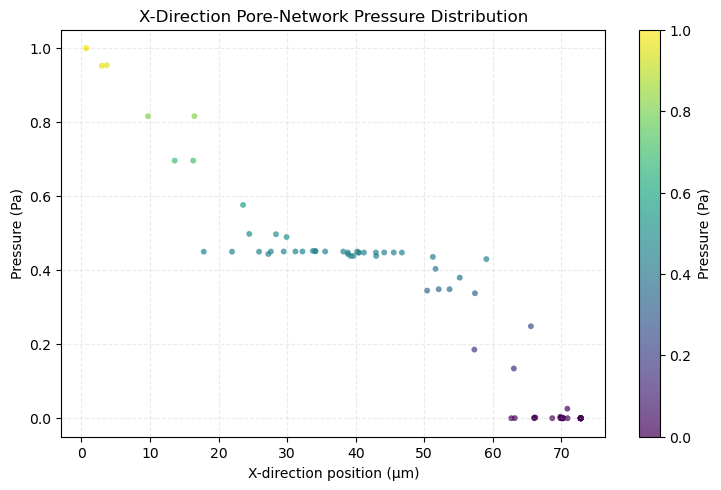



DIRECTIONAL INTRINSIC PERMEABILITY RESULTS
Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X.tif
Direction: X
Inlet flow rate: 3.860260e-18 m³/s
Outlet flow rate: 3.860260e-18 m³/s
Relative mass-balance error: 1.910001e-10

Permeability
------------------------------------------------------------------------
Intrinsic permeability: 5.845537e-14 m²
Intrinsic permeability: 5.922990e-02 Darcy
Intrinsic permeability: 5.922990e+01 mD

Output files
------------------------------------------------------------------------
Pressure-distribution figure: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X_permeability_pressure_distribution.png
Excel results: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_through_connected_X_permeability_analysis.xlsx


In [40]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import openpnm as op
import pandas as pd
import porespy as ps
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
import tifffile


# ============================================================
# Simulation settings
# ============================================================

BOUNDARY_WIDTH = 3

INLET_PRESSURE_PA = 1.0
OUTLET_PRESSURE_PA = 0.0

# Intrinsic permeability is independent of viscosity when
# Darcy's law is applied consistently.
DYNAMIC_VISCOSITY_PA_S = 1.0

SOLVER_TOLERANCE = 1.0e-10
SOLVER_MAX_ITERATIONS = 5000

DARCY_IN_SQUARE_METRES = 9.869233e-13

DIRECTION_CONFIG = {
    "X": {
        "array_axis": 2,
        "openpnm_axis": "z",
        "boundary_width": [0, 0, BOUNDARY_WIDTH],
    },
    "Y": {
        "array_axis": 1,
        "openpnm_axis": "y",
        "boundary_width": [0, BOUNDARY_WIDTH, 0],
    },
    "Z": {
        "array_axis": 0,
        "openpnm_axis": "x",
        "boundary_width": [BOUNDARY_WIDTH, 0, 0],
    },
}


# ============================================================
# Select the input TIFF
# ============================================================

def select_tiff_file():
    """
    Open a file-selection window for the connected-pore TIFF.

    If the graphical window is unavailable, ask the user to enter
    the file path manually.
    """

    selected_file = ""
    root = None

    try:
        from tkinter import Tk, filedialog

        root = Tk()
        root.withdraw()
        root.attributes("-topmost", True)

        selected_file = filedialog.askopenfilename(
            parent=root,
            title="Select a Connected-Pore TIFF File",
            filetypes=[
                ("TIFF files", "*.tif *.tiff"),
                ("All files", "*.*"),
            ],
        )

    except Exception as error:
        print(
            "The graphical file-selection window is unavailable."
        )
        print(f"Reason: {error}")

    finally:
        if root is not None:
            try:
                root.destroy()
            except Exception:
                pass

    if not selected_file:
        selected_file = input(
            "Enter the path of the connected-pore TIFF file: "
        ).strip().strip('"').strip("'")

    if not selected_file:
        raise ValueError("No input TIFF file was selected.")

    file_path = Path(selected_file).expanduser().resolve()

    if not file_path.exists():
        raise FileNotFoundError(
            f"The selected TIFF file does not exist:\n"
            f"{file_path}"
        )

    if file_path.suffix.lower() not in {".tif", ".tiff"}:
        raise ValueError(
            "The selected input file must have a "
            ".tif or .tiff extension."
        )

    return file_path


# ============================================================
# Detect permeability direction
# ============================================================

def detect_direction(file_path):
    """
    Detect X, Y, or Z from the connected-pore filename.

    Recognized examples:

        sample_connected_X.tif
        sample_connected_Y.tif
        sample_connected_Z.tif
    """

    filename = file_path.stem.upper()

    patterns = [
        r"CONNECTED[_-]?([XYZ])(?:_|-|$)",
        r"DIRECTION[_-]?([XYZ])(?:_|-|$)",
        r"[_-]([XYZ])[_-]?CONNECTED(?:_|-|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, filename)

        if match:
            return match.group(1)

    print(
        "\nThe permeability direction could not be detected "
        "from the filename."
    )

    while True:
        direction = input(
            "Enter the permeability direction (X, Y, or Z): "
        ).strip().upper()

        if direction in {"X", "Y", "Z"}:
            return direction

        print("Invalid direction. Please enter X, Y, or Z.")


# ============================================================
# Get physical voxel size
# ============================================================

def get_voxel_size():
    """Ask the user for the isotropic physical voxel size."""

    while True:
        user_input = input(
            "Enter the isotropic voxel size in micrometres (um): "
        ).strip()

        try:
            voxel_size_um = float(user_input)

            if voxel_size_um <= 0:
                raise ValueError

            return voxel_size_um

        except ValueError:
            print(
                "Invalid voxel size. Enter a positive numerical value."
            )


# ============================================================
# Read and convert the binary TIFF
# ============================================================

def read_binary_volume(file_path):
    """
    Read a binary TIFF and convert all positive voxels to pore value 1.
    """

    original_volume = tifffile.imread(file_path)

    if original_volume.ndim != 3:
        raise ValueError(
            "The input must be a 3D TIFF volume.\n"
            f"Current shape: {original_volume.shape}"
        )

    original_values = np.unique(original_volume)

    # Convert 0/255 or any other positive-pore convention to 0/1.
    pore_volume = (original_volume > 0).astype(np.uint8)

    if not np.any(pore_volume):
        raise ValueError(
            "The selected TIFF volume contains no pore voxels."
        )

    pore_voxels = int(np.count_nonzero(pore_volume))
    total_voxels = int(pore_volume.size)
    pore_fraction = pore_voxels / total_voxels

    print("\nInput binary volume")
    print("-" * 68)
    print(f"Shape (Z, Y, X): {pore_volume.shape}")
    print(f"Original data type: {original_volume.dtype}")
    print(f"Original values: {original_values}")
    print(f"Converted values: {np.unique(pore_volume)}")
    print(f"Total voxels: {total_voxels:,}")
    print(f"Pore voxels: {pore_voxels:,}")
    print(f"Pore volume fraction: {pore_fraction:.8f}")
    print(f"Pore volume percentage: {pore_fraction * 100:.6f}%")

    return pore_volume


# ============================================================
# Verify directional boundary contact
# ============================================================

def verify_boundary_contact(pore_volume, direction):
    """
    Verify that pore voxels touch both opposing boundary faces.
    """

    array_axis = DIRECTION_CONFIG[direction]["array_axis"]

    inlet_slice = np.take(
        pore_volume,
        indices=0,
        axis=array_axis,
    )

    outlet_slice = np.take(
        pore_volume,
        indices=-1,
        axis=array_axis,
    )

    inlet_voxels = int(np.count_nonzero(inlet_slice))
    outlet_voxels = int(np.count_nonzero(outlet_slice))

    print("\nDirectional boundary contact")
    print("-" * 68)
    print(f"Direction: {direction}")
    print(f"Inlet boundary pore voxels: {inlet_voxels:,}")
    print(f"Outlet boundary pore voxels: {outlet_voxels:,}")

    if inlet_voxels == 0:
        raise ValueError(
            f"The selected mask does not touch the "
            f"{direction}-direction inlet face."
        )

    if outlet_voxels == 0:
        raise ValueError(
            f"The selected mask does not touch the "
            f"{direction}-direction outlet face."
        )


# ============================================================
# Extract the pore network
# ============================================================

def extract_pore_network(
    pore_volume,
    voxel_size_m,
    direction,
):
    """
    Extract a pore network from the binary volume using SNOW2.
    """

    boundary_width = (
        DIRECTION_CONFIG[direction]["boundary_width"]
    )

    print("\nPore-network extraction")
    print("-" * 68)
    print("Extracting the pore network using PoreSpy SNOW2...")
    print(f"Boundary width: {boundary_width}")
    print("This step may take several minutes.")

    snow_result = ps.networks.snow2(
        phases=pore_volume,
        voxel_size=voxel_size_m,
        boundary_width=boundary_width,
        accuracy="standard",
        parallel_kw=None,
    )

    network = op.io.network_from_porespy(
        snow_result.network
    )

    print("\nExtracted network")
    print("-" * 68)
    print(f"Initial network pores: {network.Np:,}")
    print(f"Initial network throats: {network.Nt:,}")

    if network.Np == 0:
        raise RuntimeError(
            "SNOW2 did not extract any network pores."
        )

    if network.Nt == 0:
        raise RuntimeError(
            "SNOW2 did not extract any network throats."
        )

    return snow_result, network


# ============================================================
# Retain all inlet-to-outlet spanning components
# ============================================================

def retain_spanning_network_components(
    network,
    direction,
):
    """
    Retain all network components that connect the inlet and outlet.

    Multiple independent spanning components are retained because
    they represent parallel flow pathways.
    """

    openpnm_axis = (
        DIRECTION_CONFIG[direction]["openpnm_axis"]
    )

    inlet_label = f"{openpnm_axis}min"
    outlet_label = f"{openpnm_axis}max"

    inlet_pores = network.pores(inlet_label)
    outlet_pores = network.pores(outlet_label)

    if inlet_pores.size == 0:
        raise ValueError(
            f"No inlet pores were identified using "
            f"OpenPNM label '{inlet_label}'."
        )

    if outlet_pores.size == 0:
        raise ValueError(
            f"No outlet pores were identified using "
            f"OpenPNM label '{outlet_label}'."
        )

    connections = np.asarray(
        network["throat.conns"],
        dtype=int,
    )

    rows = np.hstack(
        [
            connections[:, 0],
            connections[:, 1],
        ]
    )

    columns = np.hstack(
        [
            connections[:, 1],
            connections[:, 0],
        ]
    )

    adjacency = coo_matrix(
        (
            np.ones(rows.size, dtype=np.uint8),
            (rows, columns),
        ),
        shape=(network.Np, network.Np),
    ).tocsr()

    number_of_components, component_labels = (
        connected_components(
            adjacency,
            directed=False,
        )
    )

    inlet_components = np.unique(
        component_labels[inlet_pores]
    )

    outlet_components = np.unique(
        component_labels[outlet_pores]
    )

    spanning_components = np.intersect1d(
        inlet_components,
        outlet_components,
    )

    if spanning_components.size == 0:
        raise ValueError(
            "The extracted network contains no component "
            "connecting the inlet and outlet."
        )

    pores_to_keep = np.isin(
        component_labels,
        spanning_components,
    )

    pores_to_remove = np.where(~pores_to_keep)[0]

    initial_pore_count = network.Np
    initial_throat_count = network.Nt

    if pores_to_remove.size > 0:
        op.topotools.trim(
            network=network,
            pores=pores_to_remove,
        )

    # Re-identify boundary pores after trimming.
    inlet_pores = network.pores(inlet_label)
    outlet_pores = network.pores(outlet_label)

    print("\nDirectionally spanning network")
    print("-" * 68)
    print(
        f"Initial connected components: "
        f"{number_of_components}"
    )
    print(
        f"Spanning components retained: "
        f"{spanning_components.size}"
    )
    print(
        f"Removed non-spanning pores: "
        f"{initial_pore_count - network.Np:,}"
    )
    print(
        f"Removed associated throats: "
        f"{initial_throat_count - network.Nt:,}"
    )
    print(f"Remaining pores: {network.Np:,}")
    print(f"Remaining throats: {network.Nt:,}")
    print(f"Inlet network pores: {inlet_pores.size:,}")
    print(f"Outlet network pores: {outlet_pores.size:,}")

    if inlet_pores.size == 0 or outlet_pores.size == 0:
        raise RuntimeError(
            "Boundary pores were lost after network trimming."
        )

    return (
        inlet_pores,
        outlet_pores,
        inlet_label,
        outlet_label,
        int(number_of_components),
        int(spanning_components.size),
    )


# ============================================================
# Prepare geometrical and hydraulic models
# ============================================================

def prepare_hydraulic_models(network):
    """
    Add pore and throat geometry required by hydraulic conductance.
    """

    required_properties = [
        "pore.equivalent_diameter",
        "throat.inscribed_diameter",
        "throat.total_length",
    ]

    for property_name in required_properties:
        if property_name not in network:
            raise KeyError(
                f"Required network property is missing: "
                f"{property_name}"
            )

    network["pore.diameter"] = np.asarray(
        network["pore.equivalent_diameter"]
    )

    network["throat.diameter"] = np.asarray(
        network["throat.inscribed_diameter"]
    )

    network["throat.spacing"] = np.asarray(
        network["throat.total_length"]
    )

    if np.any(network["pore.diameter"] <= 0):
        raise ValueError(
            "The network contains zero or negative pore diameters."
        )

    if np.any(network["throat.diameter"] <= 0):
        raise ValueError(
            "The network contains zero or negative throat diameters."
        )

    if np.any(network["throat.spacing"] <= 0):
        raise ValueError(
            "The network contains zero or negative throat spacing."
        )

    network.add_model(
        propname="throat.hydraulic_size_factors",
        model=(
            op.models.geometry.hydraulic_size_factors
            .pyramids_and_cuboids
        ),
    )

    network.regenerate_models()

    hydraulic_size_factors = np.asarray(
        network["throat.hydraulic_size_factors"]
    )

    if not np.all(np.isfinite(hydraulic_size_factors)):
        raise ValueError(
            "The calculated hydraulic size factors contain "
            "NaN or infinite values."
        )

    print("\nNetwork geometry")
    print("-" * 68)
    print(
        f"Median pore diameter: "
        f"{np.median(network['pore.diameter']) * 1e6:.6f} µm"
    )
    print(
        f"Median throat diameter: "
        f"{np.median(network['throat.diameter']) * 1e6:.6f} µm"
    )


# ============================================================
# Run the Stokes-flow simulation
# ============================================================

def run_stokes_flow(
    network,
    inlet_pores,
    outlet_pores,
):
    """
    Run a steady-state single-phase Stokes-flow simulation.

    Only the hydraulic-conductance model required by StokesFlow is
    added. Capillary-pressure and diffusive-conductance models are
    not required for intrinsic permeability calculations.
    """

    fluid = op.phase.Phase(network=network)

    fluid["pore.viscosity"] = DYNAMIC_VISCOSITY_PA_S

    # Add only the model required by StokesFlow.
    fluid.add_model(
        propname="throat.hydraulic_conductance",
        model=(
            op.models.physics.hydraulic_conductance
            .generic_hydraulic
        ),
    )

    fluid.regenerate_models()

    if "throat.hydraulic_conductance" not in fluid:
        raise RuntimeError(
            "The hydraulic-conductance model was not generated."
        )

    hydraulic_conductance = np.asarray(
        fluid["throat.hydraulic_conductance"]
    )

    if not np.all(np.isfinite(hydraulic_conductance)):
        raise ValueError(
            "The calculated hydraulic conductance contains "
            "NaN or infinite values."
        )

    if np.any(hydraulic_conductance <= 0):
        raise ValueError(
            "The calculated hydraulic conductance contains "
            "zero or negative values."
        )

    print("\nHydraulic model")
    print("-" * 68)
    print(
        f"Minimum hydraulic conductance: "
        f"{np.min(hydraulic_conductance):.6e}"
    )
    print(
        f"Median hydraulic conductance: "
        f"{np.median(hydraulic_conductance):.6e}"
    )
    print(
        f"Maximum hydraulic conductance: "
        f"{np.max(hydraulic_conductance):.6e}"
    )

    stokes_flow = op.algorithms.StokesFlow(
        network=network,
        phase=fluid,
    )

    stokes_flow.set_value_BC(
        pores=inlet_pores,
        values=INLET_PRESSURE_PA,
    )

    stokes_flow.set_value_BC(
        pores=outlet_pores,
        values=OUTLET_PRESSURE_PA,
    )

    solver = op.solvers.PyamgRugeStubenSolver(
        tol=SOLVER_TOLERANCE,
        maxiter=SOLVER_MAX_ITERATIONS,
    )

    print("\nSolving the steady Stokes-flow equation...")

    stokes_flow.run(solver=solver)

    # Transfer calculated pore pressure to the phase.
    fluid.update(stokes_flow.soln)

    pressure = np.asarray(
        fluid["pore.pressure"]
    )

    if not np.all(np.isfinite(pressure)):
        raise RuntimeError(
            "The Stokes-flow pressure solution contains "
            "NaN or infinite values."
        )

    inlet_flow_rate = abs(
        float(
            np.asarray(
                stokes_flow.rate(pores=inlet_pores)
            ).squeeze()
        )
    )

    outlet_flow_rate = abs(
        float(
            np.asarray(
                stokes_flow.rate(pores=outlet_pores)
            ).squeeze()
        )
    )

    if inlet_flow_rate <= 0:
        raise RuntimeError(
            "The calculated inlet flow rate is zero."
        )

    if outlet_flow_rate <= 0:
        raise RuntimeError(
            "The calculated outlet flow rate is zero."
        )

    flow_rate_difference = abs(
        inlet_flow_rate - outlet_flow_rate
    )

    relative_mass_balance_error = (
        flow_rate_difference
        / max(inlet_flow_rate, outlet_flow_rate)
    )

    # Average inlet and outlet magnitudes.
    flow_rate = 0.5 * (
        inlet_flow_rate + outlet_flow_rate
    )

    print("\nStokes-flow solution")
    print("-" * 68)
    print(
        f"Inlet flow rate: "
        f"{inlet_flow_rate:.6e} m³/s"
    )
    print(
        f"Outlet flow rate: "
        f"{outlet_flow_rate:.6e} m³/s"
    )
    print(
        f"Average flow rate: "
        f"{flow_rate:.6e} m³/s"
    )
    print(
        f"Relative mass-balance error: "
        f"{relative_mass_balance_error:.6e}"
    )

    if relative_mass_balance_error > 1.0e-3:
        print(
            "Warning: The relative mass-balance error is "
            "greater than 0.1%."
        )

    return (
        fluid,
        stokes_flow,
        pressure,
        flow_rate,
        inlet_flow_rate,
        outlet_flow_rate,
        relative_mass_balance_error,
    )


# ============================================================
# Calculate intrinsic permeability
# ============================================================

def calculate_permeability(
    pore_volume,
    voxel_size_m,
    direction,
    flow_rate,
):
    """
    Calculate intrinsic permeability using Darcy's law.

        k = Q * mu * L / (A * delta_P)
    """

    array_axis = (
        DIRECTION_CONFIG[direction]["array_axis"]
    )

    flow_length_voxels = (
        pore_volume.shape[array_axis]
        + 2 * BOUNDARY_WIDTH
    )

    flow_length_m = (
        flow_length_voxels * voxel_size_m
    )

    perpendicular_axes = [
        axis
        for axis in range(3)
        if axis != array_axis
    ]

    cross_sectional_area_m2 = (
        pore_volume.shape[perpendicular_axes[0]]
        * pore_volume.shape[perpendicular_axes[1]]
        * voxel_size_m**2
    )

    pressure_difference_pa = (
        INLET_PRESSURE_PA - OUTLET_PRESSURE_PA
    )

    if pressure_difference_pa <= 0:
        raise ValueError(
            "The inlet pressure must be greater than "
            "the outlet pressure."
        )

    permeability_m2 = (
        flow_rate
        * DYNAMIC_VISCOSITY_PA_S
        * flow_length_m
        / (
            cross_sectional_area_m2
            * pressure_difference_pa
        )
    )

    permeability_darcy = (
        permeability_m2
        / DARCY_IN_SQUARE_METRES
    )

    permeability_millidarcy = (
        permeability_darcy * 1000
    )

    return {
        "Flow length (m)": flow_length_m,
        "Cross-sectional area (m2)":
            cross_sectional_area_m2,
        "Pressure difference (Pa)":
            pressure_difference_pa,
        "Dynamic viscosity (Pa.s)":
            DYNAMIC_VISCOSITY_PA_S,
        "Volumetric flow rate (m3/s)":
            flow_rate,
        "Permeability (m2)":
            permeability_m2,
        "Permeability (Darcy)":
            permeability_darcy,
        "Permeability (mD)":
            permeability_millidarcy,
    }


# ============================================================
# Plot the pressure distribution
# ============================================================

def plot_pressure_distribution(
    network,
    pressure,
    direction,
    input_file_path,
):
    """
    Plot network-pore pressure against flow-direction position.
    """

    coordinate_axis = (
        DIRECTION_CONFIG[direction]["array_axis"]
    )

    coordinates_um = (
        network["pore.coords"][:, coordinate_axis]
        * 1e6
    )

    figure, axis = plt.subplots(
        figsize=(8.5, 5.5)
    )

    scatter = axis.scatter(
        coordinates_um,
        pressure,
        c=pressure,
        cmap="viridis",
        s=18,
        alpha=0.70,
        edgecolors="none",
    )

    colour_bar = figure.colorbar(
        scatter,
        ax=axis,
    )

    colour_bar.set_label("Pressure (Pa)")

    axis.set_title(
        f"{direction}-Direction Pore-Network "
        "Pressure Distribution"
    )

    axis.set_xlabel(
        f"{direction}-direction position (µm)"
    )

    axis.set_ylabel("Pressure (Pa)")

    axis.grid(
        True,
        linestyle="--",
        alpha=0.25,
    )

    figure.subplots_adjust(
        left=0.11,
        right=0.91,
        bottom=0.14,
        top=0.88,
    )

    figure_path = input_file_path.with_name(
        input_file_path.stem
        + "_permeability_pressure_distribution.png"
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    # Display reliably inside Jupyter Notebook even when Matplotlib is using
    # the non-interactive FigureCanvasAgg backend. The fallback keeps the
    # script usable in a standard Python environment outside IPython.
    try:
        from IPython.display import display

        display(figure)
    except ImportError:
        plt.show()
    finally:
        plt.close(figure)

    return figure_path


# ============================================================
# Export results to Excel
# ============================================================

def export_results_to_excel(
    input_file_path,
    voxel_size_um,
    direction,
    pore_volume,
    network,
    pressure,
    permeability_results,
    inlet_flow_rate,
    outlet_flow_rate,
    relative_mass_balance_error,
    total_components,
    spanning_components,
):
    """
    Export permeability results and pore pressures to Excel.
    """

    excel_path = input_file_path.with_name(
        input_file_path.stem
        + "_permeability_analysis.xlsx"
    )

    summary_rows = [
        ("Input TIFF", str(input_file_path)),
        ("Simulation method", "SNOW2 + OpenPNM StokesFlow"),
        ("Permeability direction", direction),
        (
            "OpenPNM axis label",
            DIRECTION_CONFIG[direction]["openpnm_axis"],
        ),
        (
            "TIFF array axis",
            DIRECTION_CONFIG[direction]["array_axis"],
        ),
        ("Voxel size (um)", voxel_size_um),
        ("Image shape Z", pore_volume.shape[0]),
        ("Image shape Y", pore_volume.shape[1]),
        ("Image shape X", pore_volume.shape[2]),
        (
            "Pore volume fraction",
            float(np.mean(pore_volume)),
        ),
        (
            "Pore volume percentage",
            float(np.mean(pore_volume) * 100),
        ),
        ("Number of network pores", network.Np),
        ("Number of network throats", network.Nt),
        (
            "Initial connected components",
            total_components,
        ),
        (
            "Spanning components retained",
            spanning_components,
        ),
        ("Inlet pressure (Pa)", INLET_PRESSURE_PA),
        ("Outlet pressure (Pa)", OUTLET_PRESSURE_PA),
        (
            "Inlet flow rate (m3/s)",
            inlet_flow_rate,
        ),
        (
            "Outlet flow rate (m3/s)",
            outlet_flow_rate,
        ),
        (
            "Relative mass-balance error",
            relative_mass_balance_error,
        ),
    ]

    for parameter, value in permeability_results.items():
        summary_rows.append(
            (parameter, value)
        )

    summary_dataframe = pd.DataFrame(
        summary_rows,
        columns=[
            "Parameter",
            "Value",
        ],
    )

    coordinates = np.asarray(
        network["pore.coords"]
    )

    pressure_dataframe = pd.DataFrame(
        {
            "Pore index": np.arange(network.Np),
            "Coordinate 0 (m)": coordinates[:, 0],
            "Coordinate 1 (m)": coordinates[:, 1],
            "Coordinate 2 (m)": coordinates[:, 2],
            "Pressure (Pa)": pressure,
        }
    )

    throat_connections = np.asarray(
        network["throat.conns"]
    )

    network_dataframe = pd.DataFrame(
        {
            "Throat index": np.arange(network.Nt),
            "Connected pore 1":
                throat_connections[:, 0],
            "Connected pore 2":
                throat_connections[:, 1],
            "Throat diameter (m)":
                network["throat.diameter"],
            "Throat spacing (m)":
                network["throat.spacing"],
        }
    )

    notes_dataframe = pd.DataFrame(
        {
            "Notes": [
                "Input TIFF: 0 = solid and 255 = connected pore.",
                "The input TIFF is converted internally to 0 and 1.",
                "Intrinsic permeability is calculated using Darcy's law.",
                "Only inlet-to-outlet spanning components are retained.",
                "Multiple spanning components are retained as parallel paths.",
                "Only hydraulic conductance is used in StokesFlow.",
                "Surface tension is not required.",
                "Diffusivity is not required.",
                "This is a pore-network model rather than direct voxel CFD.",
            ]
        }
    )

    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
    ) as writer:

        summary_dataframe.to_excel(
            writer,
            sheet_name="Summary",
            index=False,
        )

        pressure_dataframe.to_excel(
            writer,
            sheet_name="Pore Pressure",
            index=False,
        )

        network_dataframe.to_excel(
            writer,
            sheet_name="Network Throats",
            index=False,
        )

        notes_dataframe.to_excel(
            writer,
            sheet_name="Notes",
            index=False,
        )

    return excel_path


# ============================================================
# Print final results
# ============================================================

def print_results(
    input_file_path,
    direction,
    permeability_results,
    inlet_flow_rate,
    outlet_flow_rate,
    relative_mass_balance_error,
    figure_path,
    excel_path,
):
    """Print the final permeability results."""

    print("\n")
    print("=" * 72)
    print("DIRECTIONAL INTRINSIC PERMEABILITY RESULTS")
    print("=" * 72)

    print(f"Input file: {input_file_path}")
    print(f"Direction: {direction}")

    print(
        f"Inlet flow rate: "
        f"{inlet_flow_rate:.6e} m³/s"
    )

    print(
        f"Outlet flow rate: "
        f"{outlet_flow_rate:.6e} m³/s"
    )

    print(
        f"Relative mass-balance error: "
        f"{relative_mass_balance_error:.6e}"
    )

    print("\nPermeability")
    print("-" * 72)

    print(
        f"Intrinsic permeability: "
        f"{permeability_results['Permeability (m2)']:.6e} m²"
    )

    print(
        f"Intrinsic permeability: "
        f"{permeability_results['Permeability (Darcy)']:.6e} Darcy"
    )

    print(
        f"Intrinsic permeability: "
        f"{permeability_results['Permeability (mD)']:.6e} mD"
    )

    print("\nOutput files")
    print("-" * 72)
    print(f"Pressure-distribution figure: {figure_path}")
    print(f"Excel results: {excel_path}")
    print("=" * 72)


# ============================================================
# Main analysis
# ============================================================

def main():
    """Run the complete directional permeability analysis."""

    input_file_path = select_tiff_file()

    direction = detect_direction(
        input_file_path
    )

    voxel_size_um = get_voxel_size()
    voxel_size_m = voxel_size_um * 1e-6

    print("\nPermeability analysis input")
    print("=" * 68)
    print(f"Input file: {input_file_path}")
    print(f"Flow direction: {direction}")
    print(f"Voxel size: {voxel_size_um:.6f} µm")
    print(
        f"TIFF array axis: "
        f"{DIRECTION_CONFIG[direction]['array_axis']}"
    )
    print(
        f"OpenPNM axis label: "
        f"{DIRECTION_CONFIG[direction]['openpnm_axis']}"
    )
    print("=" * 68)

    pore_volume = read_binary_volume(
        input_file_path
    )

    verify_boundary_contact(
        pore_volume=pore_volume,
        direction=direction,
    )

    snow_result, network = extract_pore_network(
        pore_volume=pore_volume,
        voxel_size_m=voxel_size_m,
        direction=direction,
    )

    (
        inlet_pores,
        outlet_pores,
        inlet_label,
        outlet_label,
        total_components,
        spanning_components,
    ) = retain_spanning_network_components(
        network=network,
        direction=direction,
    )

    prepare_hydraulic_models(network)

    (
        fluid,
        stokes_flow,
        pressure,
        flow_rate,
        inlet_flow_rate,
        outlet_flow_rate,
        relative_mass_balance_error,
    ) = run_stokes_flow(
        network=network,
        inlet_pores=inlet_pores,
        outlet_pores=outlet_pores,
    )

    permeability_results = calculate_permeability(
        pore_volume=pore_volume,
        voxel_size_m=voxel_size_m,
        direction=direction,
        flow_rate=flow_rate,
    )

    figure_path = plot_pressure_distribution(
        network=network,
        pressure=pressure,
        direction=direction,
        input_file_path=input_file_path,
    )

    excel_path = export_results_to_excel(
        input_file_path=input_file_path,
        voxel_size_um=voxel_size_um,
        direction=direction,
        pore_volume=pore_volume,
        network=network,
        pressure=pressure,
        permeability_results=permeability_results,
        inlet_flow_rate=inlet_flow_rate,
        outlet_flow_rate=outlet_flow_rate,
        relative_mass_balance_error=(
            relative_mass_balance_error
        ),
        total_components=total_components,
        spanning_components=spanning_components,
    )

    print_results(
        input_file_path=input_file_path,
        direction=direction,
        permeability_results=permeability_results,
        inlet_flow_rate=inlet_flow_rate,
        outlet_flow_rate=outlet_flow_rate,
        relative_mass_balance_error=(
            relative_mass_balance_error
        ),
        figure_path=figure_path,
        excel_path=excel_path,
    )


if __name__ == "__main__":
    main()